# 特码统计分析系统

> **声明：本项目仅用于历史数据统计分析与学习研究，结果不具备任何预测能力，严禁用于赌博或选号。**

In [3]:
import os, glob, warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from collections import Counter
from scipy.stats import chisquare
from IPython.display import display, Markdown
import config

# 生肖顺序（全局常量，所有 Cell 均可直接使用）
ZODIAC_ORDER = ['鼠','牛','虎','兔','龙','蛇','马','羊','猴','鸡','狗','猪']

for font in ['Arial Unicode MS', 'PingFang SC', 'STHeiti', 'Heiti TC']:
    if any(font.lower() in f.name.lower() for f in fm.fontManager.ttflist):
        matplotlib.rcParams['font.family'] = font
        break
matplotlib.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120
print('环境初始化完成')


环境初始化完成


## 一、数据读取与预处理

In [5]:
def load_data(path=None, auto_fetch=True):
    """
    加载数据。优先级：
    1. 指定 path → 直接读取
    2. output/YYYYMMDD.csv 最新文件 → 自动加载
    3. 本地无文件且 auto_fetch=True → 调用 main.py 拉取
    """
    if path is None:
        files = sorted(glob.glob(os.path.join("output", "????????.csv")))
        if files:
            path = files[-1]
            print(f"自动加载：{path}")
        elif auto_fetch:
            print("未找到本地 CSV，正在调用 main.py 拉取数据...")
            import main as _m
            _m.main()
            files = sorted(glob.glob(os.path.join("output", "????????.csv")))
            if not files:
                raise RuntimeError("拉取后仍未找到 CSV，请检查网络或 config.py")
            path = files[-1]
            print(f"拉取完成，加载：{path}")
        else:
            raise FileNotFoundError("未找到 output/YYYYMMDD.csv，请先运行 main.py")

    ext = os.path.splitext(path)[-1].lower()
    if ext == ".csv":
        return pd.read_csv(path, dtype={"expect": str})
    return pd.read_excel(path, dtype={"expect": str})


def preprocess(df):
    time_col    = next((c for c in df.columns if "time" in c.lower() or "date" in c.lower()), None)
    special_col = next((c for c in df.columns if "special" in c.lower() or "特" in c), None)
    expect_col  = next((c for c in df.columns if "expect" in c.lower() or "期" in c), None)
    rename = {}
    if time_col    and time_col    != "openTime": rename[time_col]    = "openTime"
    if special_col and special_col != "special":  rename[special_col] = "special"
    if expect_col  and expect_col  != "expect":   rename[expect_col]  = "expect"
    if rename: df = df.rename(columns=rename)
    df = df.dropna(subset=["special", "openTime"])
    df["special"]  = df["special"].astype(int)
    df["openTime"] = pd.to_datetime(df["openTime"])
    df = df[df["special"].between(1, 49)]
    df = df.drop_duplicates(subset="expect").sort_values("openTime").reset_index(drop=True)
    print(f"有效数据：{len(df)} 期，时间范围：{df['openTime'].min().date()} ~ {df['openTime'].max().date()}")
    return df


df_raw = load_data()
df = preprocess(df_raw)
df[["expect", "openTime", "special"]].head()


自动加载：output/20260414.csv
有效数据：2155 期，时间范围：2020-05-18 ~ 2026-04-13


,expect,openTime,special
0,2020130,2020-05-18 21:32:32,48
1,2020131,2020-05-19 21:32:32,28
2,2020132,2020-05-20 21:32:32,16
3,2020133,2020-05-21 21:32:32,7
4,2020134,2020-05-22 21:32:32,17


## 二、基础统计分析

In [7]:
def compute_frequency(df):
    total  = len(df)
    counts = Counter(df['special'])
    freq_df = pd.DataFrame({'号码': range(1, 50), '出现次数': [counts.get(i, 0) for i in range(1, 50)]})
    freq_df['频率%']    = (freq_df['出现次数'] / total * 100).round(2)
    freq_df['理论频率%'] = round(100 / 49, 2)
    freq_df['偏差%']    = (freq_df['频率%'] - freq_df['理论频率%']).round(2)
    return freq_df

freq_df = compute_frequency(df)
total   = len(df)
theory  = total / 49
print(f'总期数：{total}  |  理论每号出现次数：{theory:.1f}')
print('\n【Top10 高频号码】')
display(freq_df.nlargest(10, '出现次数')[['号码','出现次数','频率%','偏差%']].reset_index(drop=True))
print('\n【Top10 低频号码】')
display(freq_df.nsmallest(10, '出现次数')[['号码','出现次数','频率%','偏差%']].reset_index(drop=True))

总期数：2155  |  理论每号出现次数：44.0

【Top10 高频号码】


,号码,出现次数,频率%,偏差%
0,39,60,2.78,0.74
1,6,56,2.60,0.56
2,49,56,2.60,0.56
3,46,54,2.51,0.47
4,1,52,2.41,0.37
5,3,52,2.41,0.37
6,10,51,2.37,0.33
7,5,50,2.32,0.28
8,9,50,2.32,0.28
9,14,49,2.27,0.23



【Top10 低频号码】


,号码,出现次数,频率%,偏差%
0,15,32,1.48,-0.56
1,12,34,1.58,-0.46
2,29,34,1.58,-0.46
3,7,35,1.62,-0.42
4,32,35,1.62,-0.42
5,34,35,1.62,-0.42
6,38,35,1.62,-0.42
7,27,36,1.67,-0.37
8,22,37,1.72,-0.32
9,25,38,1.76,-0.28


## 三、可视化分析

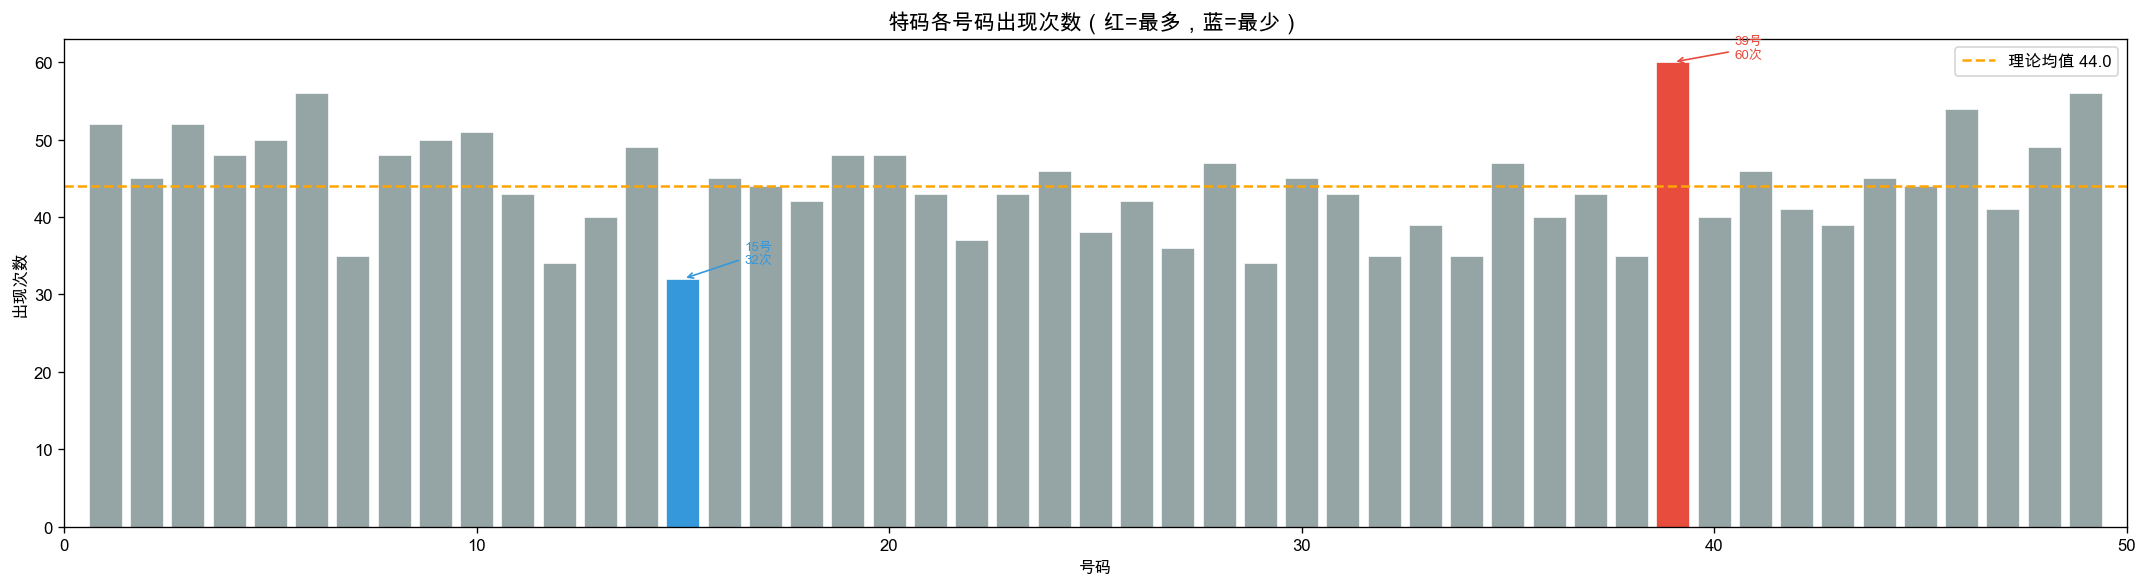

In [9]:
# 图1：号码出现次数柱状图
counts_list = freq_df['出现次数'].tolist()
max_val, min_val = max(counts_list), min(counts_list)
colors = ['#e74c3c' if c == max_val else '#3498db' if c == min_val else '#95a5a6' for c in counts_list]
fig, ax = plt.subplots(figsize=(18, 5))
ax.bar(freq_df['号码'], freq_df['出现次数'], color=colors, edgecolor='white', linewidth=0.4)
ax.axhline(y=theory, color='orange', linestyle='--', linewidth=1.5, label=f'理论均值 {theory:.1f}')
hot_num  = freq_df.loc[freq_df['出现次数'].idxmax(), '号码']
cold_num = freq_df.loc[freq_df['出现次数'].idxmin(), '号码']
ax.annotate(f'{hot_num}号\n{max_val}次', xy=(hot_num, max_val), xytext=(hot_num+1.5, max_val+0.5),
            fontsize=8, color='#e74c3c', arrowprops=dict(arrowstyle='->', color='#e74c3c', lw=1))
ax.annotate(f'{cold_num}号\n{min_val}次', xy=(cold_num, min_val), xytext=(cold_num+1.5, min_val+2),
            fontsize=8, color='#3498db', arrowprops=dict(arrowstyle='->', color='#3498db', lw=1))
ax.set_title('特码各号码出现次数（红=最多，蓝=最少）', fontsize=13, fontweight='bold')
ax.set_xlabel('号码'); ax.set_ylabel('出现次数'); ax.set_xlim(0, 50); ax.legend()
plt.tight_layout(); plt.show()

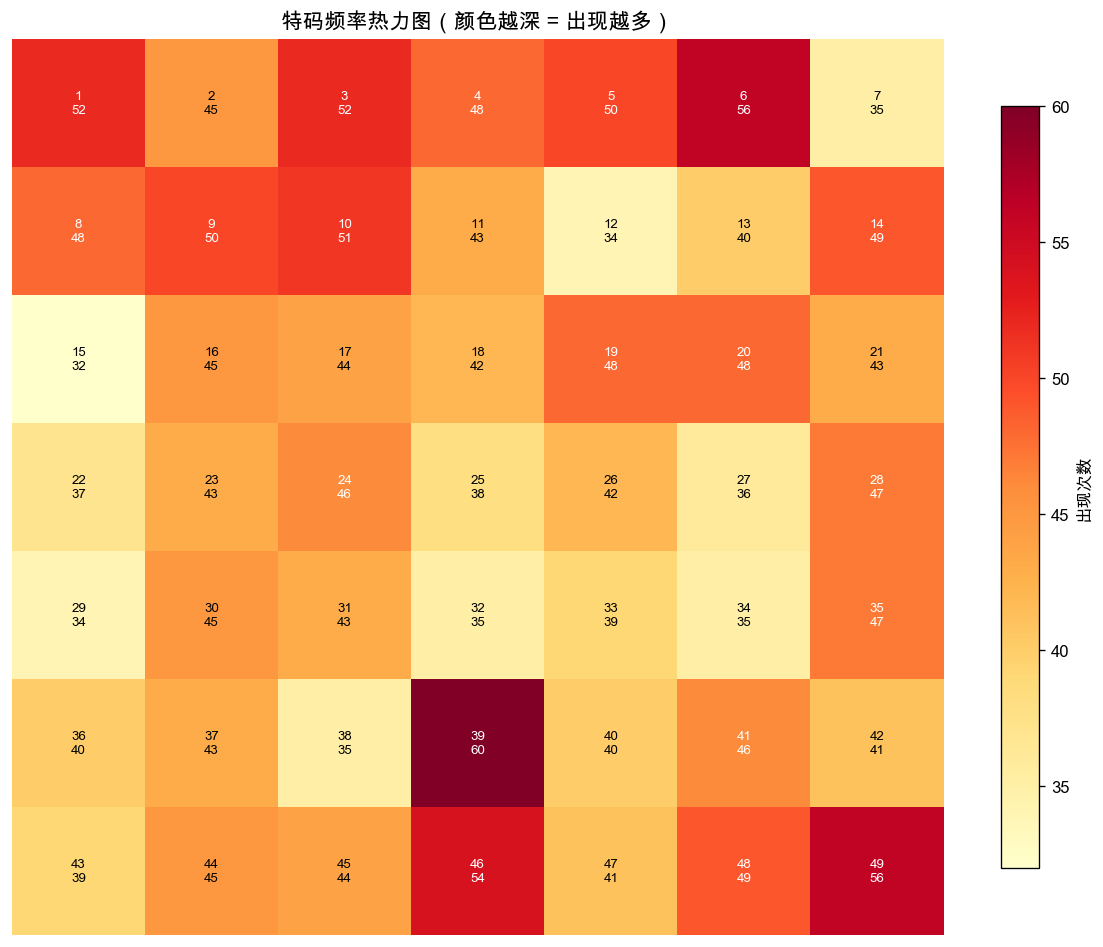

In [10]:
# 图2：热力图 7x7
fig, ax = plt.subplots(figsize=(10, 8))
grid = np.zeros((7, 7))
for i in range(7):
    for j in range(7):
        n = i * 7 + j + 1
        if n <= 49: grid[i][j] = freq_df.loc[freq_df['号码'] == n, '出现次数'].values[0]
im = ax.imshow(grid, cmap='YlOrRd', aspect='auto', vmin=min_val, vmax=max_val)
for i in range(7):
    for j in range(7):
        n = i * 7 + j + 1
        if n <= 49:
            val = int(grid[i][j])
            ax.text(j, i, f'{n}\n{val}', ha='center', va='center', fontsize=8,
                    color='white' if val > max_val * 0.75 else 'black')
plt.colorbar(im, ax=ax, shrink=0.85, label='出现次数')
ax.set_title('特码频率热力图（颜色越深 = 出现越多）', fontsize=13, fontweight='bold')
ax.axis('off'); plt.tight_layout(); plt.show()

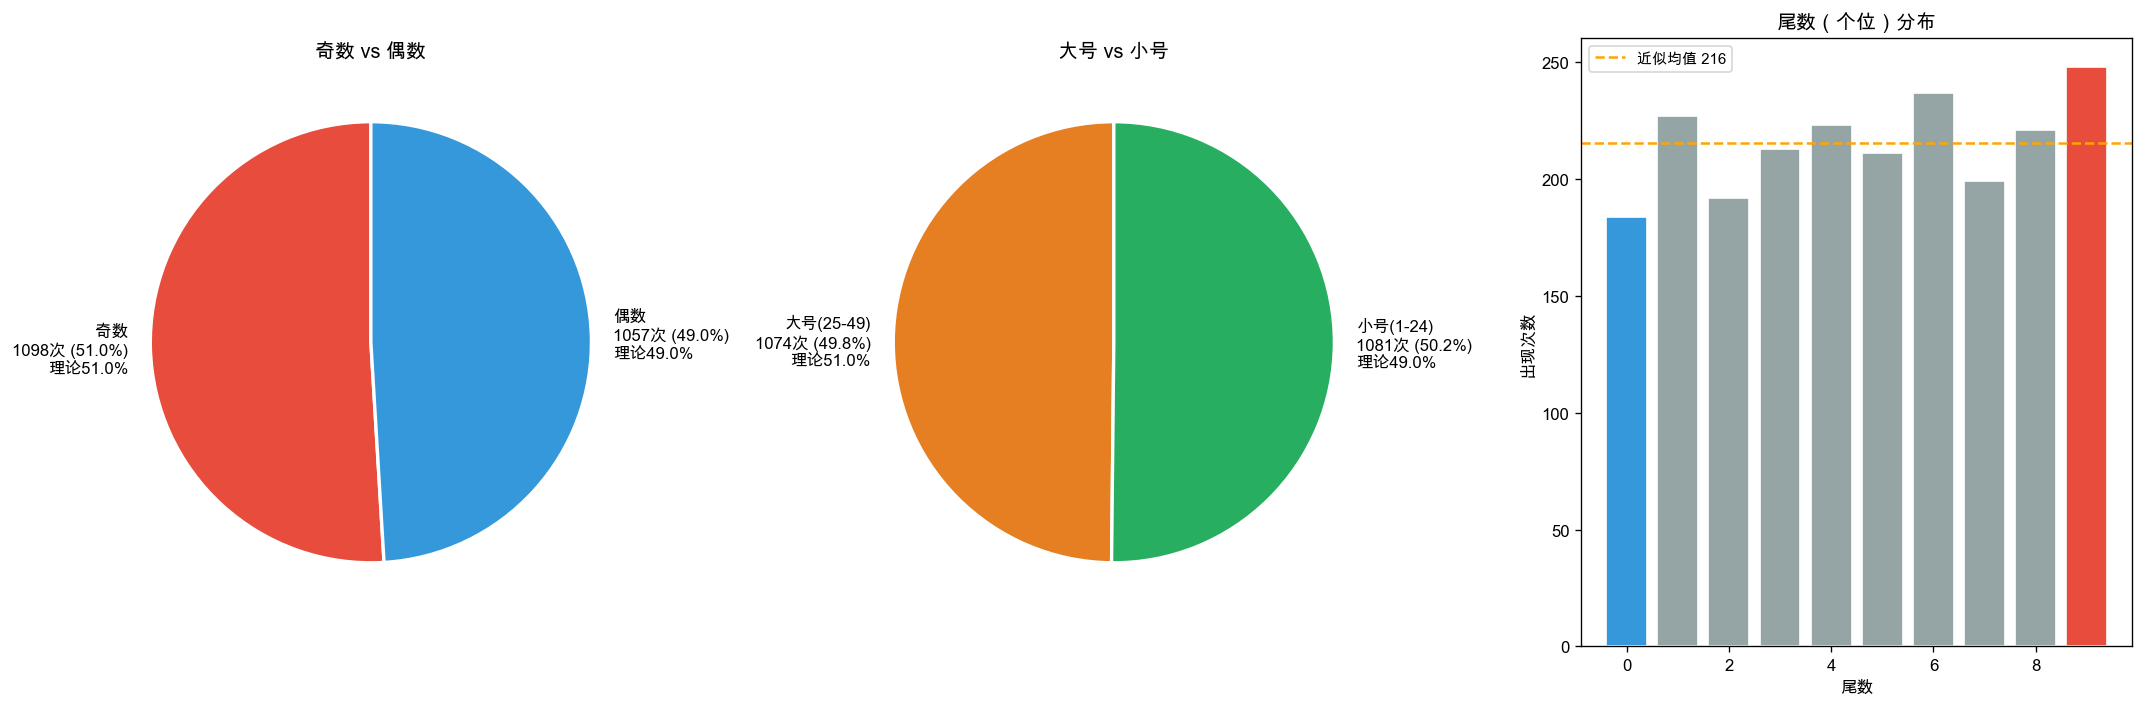

In [11]:
# 图3：奇偶 / 大小 / 尾数
specials = df['special'].tolist()
odd   = [x for x in specials if x % 2 == 1]
even  = [x for x in specials if x % 2 == 0]
big   = [x for x in specials if x > config.BIG_NUMBER_THRESHOLD]
small = [x for x in specials if x <= config.BIG_NUMBER_THRESHOLD]
tails = Counter(x % 10 for x in specials)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 奇偶
axes[0].pie([len(odd), len(even)],
            labels=[f'奇数\n{len(odd)}次 ({len(odd)/total*100:.1f}%)\n理论51.0%',
                    f'偶数\n{len(even)}次 ({len(even)/total*100:.1f}%)\n理论49.0%'],
            colors=['#e74c3c','#3498db'], startangle=90,
            wedgeprops={'edgecolor':'white','linewidth':2})
axes[0].set_title('奇数 vs 偶数', fontsize=12, fontweight='bold')

# 大小
axes[1].pie([len(big), len(small)],
            labels=[f'大号({config.BIG_NUMBER_THRESHOLD+1}-49)\n{len(big)}次 ({len(big)/total*100:.1f}%)\n理论51.0%',
                    f'小号(1-{config.BIG_NUMBER_THRESHOLD})\n{len(small)}次 ({len(small)/total*100:.1f}%)\n理论49.0%'],
            colors=['#e67e22','#27ae60'], startangle=90,
            wedgeprops={'edgecolor':'white','linewidth':2})
axes[1].set_title('大号 vs 小号', fontsize=12, fontweight='bold')

# 尾数
tail_x = list(range(10))
tail_y = [tails.get(i, 0) for i in tail_x]
bar_colors = ['#e74c3c' if v == max(tail_y) else '#3498db' if v == min(tail_y)
              else '#95a5a6' for v in tail_y]
axes[2].bar(tail_x, tail_y, color=bar_colors, edgecolor='white')
axes[2].axhline(y=total/10, color='orange', linestyle='--', linewidth=1.5,
                label=f'近似均值 {total/10:.0f}')
axes[2].set_title('尾数（个位）分布', fontsize=12, fontweight='bold')
axes[2].set_xlabel('尾数'); axes[2].set_ylabel('出现次数'); axes[2].legend(fontsize=9)

plt.tight_layout(); plt.show()


## 四、生肖分析

| # | 分析项 | 方法 |
|---|--------|------|
| 4.1 | 生肖频率分布 + 大数定律验证 | 卡方检验 |
| 4.2 | 时间维度趋势（月度波动） | 折线图 / 标准差 |
| 4.3 | 连续两期生肖关联 | 转移矩阵 / 独立性检验 |
| 4.4 | 生肖 × 号码区间交叉 | 箱线图 / 热力图 |
| 4.5 | 生肖间隔分析 | 泊松过程 / KS检验 |
| 4.6 | 奇偶 + 生肖组合 | 二项检验 |
| 4.7 | 大小号 + 生肖交叉 | 卡方 / 热力图 |
| 4.8 | 热门/冷门生肖（近N期）| 滑动窗口 |

,生肖,出现次数,频率%,理论频率%,偏差%
0,鼠,193,8.96,8.33,0.63
1,牛,187,8.68,8.33,0.35
2,虎,179,8.31,8.33,-0.02
3,兔,191,8.86,8.33,0.53
4,龙,184,8.54,8.33,0.21
5,蛇,169,7.84,8.33,-0.49
6,马,163,7.56,8.33,-0.77
7,羊,192,8.91,8.33,0.58
8,猴,180,8.35,8.33,0.02
9,鸡,173,8.03,8.33,-0.30



【生肖卡方检验】chi2=6.442，p=0.8423
结论：分布均匀，无显著偏差


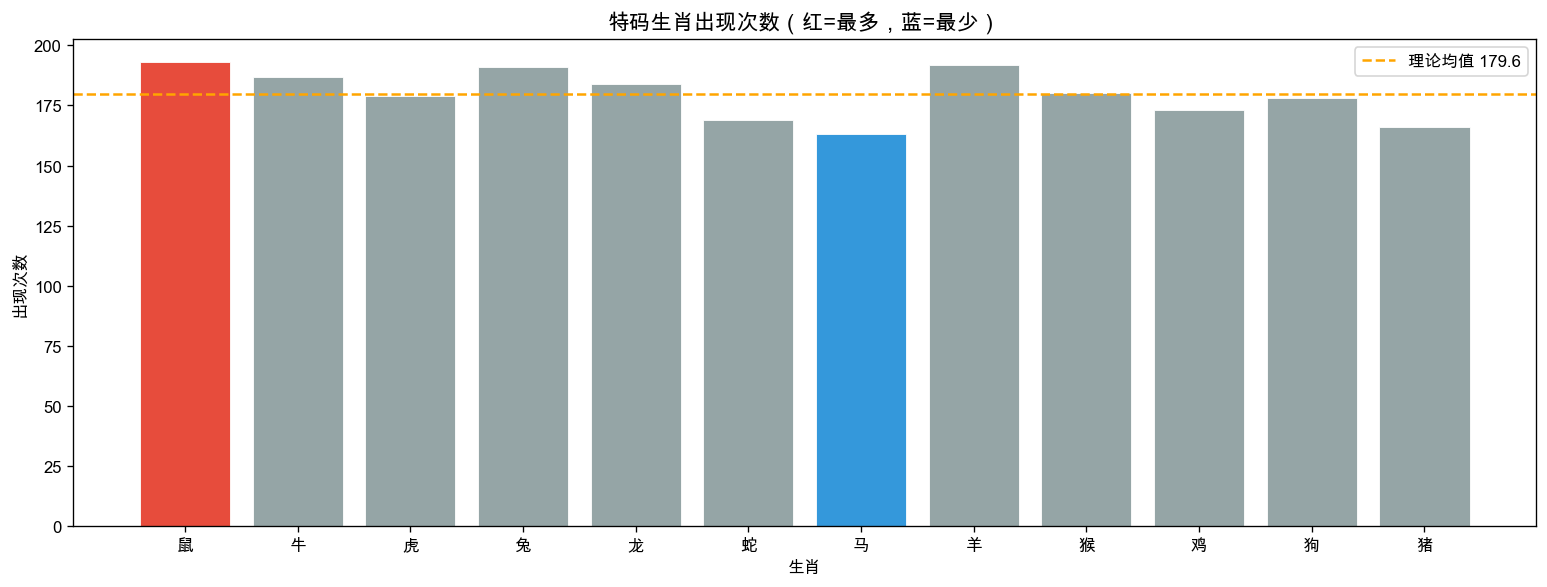

In [13]:
# ZODIAC_ORDER 已在 Cell 01 定义

def compute_zodiac(df):
    if 'zodiac' not in df.columns:
        raise ValueError('CSV 中无 zodiac 列，请重新运行 main.py 生成数据')
    counts = Counter(df['zodiac'])
    n = len(df)
    zdf = pd.DataFrame({'生肖': ZODIAC_ORDER, '出现次数': [counts.get(z, 0) for z in ZODIAC_ORDER]})
    zdf['频率%']    = (zdf['出现次数'] / n * 100).round(2)
    zdf['理论频率%'] = round(100 / 12, 2)
    zdf['偏差%']    = (zdf['频率%'] - zdf['理论频率%']).round(2)
    return zdf

zodiac_df = compute_zodiac(df)
display(zodiac_df)

z_chi2, z_p = chisquare(zodiac_df['出现次数'], f_exp=[len(df)/12]*12)
print(f'\n【生肖卡方检验】chi2={z_chi2:.3f}，p={z_p:.4f}')
print('结论：' + ('分布均匀，无显著偏差' if z_p > 0.05 else '存在显著偏差'))

fig, ax = plt.subplots(figsize=(13, 5))
z_counts = zodiac_df['出现次数'].tolist()
z_colors = ['#e74c3c' if c == max(z_counts) else '#3498db' if c == min(z_counts) else '#95a5a6' for c in z_counts]
ax.bar(zodiac_df['生肖'], z_counts, color=z_colors, edgecolor='white', linewidth=0.5)
ax.axhline(y=len(df)/12, color='orange', linestyle='--', linewidth=1.5, label=f'理论均值 {len(df)/12:.1f}')
ax.set_title('特码生肖出现次数（红=最多，蓝=最少）', fontsize=13, fontweight='bold')
ax.set_xlabel('生肖'); ax.set_ylabel('出现次数'); ax.legend()
plt.tight_layout(); plt.show()

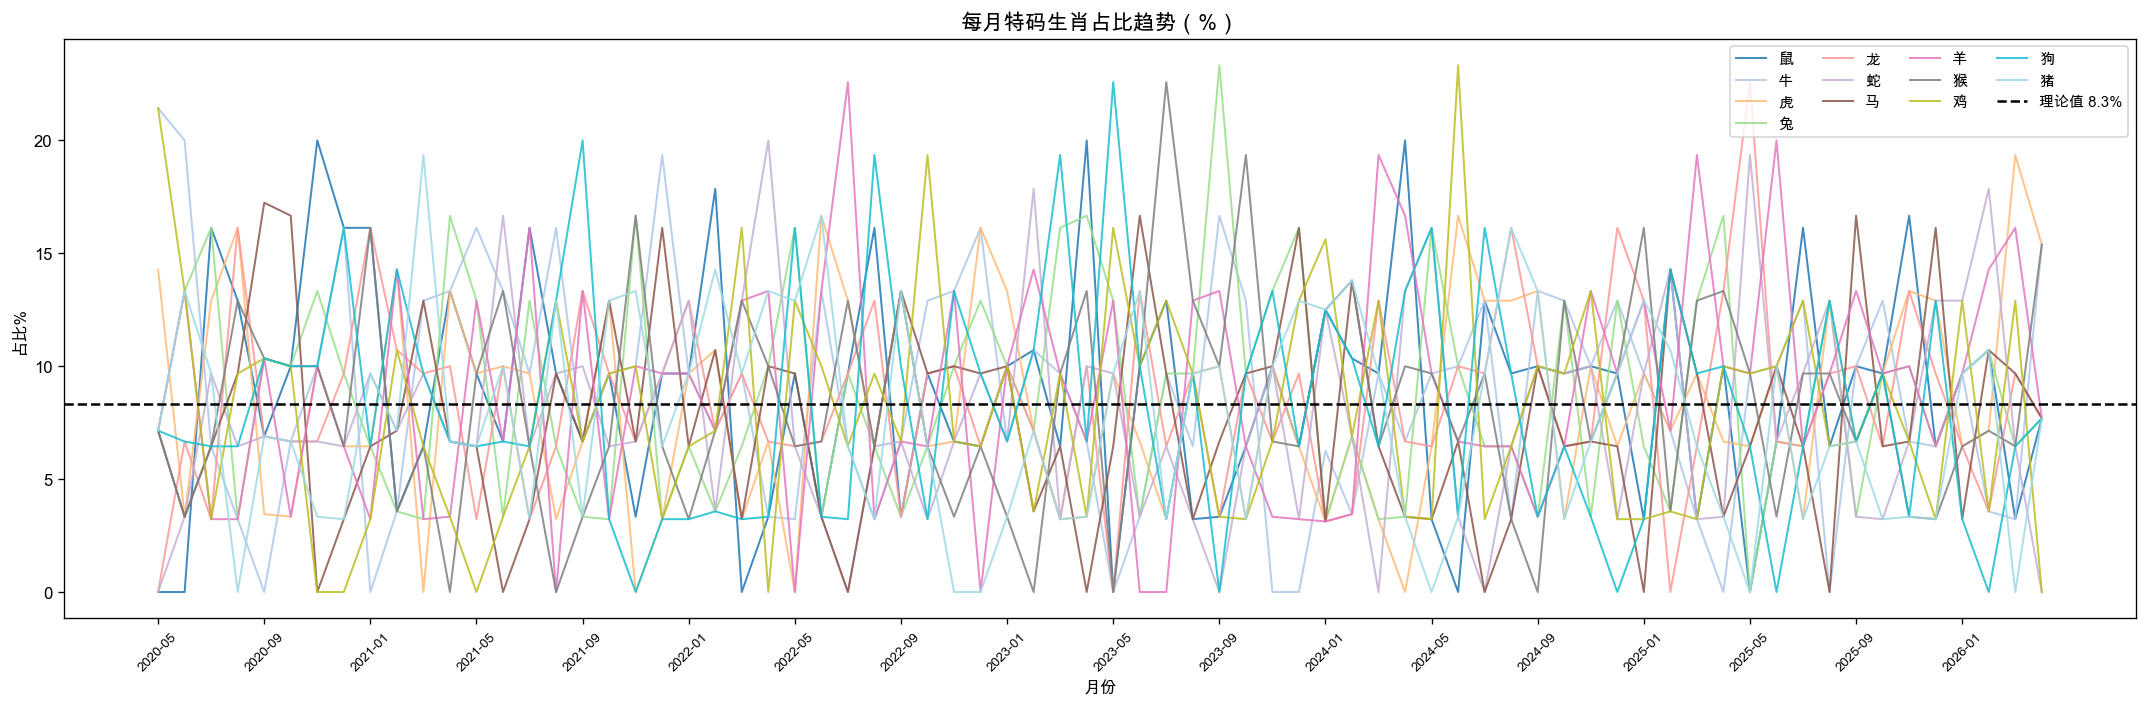

【各生肖月度占比标准差（越大代表该生肖月度波动越明显）】


,月度标准差%
zodiac,
羊,5.20
牛,5.19
狗,5.18
鼠,5.10
鸡,5.03
兔,4.81
蛇,4.75
猴,4.69
猪,4.62



理论标准差参考：若完全随机，月度标准差约 4.82%


In [14]:
# ---- 4.2 每月生肖占比趋势 ----
_ym        = df['openTime'].dt.to_period('M')          # 局部变量，不污染 df
monthly_z  = df.assign(ym=_ym).groupby(['ym','zodiac']).size().unstack(fill_value=0)
for z in ZODIAC_ORDER:
    if z not in monthly_z.columns:
        monthly_z[z] = 0
monthly_z   = monthly_z[ZODIAC_ORDER]
monthly_pct = monthly_z.div(monthly_z.sum(axis=1), axis=0).mul(100)

# 折线图
fig, ax = plt.subplots(figsize=(18, 6))
cmap_z  = plt.cm.tab20(np.linspace(0, 1, 12))
x       = list(range(len(monthly_pct)))
for i, z in enumerate(ZODIAC_ORDER):
    ax.plot(x, monthly_pct[z], label=z, color=cmap_z[i], linewidth=1.2, alpha=0.85)
ax.axhline(y=100/12, color='black', linestyle='--', linewidth=1.5, label=f'理论值 {100/12:.1f}%')
tick_step = max(1, len(x) // 15)
ax.set_xticks(x[::tick_step])
ax.set_xticklabels([str(monthly_pct.index[i]) for i in x[::tick_step]], rotation=45, fontsize=8)
ax.set_title('每月特码生肖占比趋势（%）', fontsize=13, fontweight='bold')
ax.set_xlabel('月份'); ax.set_ylabel('占比%')
ax.legend(loc='upper right', ncol=4, fontsize=9)
plt.tight_layout(); plt.show()

# 各生肖月度波动标准差
std_z = monthly_pct.std().sort_values(ascending=False).rename('月度标准差%').round(2)
print('【各生肖月度占比标准差（越大代表该生肖月度波动越明显）】')
display(std_z.to_frame())
print(f'\n理论标准差参考：若完全随机，月度标准差约 {monthly_pct.stack().std():.2f}%')


【连续两期生肖独立性检验（卡方检验）】
chi2=79.181，p=0.9988，自由度=121
结论：两期生肖相互独立，不存在显著关联 —— 符合随机特征


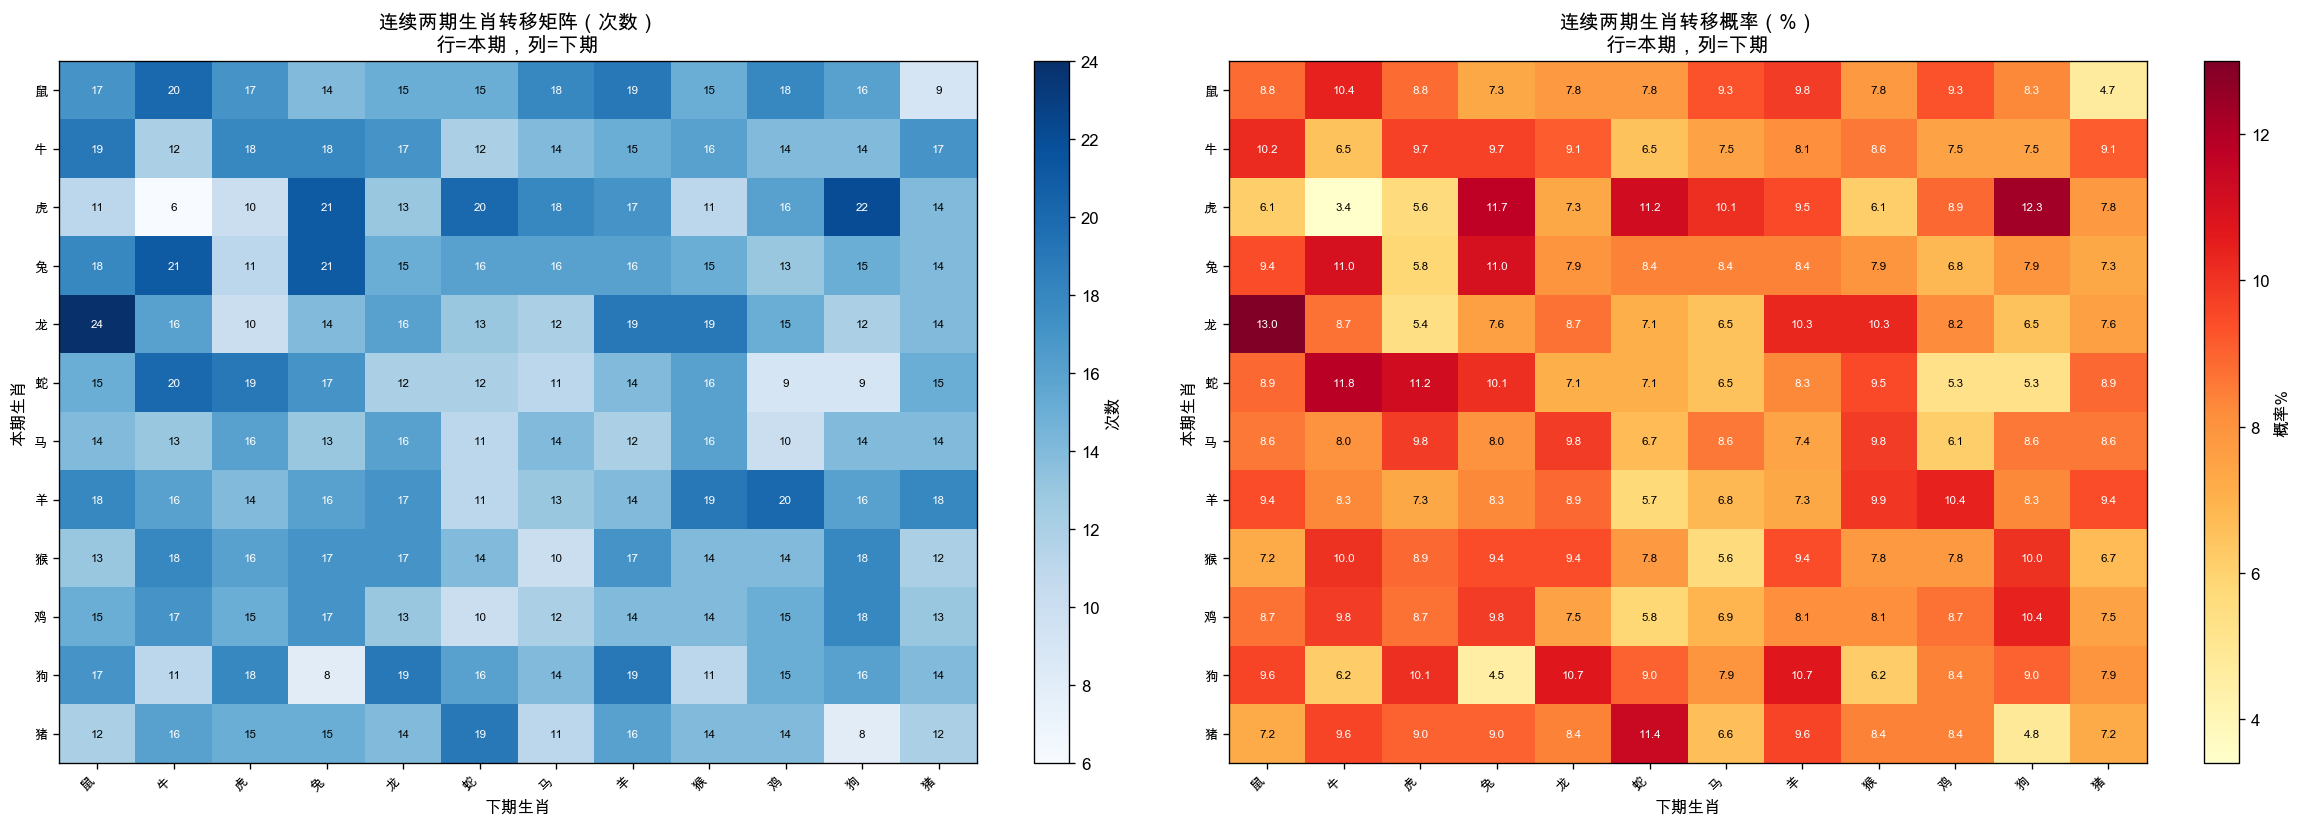


理论每格期望次数：15.0
【偏差最大的前10种组合（大概率是随机波动）】
   1. 龙 -> 鼠：24次，偏高 9.0次
   2. 虎 -> 牛：6次，偏低 9.0次
   3. 虎 -> 狗：22次，偏高 7.0次
   4. 狗 -> 兔：8次，偏低 7.0次
   5. 猪 -> 狗：8次，偏低 7.0次
   6. 虎 -> 兔：21次，偏高 6.0次
   7. 兔 -> 牛：21次，偏高 6.0次
   8. 兔 -> 兔：21次，偏高 6.0次
   9. 鼠 -> 猪：9次，偏低 6.0次
  10. 蛇 -> 鸡：9次，偏低 6.0次


In [15]:
# ---- 4.3 连续两期生肖组合分析 ----
from scipy.stats import chi2_contingency

from_z = df['zodiac'].iloc[:-1].values
to_z   = df['zodiac'].iloc[1:].values
trans  = pd.DataFrame(0, index=ZODIAC_ORDER, columns=ZODIAC_ORDER)
for f, t in zip(from_z, to_z):
    trans.loc[f, t] += 1

# 独立性卡方检验
chi2_t, p_t, dof_t, expected_t = chi2_contingency(trans.values)
print('【连续两期生肖独立性检验（卡方检验）】')
print(f'chi2={chi2_t:.3f}，p={p_t:.4f}，自由度={dof_t}')
if p_t > 0.05:
    print('结论：两期生肖相互独立，不存在显著关联 —— 符合随机特征')
else:
    print(f'结论：存在统计显著关联（p={p_t:.4f}），但需结合实际偏差量判断')

# 热力图（matplotlib imshow）
trans_pct = trans.div(trans.sum(axis=1), axis=0).mul(100).round(1)
fig, axes = plt.subplots(1, 2, figsize=(20, 7))

def _draw_heatmap(ax, data, fmt, cmap, title, xlabel, ylabel, cbar_label):
    vals = data.values
    im   = ax.imshow(vals, cmap=cmap, aspect='auto')
    ax.set_xticks(range(len(data.columns))); ax.set_xticklabels(data.columns, rotation=45, ha='right', fontsize=8)
    ax.set_yticks(range(len(data.index)));   ax.set_yticklabels(data.index, fontsize=8)
    thresh = (vals.max() + vals.min()) / 2
    for i in range(vals.shape[0]):
        for j in range(vals.shape[1]):
            ax.text(j, i, format(vals[i,j], fmt), ha='center', va='center', fontsize=7,
                    color='white' if vals[i,j] > thresh else 'black')
    plt.colorbar(im, ax=ax, label=cbar_label)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)

_draw_heatmap(axes[0], trans, 'd', 'Blues',
              '连续两期生肖转移矩阵（次数）\n行=本期，列=下期', '下期生肖', '本期生肖', '次数')
_draw_heatmap(axes[1], trans_pct, '.1f', 'YlOrRd',
              '连续两期生肖转移概率（%）\n行=本期，列=下期', '下期生肖', '本期生肖', '概率%')

plt.tight_layout(); plt.show()

# 偏差最大的组合
theory_cell = len(df) / 144
combos_bias = [(f, t, int(trans.loc[f,t]), trans.loc[f,t] - theory_cell)
               for f in ZODIAC_ORDER for t in ZODIAC_ORDER]
combos_bias.sort(key=lambda x: -abs(x[3]))
print(f'\n理论每格期望次数：{theory_cell:.1f}')
print('【偏差最大的前10种组合（大概率是随机波动）】')
for i, (f, t, c, bias) in enumerate(combos_bias[:10], 1):
    print(f'  {i:2d}. {f} -> {t}：{c}次，{"偏高" if bias>0 else "偏低"} {abs(bias):.1f}次')


【生肖 × 号码区间 独立性检验（卡方检验）】
chi2=34.938，p=0.3761，自由度=33
结论：生肖与号码区间无显著关联 —— 不存在结构性偏差


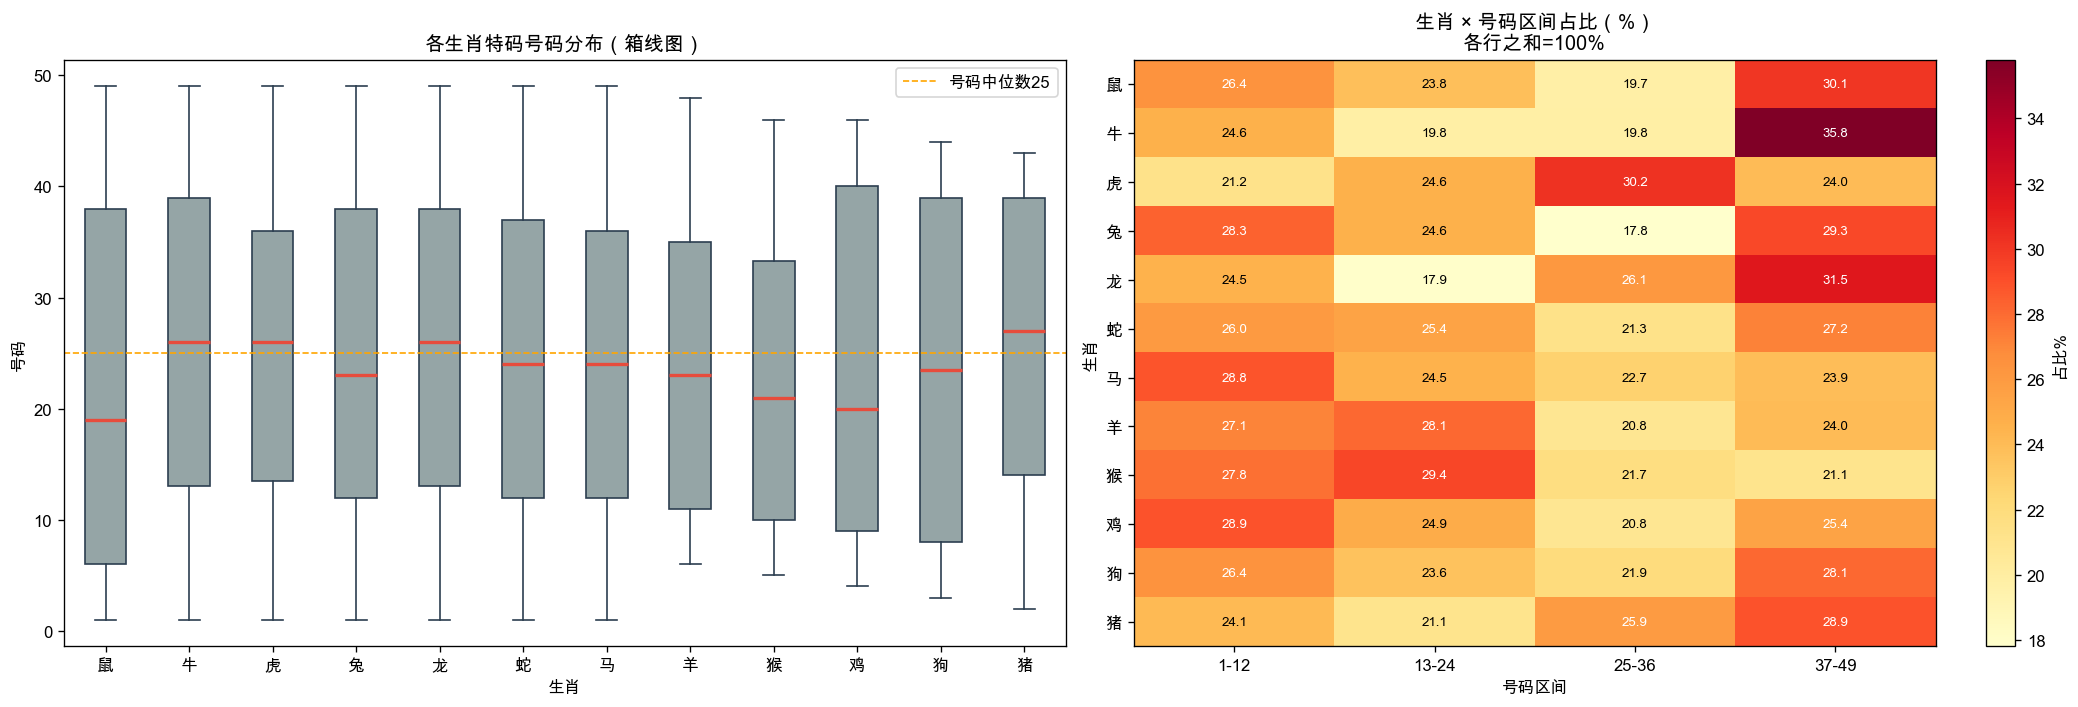


【各生肖号码数值统计】


,均值,中位数,标准差,出现次数
zodiac,,,,
鼠,22.40,19.0,14.72,193
牛,24.76,26.0,15.63,187
虎,24.82,26.0,14.63,179
兔,24.18,23.0,15.94,191
龙,27.29,26.0,15.10,184
蛇,26.31,24.0,14.81,169
马,26.34,24.0,13.85,163
羊,25.98,23.0,13.78,192
猴,24.11,21.0,13.28,180


In [16]:
# ---- 4.4 生肖 × 号码区间交叉分析 ----
from scipy.stats import chi2_contingency

bins_r    = [0, 12, 24, 36, 49]
labels_r  = ['1-12', '13-24', '25-36', '37-49']
_nr       = pd.cut(df['special'], bins=bins_r, labels=labels_r, right=True)  # 局部变量
cross     = (df.assign(num_range=_nr)
               .groupby(['zodiac','num_range'], observed=True)
               .size().unstack(fill_value=0)
               .reindex(ZODIAC_ORDER))
cross_pct = cross.div(cross.sum(axis=1), axis=0).mul(100).round(1)

# 独立性卡方检验
chi2_c, p_c, dof_c, _ = chi2_contingency(cross.values)
print('【生肖 × 号码区间 独立性检验（卡方检验）】')
print(f'chi2={chi2_c:.3f}，p={p_c:.4f}，自由度={dof_c}')
if p_c > 0.05:
    print('结论：生肖与号码区间无显著关联 —— 不存在结构性偏差')
else:
    print(f'结论：存在显著结构偏差（p={p_c:.4f}），生肖集中在特定区间')

# 箱线图 + 热力图（matplotlib imshow，不依赖 seaborn）
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

data_box = [df[df['zodiac'] == z]['special'].tolist() for z in ZODIAC_ORDER]
axes[0].boxplot(data_box, labels=ZODIAC_ORDER, patch_artist=True,
                boxprops=dict(facecolor='#95a5a6', color='#2c3e50'),
                medianprops=dict(color='#e74c3c', linewidth=2),
                whiskerprops=dict(color='#2c3e50'),
                capprops=dict(color='#2c3e50'))
axes[0].axhline(y=25, color='orange', linestyle='--', linewidth=1, label='号码中位数25')
axes[0].set_title('各生肖特码号码分布（箱线图）', fontsize=12, fontweight='bold')
axes[0].set_xlabel('生肖'); axes[0].set_ylabel('号码'); axes[0].legend()

vals = cross_pct.values
im   = axes[1].imshow(vals, cmap='YlOrRd', aspect='auto')
axes[1].set_xticks(range(len(labels_r))); axes[1].set_xticklabels(labels_r)
axes[1].set_yticks(range(len(ZODIAC_ORDER))); axes[1].set_yticklabels(ZODIAC_ORDER)
for i in range(len(ZODIAC_ORDER)):
    for j in range(len(labels_r)):
        axes[1].text(j, i, f'{vals[i,j]:.1f}', ha='center', va='center', fontsize=8,
                     color='white' if vals[i,j] > vals.max()*0.7 else 'black')
plt.colorbar(im, ax=axes[1], label='占比%')
axes[1].set_title('生肖 × 号码区间占比（%）\n各行之和=100%', fontsize=12, fontweight='bold')
axes[1].set_xlabel('号码区间'); axes[1].set_ylabel('生肖')
plt.tight_layout(); plt.show()

# 各生肖号码均值统计
num_stats = df.groupby('zodiac')['special'].agg(['mean','median','std','count']).round(2)
num_stats.columns = ['均值','中位数','标准差','出现次数']
num_stats = num_stats.reindex(ZODIAC_ORDER)
print('\n【各生肖号码数值统计】')
display(num_stats)


,生肖,出现次数,平均间隔,最短间隔,最长间隔,当前遗漏
0,鼠,193,10.9,1,58,7
1,牛,187,11.6,1,78,0
2,虎,179,12.0,1,71,5
3,兔,191,11.2,1,59,10
4,龙,184,11.6,1,54,2
5,蛇,169,12.5,1,61,16
6,马,163,13.2,1,73,12
7,羊,192,11.2,1,74,4
8,猴,180,12.0,1,77,6
9,鸡,173,12.4,1,94,25


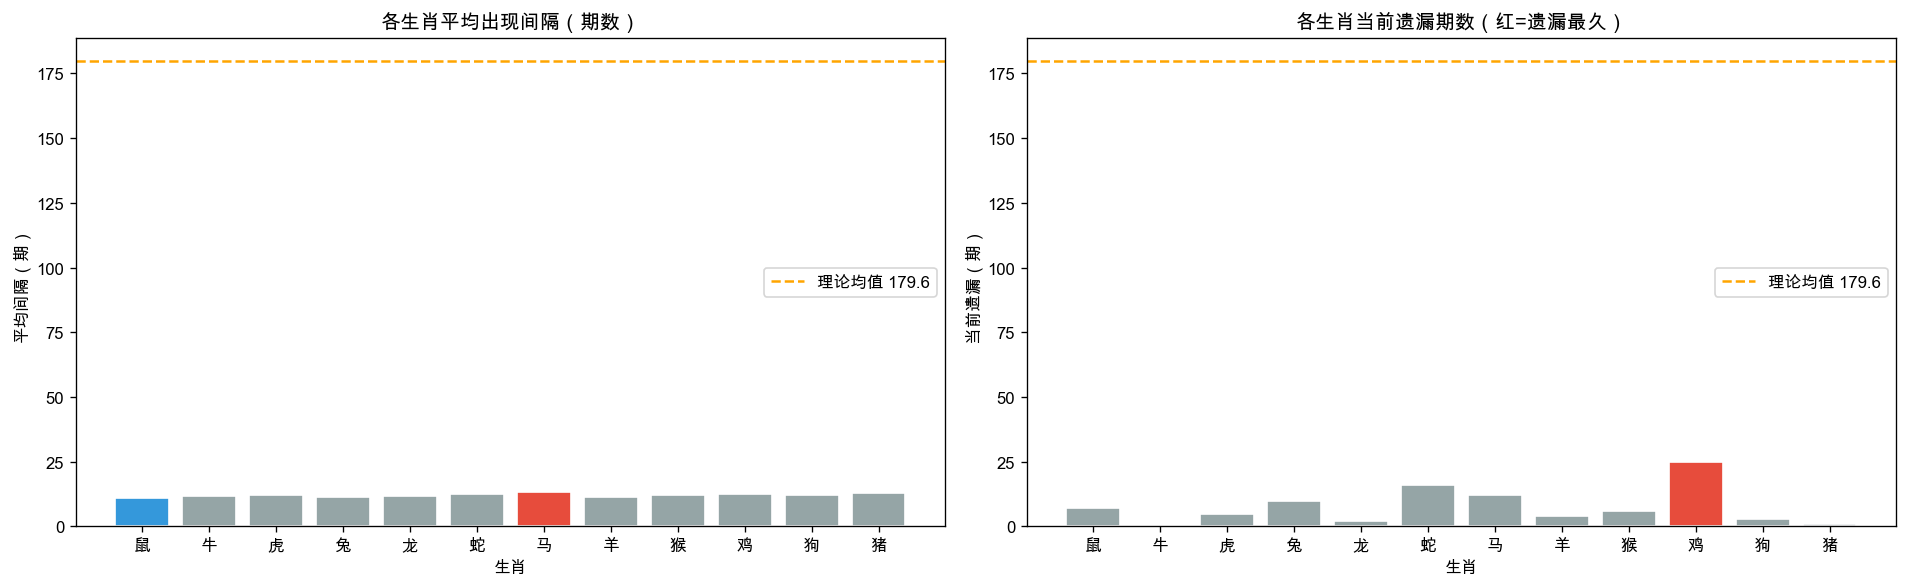

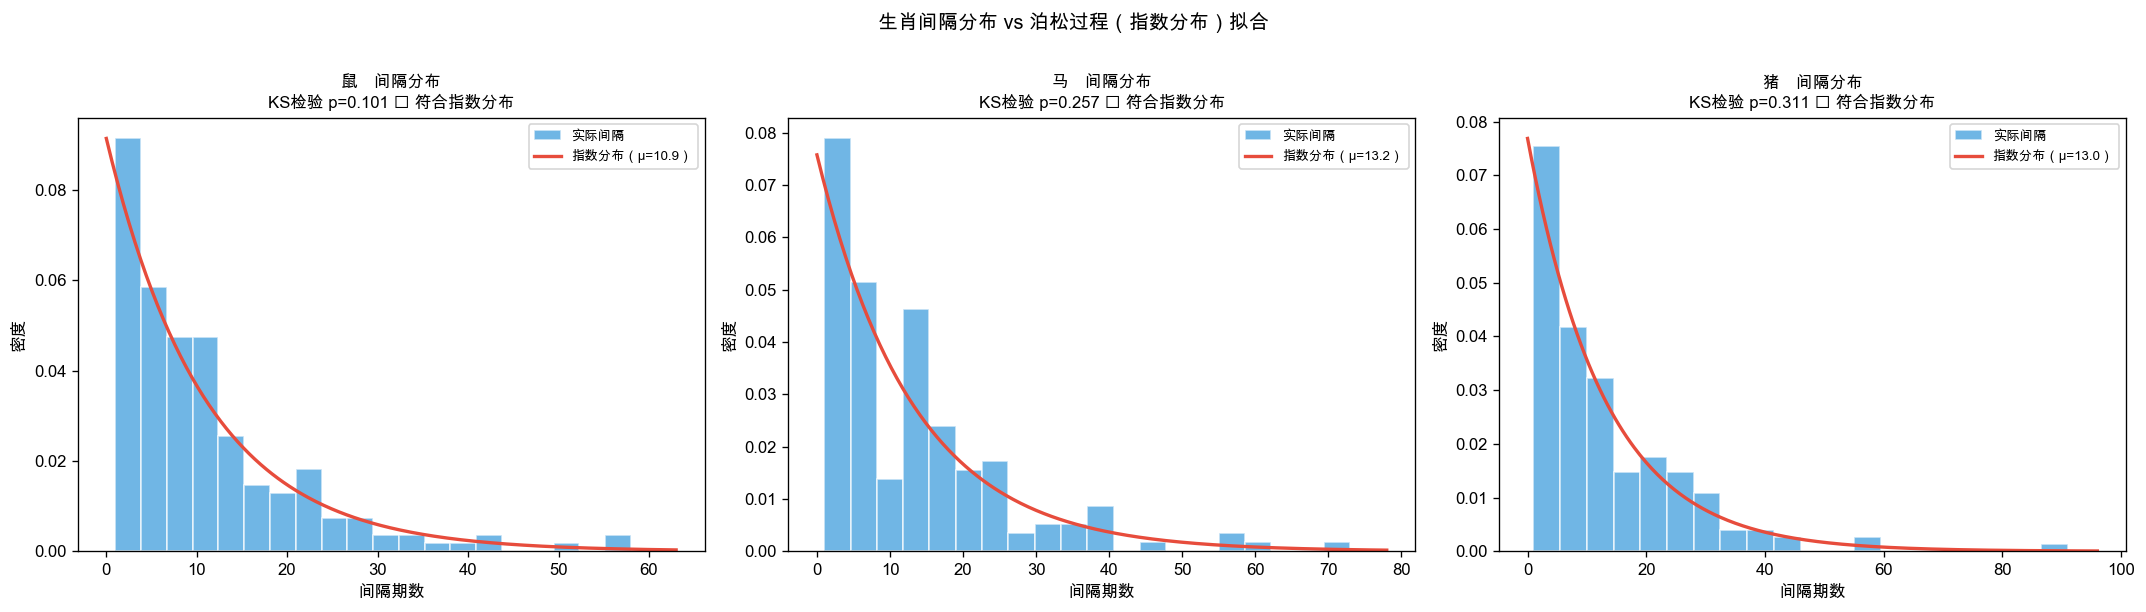


【泊松过程验证：各生肖间隔 KS 检验（指数分布）】
  生肖     样本数      均值间隔     KS统计量        p值          结论
   鼠     192      10.9    0.0873    0.1007  符合
   牛     186      11.6    0.0941    0.0695  符合
   虎     178      12.0    0.0969    0.0662  符合
   兔     190      11.2    0.0852    0.1194  符合
   龙     183      11.6    0.0928    0.0803  符合
   蛇     168      12.5    0.0771    0.2578  符合
   马     162      13.2    0.0785    0.2574  符合
   羊     191      11.2    0.0903    0.0833  符合
   猴     179      12.0    0.0801    0.1904  符合
   鸡     172      12.4    0.0776    0.2383  符合
   狗     177      12.1    0.0843    0.1523  符合
   猪     165      13.0    0.0740    0.3113  符合


In [17]:
# ---- 4.5 生肖间隔分析（泊松过程验证）----
from scipy.stats import expon, kstest

def zodiac_interval_analysis(df):
    df = df.reset_index(drop=True)  # 确保索引连续，避免过滤后遗漏计算出负数
    results = []
    for z in ZODIAC_ORDER:
        idx_list = df.index[df['zodiac'] == z].tolist()
        gaps = [idx_list[i+1] - idx_list[i] for i in range(len(idx_list)-1)]
        results.append({
            '生肖':     z,
            '出现次数': len(idx_list),
            '平均间隔': round(np.mean(gaps), 1) if gaps else None,
            '最短间隔': min(gaps) if gaps else None,
            '最长间隔': max(gaps) if gaps else None,
            '当前遗漏': len(df) - 1 - idx_list[-1] if idx_list else len(df),
            'intervals': gaps,
        })
    return results

zint = zodiac_interval_analysis(df)
theory_z = len(df) / 12

# ── 表格 ──
zint_df = pd.DataFrame([{k: v for k, v in r.items() if k != 'intervals'} for r in zint])
display(zint_df)

# ── 图1：平均间隔 + 当前遗漏 ──
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
avg_g = zint_df['平均间隔'].fillna(0)
colors_a = ['#e74c3c' if v == avg_g.max() else '#3498db' if v == avg_g[avg_g>0].min() else '#95a5a6' for v in avg_g]
axes[0].bar(zint_df['生肖'], avg_g, color=colors_a, edgecolor='white')
axes[0].axhline(y=theory_z, color='orange', linestyle='--', linewidth=1.5, label=f'理论均值 {theory_z:.1f}')
axes[0].set_title('各生肖平均出现间隔（期数）', fontsize=12, fontweight='bold')
axes[0].set_xlabel('生肖'); axes[0].set_ylabel('平均间隔（期）'); axes[0].legend()

miss_g = zint_df['当前遗漏']
colors_m = ['#e74c3c' if v == miss_g.max() else '#95a5a6' for v in miss_g]
axes[1].bar(zint_df['生肖'], miss_g, color=colors_m, edgecolor='white')
axes[1].axhline(y=theory_z, color='orange', linestyle='--', linewidth=1.5, label=f'理论均值 {theory_z:.1f}')
axes[1].set_title('各生肖当前遗漏期数（红=遗漏最久）', fontsize=12, fontweight='bold')
axes[1].set_xlabel('生肖'); axes[1].set_ylabel('当前遗漏（期）'); axes[1].legend()
plt.tight_layout(); plt.show()

# ── 图2：间隔分布直方图（选3个生肖）+ 指数分布拟合（泊松过程） ──
sample_z = [ZODIAC_ORDER[0], ZODIAC_ORDER[len(ZODIAC_ORDER)//2], ZODIAC_ORDER[-1]]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, z in zip(axes, sample_z):
    row   = next(r for r in zint if r['生肖'] == z)
    gaps  = row['intervals']
    if not gaps: continue
    mu    = np.mean(gaps)
    x_max = max(gaps) + 5
    xs    = np.linspace(0, x_max, 300)
    # KS 检验是否服从指数分布
    stat, p_ks = kstest(gaps, 'expon', args=(0, mu))
    ax.hist(gaps, bins=20, color='#3498db', alpha=0.7, edgecolor='white',
            density=True, label='实际间隔')
    ax.plot(xs, expon.pdf(xs, scale=mu), color='#e74c3c', linewidth=2,
            label=f'指数分布（μ={mu:.1f}）')
    ax.set_title(f'{z}　间隔分布\nKS检验 p={p_ks:.3f} {"✅ 符合" if p_ks>0.05 else "⚠️ 偏离"}指数分布',
                 fontsize=10, fontweight='bold')
    ax.set_xlabel('间隔期数'); ax.set_ylabel('密度'); ax.legend(fontsize=8)
plt.suptitle('生肖间隔分布 vs 泊松过程（指数分布）拟合', fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

print('\n【泊松过程验证：各生肖间隔 KS 检验（指数分布）】')
print(f'{"生肖":>4}  {"样本数":>6}  {"均值间隔":>8}  {"KS统计量":>8}  {"p值":>8}  {"结论":>10}')
for r in zint:
    gaps = r['intervals']
    if len(gaps) < 5: continue
    mu = np.mean(gaps)
    st, pv = kstest(gaps, 'expon', args=(0, mu))
    print(f'{r["生肖"]:>4}  {len(gaps):>6}  {mu:>8.1f}  {st:>8.4f}  {pv:>8.4f}  {"符合" if pv>0.05 else "偏离"}')


【各生肖 奇偶/大小 分布（理论奇数51.0%，大号51.0%）】


,生肖,总次数,奇数次,奇数%,偶数次,奇偶p值,大号次,大号%,小号次,大小p值
0,鼠,193,92,47.7,101,0.3877,96,49.7,97,0.7734
1,牛,187,96,51.3,91,0.9418,104,55.6,83,0.2144
2,虎,179,95,53.1,84,0.6013,97,54.2,82,0.4115
3,兔,191,104,54.5,87,0.3479,90,47.1,101,0.3110
4,龙,184,94,51.1,90,1.0000,106,57.6,78,0.0770
5,蛇,169,100,59.2,69,0.0376,82,48.5,87,0.5387
6,马,163,75,46.0,88,0.2105,76,46.6,87,0.2733
7,羊,192,97,50.5,95,0.9425,86,44.8,106,0.0966
8,猴,180,88,48.9,92,0.6020,77,42.8,103,0.0304
9,鸡,173,88,50.9,85,1.0000,80,46.2,93,0.2239



⚠️ 以下生肖奇偶存在显著偏差：['蛇']
⚠️ 以下生肖大小存在显著偏差：['猴']


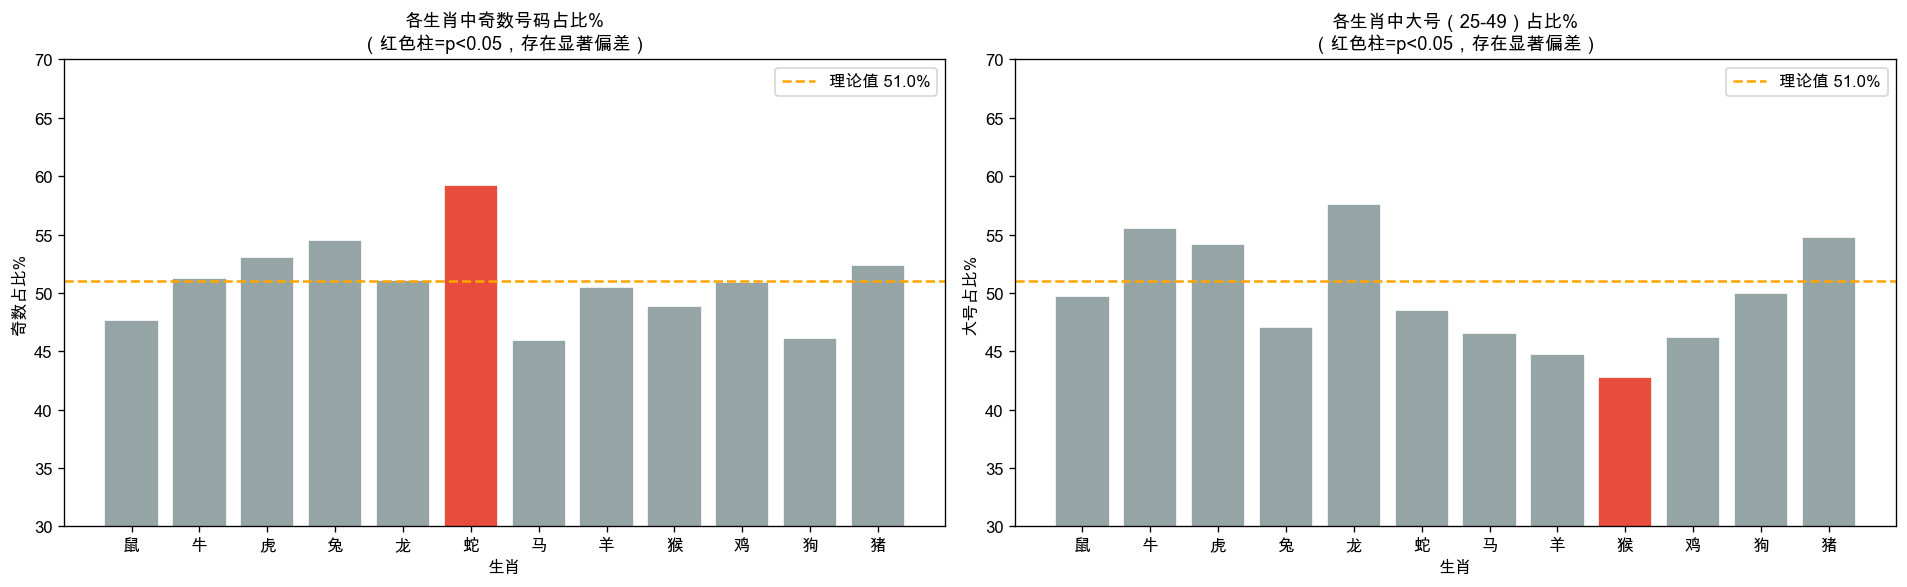

In [18]:
# ---- 4.6 奇偶 + 生肖组合分析 ----
from scipy.stats import binomtest as _binom

rows_oe = []
for z in ZODIAC_ORDER:
    sub    = df[df['zodiac'] == z]['special']
    n      = len(sub)
    odd_n  = (sub % 2 == 1).sum()
    big_n  = (sub > config.BIG_NUMBER_THRESHOLD).sum()
    p_oe   = _binom(int(odd_n), n, 25/49).pvalue
    p_bs   = _binom(int(big_n), n, 25/49).pvalue
    rows_oe.append({
        '生肖':     z,
        '总次数':   n,
        '奇数次':   int(odd_n),
        '奇数%':    round(odd_n / n * 100, 1) if n else 0,
        '偶数次':   n - int(odd_n),
        '奇偶p值':  round(p_oe, 4),
        '大号次':   int(big_n),
        '大号%':    round(big_n / n * 100, 1) if n else 0,
        '小号次':   n - int(big_n),
        '大小p值':  round(p_bs, 4),
    })

oe_df = pd.DataFrame(rows_oe)
print('【各生肖 奇偶/大小 分布（理论奇数51.0%，大号51.0%）】')
display(oe_df)

# 奇偶显著性标记
sig_oe = oe_df[oe_df['奇偶p值'] < 0.05]
sig_bs = oe_df[oe_df['大小p值'] < 0.05]
if sig_oe.empty:
    print('\n✅ 所有生肖奇偶占比均通过二项检验（p>0.05），无结构偏差')
else:
    print(f'\n⚠️ 以下生肖奇偶存在显著偏差：{sig_oe["生肖"].tolist()}')
if sig_bs.empty:
    print('✅ 所有生肖大小号占比均通过二项检验（p>0.05），无结构偏差')
else:
    print(f'⚠️ 以下生肖大小存在显著偏差：{sig_bs["生肖"].tolist()}')

# ── 图：奇数%和大号% 偏差条形图 ──
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
theory_line = 25 / 49 * 100
colors_oe = ['#e74c3c' if p < 0.05 else '#95a5a6' for p in oe_df['奇偶p值']]
colors_bs = ['#e74c3c' if p < 0.05 else '#95a5a6' for p in oe_df['大小p值']]

axes[0].bar(oe_df['生肖'], oe_df['奇数%'], color=colors_oe, edgecolor='white')
axes[0].axhline(y=theory_line, color='orange', linestyle='--', linewidth=1.5, label=f'理论值 {theory_line:.1f}%')
axes[0].set_ylim(30, 70)
axes[0].set_title('各生肖中奇数号码占比%\n（红色柱=p<0.05，存在显著偏差）', fontsize=11, fontweight='bold')
axes[0].set_xlabel('生肖'); axes[0].set_ylabel('奇数占比%'); axes[0].legend()

axes[1].bar(oe_df['生肖'], oe_df['大号%'], color=colors_bs, edgecolor='white')
axes[1].axhline(y=theory_line, color='orange', linestyle='--', linewidth=1.5, label=f'理论值 {theory_line:.1f}%')
axes[1].set_ylim(30, 70)
axes[1].set_title('各生肖中大号（25-49）占比%\n（红色柱=p<0.05，存在显著偏差）', fontsize=11, fontweight='bold')
axes[1].set_xlabel('生肖'); axes[1].set_ylabel('大号占比%'); axes[1].legend()
plt.tight_layout(); plt.show()


【多窗口生肖分布对比表】
理论均值：50期=4.2次 | 100期=8.3次 | 200期=16.7次



,50期次数,50期占比,50期偏差,100期次数,100期占比,100期偏差,200期次数,200期占比,200期偏差
生肖,,,,,,,,,
鼠,3,6.0%,-1.2,8,8.0%,-0.3,19,9.5%,+2.3
牛,3,6.0%,-1.2,6,6.0%,-2.3,15,7.5%,-1.7
虎,8,16.0%,+3.8,12,12.0%,+3.7,24,12.0%,+7.3
兔,3,6.0%,-1.2,9,9.0%,+0.7,17,8.5%,+0.3
龙,4,8.0%,-0.2,7,7.0%,-1.3,16,8.0%,-0.7
蛇,3,6.0%,-1.2,11,11.0%,+2.7,18,9.0%,+1.3
马,4,8.0%,-0.2,8,8.0%,-0.3,18,9.0%,+1.3
羊,8,16.0%,+3.8,13,13.0%,+4.7,22,11.0%,+5.3
猴,5,10.0%,+0.8,7,7.0%,-1.3,13,6.5%,-3.7



【各窗口卡方检验（是否偏离均匀分布）】
      窗口      chi2        p值                    结论     样本量
近  50期    11.440    0.4072                ✅ 分布均匀      50
近 100期     8.720    0.6477                ✅ 分布均匀     100
近 200期     9.880    0.5412                ✅ 分布均匀     200


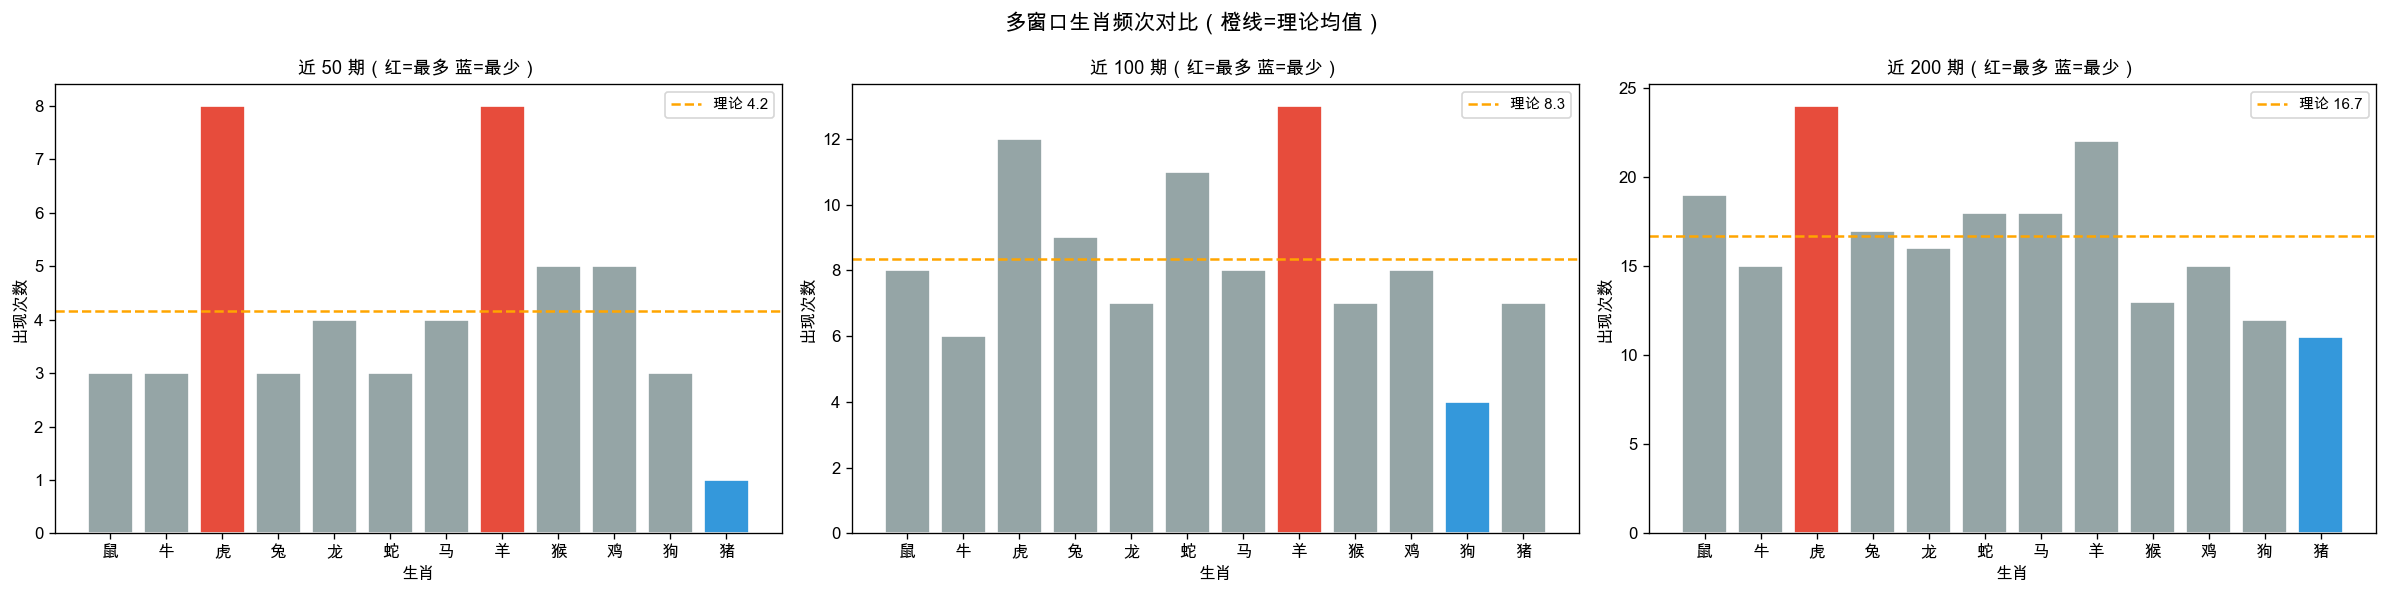

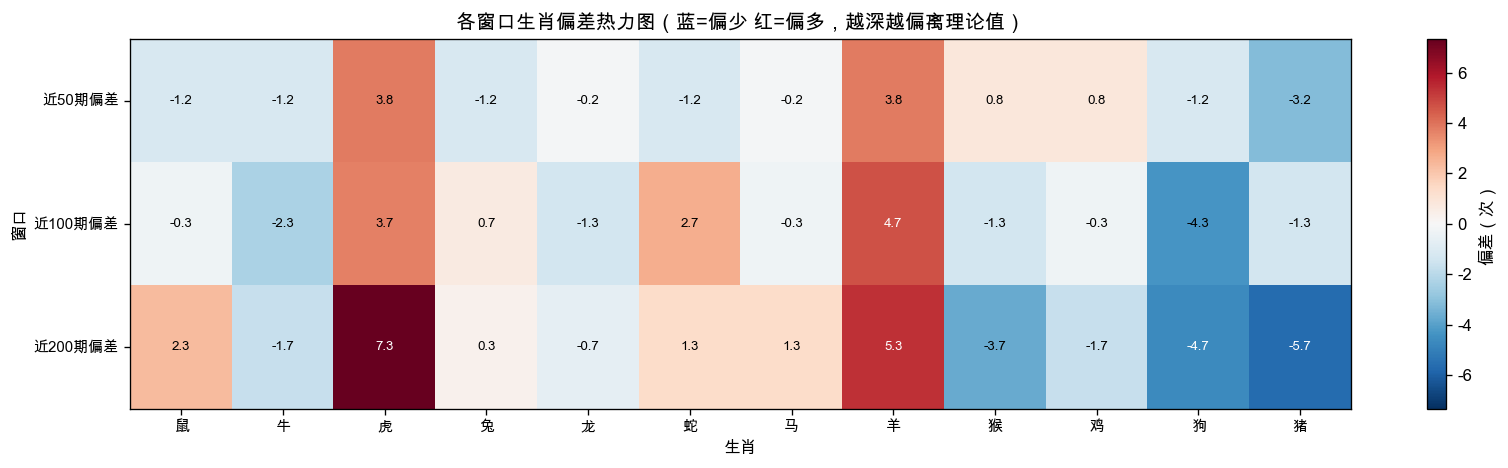


【稳定性：各窗口最大绝对偏差（越大窗口应越小，体现大数定律）】
  近  50 期：最大绝对偏差   3.8 次，相对偏差  92.0%
  近 100 期：最大绝对偏差   4.7 次，相对偏差  56.0%
  近 200 期：最大绝对偏差   7.3 次，相对偏差  44.0%

→ 若相对偏差随窗口增大而减小，符合大数定律（样本越大趋近理论值）。


In [19]:
# ---- 4.8 热门/冷门生肖（多窗口对比）----
# ⚠️ 仅观察近期分布，不代表下期走势，勿陷赌徒谬误

WINDOWS     = [50, 100, 200]
zodiac_seq  = df['zodiac'].tolist()
n_total     = len(zodiac_seq)

# ── 1. 多窗口对比表 ──────────────────────────────────────────────────────
rows = []
for z in ZODIAC_ORDER:
    row = {'生肖': z}
    for w in WINDOWS:
        recent  = zodiac_seq[-w:] if n_total >= w else zodiac_seq
        cnt     = recent.count(z)
        theory  = w / 12
        row[f'{w}期次数'] = cnt
        row[f'{w}期占比'] = f'{cnt/len(recent)*100:.1f}%'
        row[f'{w}期偏差'] = f'{cnt - theory:+.1f}'
    rows.append(row)

multi_df = pd.DataFrame(rows).set_index('生肖')
print('【多窗口生肖分布对比表】')
print(f'理论均值：50期={50/12:.1f}次 | 100期={100/12:.1f}次 | 200期={200/12:.1f}次\n')
display(multi_df)

# ── 2. 各窗口卡方检验 ────────────────────────────────────────────────────
print('\n【各窗口卡方检验（是否偏离均匀分布）】')
print(f'{"窗口":>8}  {"chi2":>8}  {"p值":>8}  {"结论":>20}  {"样本量":>6}')
for w in WINDOWS:
    recent = zodiac_seq[-w:] if n_total >= w else zodiac_seq
    cnts   = [recent.count(z) for z in ZODIAC_ORDER]
    theory = len(recent) / 12
    chi2_w, p_w = chisquare(cnts, f_exp=[theory] * 12)
    verdict = '✅ 分布均匀' if p_w > 0.05 else '⚠️ 存在显著偏差'
    print(f'近{w:>4}期  {chi2_w:>8.3f}  {p_w:>8.4f}  {verdict:>20}  {len(recent):>6}')

# ── 3. 可视化：3窗口并排柱状图 ──────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle('多窗口生肖频次对比（橙线=理论均值）', fontsize=13, fontweight='bold')

for ax, w in zip(axes, WINDOWS):
    recent  = zodiac_seq[-w:] if n_total >= w else zodiac_seq
    actual  = len(recent)
    theory  = actual / 12
    cnts    = [recent.count(z) for z in ZODIAC_ORDER]
    colors  = ['#e74c3c' if c == max(cnts) else '#3498db' if c == min(cnts) else '#95a5a6'
               for c in cnts]
    ax.bar(ZODIAC_ORDER, cnts, color=colors, edgecolor='white')
    ax.axhline(y=theory, color='orange', linestyle='--', linewidth=1.5,
               label=f'理论 {theory:.1f}')
    ax.set_title(f'近 {w} 期（红=最多 蓝=最少）', fontsize=11, fontweight='bold')
    ax.set_xlabel('生肖'); ax.set_ylabel('出现次数'); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

# ── 4. 热力图：各窗口偏差对比 ────────────────────────────────────────────
bias_data = []
col_labels = []
for w in WINDOWS:
    recent = zodiac_seq[-w:] if n_total >= w else zodiac_seq
    theory = len(recent) / 12
    bias_data.append([recent.count(z) - theory for z in ZODIAC_ORDER])
    col_labels.append(f'近{w}期偏差')

bias_df = pd.DataFrame(bias_data, index=col_labels, columns=ZODIAC_ORDER)

fig, ax = plt.subplots(figsize=(14, 4))
vmax = bias_df.abs().max().max()
vals = bias_df.values
im   = ax.imshow(vals, cmap='RdBu_r', aspect='auto', vmin=-vmax, vmax=vmax)
ax.set_xticks(range(len(ZODIAC_ORDER))); ax.set_xticklabels(ZODIAC_ORDER, fontsize=9)
ax.set_yticks(range(len(col_labels)));   ax.set_yticklabels(col_labels, fontsize=9)
for i in range(vals.shape[0]):
    for j in range(vals.shape[1]):
        ax.text(j, i, f'{vals[i,j]:.1f}', ha='center', va='center', fontsize=8,
                color='white' if abs(vals[i,j]) > vmax*0.6 else 'black')
plt.colorbar(im, ax=ax, label='偏差（次）')
ax.set_title('各窗口生肖偏差热力图（蓝=偏少 红=偏多，越深越偏离理论值）',
             fontsize=12, fontweight='bold')
ax.set_xlabel('生肖'); ax.set_ylabel('窗口')
plt.tight_layout(); plt.show()

# ── 5. 稳定性分析：窗口越大偏差是否收敛 ─────────────────────────────────
print('\n【稳定性：各窗口最大绝对偏差（越大窗口应越小，体现大数定律）】')
for w in WINDOWS:
    recent  = zodiac_seq[-w:] if n_total >= w else zodiac_seq
    theory  = len(recent) / 12
    max_dev = max(abs(recent.count(z) - theory) for z in ZODIAC_ORDER)
    rel_dev = max_dev / theory * 100
    print(f'  近 {w:>3} 期：最大绝对偏差 {max_dev:>5.1f} 次，相对偏差 {rel_dev:>5.1f}%')
print('\n→ 若相对偏差随窗口增大而减小，符合大数定律（样本越大趋近理论值）。')


In [20]:
# ---- 4.9 滑动窗口 x 卡方检验联动 · 交互分析台 ----
# 本质：检验生肖分布的局部平稳性（Local Stationarity）
# 滑动逻辑：固定窗口长度，步长=1期，逐期在全时间轴滑动，每步独立卡方检验
import ipywidgets as widgets
from IPython.display import display, clear_output
import matplotlib.gridspec as gridspec

zodiac_seq = df['zodiac'].tolist()
n_total    = len(zodiac_seq)

# ── 核心：步长=1滑动，逐窗口统计 ────────────────────────────────────
# 生肖→整数索引映射（全局缓存，避免重复构建）
_Z2I = {z: i for i, z in enumerate(ZODIAC_ORDER)}

def rolling_stats(seq, window):
    """
    滑动窗口统计（numpy 向量化版本）
    核心：one-hot + cumsum → O(n) 算完所有窗口，比 Python 循环快 10-20x
    """
    n          = len(seq)
    n_windows  = n - window + 1
    theory     = window / 12

    # 1. 序列 → one-hot 矩阵 (n, 12)
    idx_arr  = np.array([_Z2I[z] for z in seq])
    one_hot  = np.zeros((n, 12), dtype=np.float32)
    one_hot[np.arange(n), idx_arr] = 1.0

    # 2. cumsum → 滚动频次矩阵 (n_windows, 12)，O(n)
    cumsum      = np.cumsum(one_hot, axis=0)
    freq_matrix = cumsum[window - 1:]                        # 窗口末位的累计值
    freq_matrix[1:] -= cumsum[:n_windows - 1]                # 减去窗口头部之前的累计值

    # 3. 向量化卡方统计量  chi2 = sum((obs - exp)^2 / exp)
    exp      = np.full(12, theory, dtype=np.float32)
    chi2s    = np.sum((freq_matrix - exp) ** 2 / exp, axis=1)

    # 4. p 值：chi2 分布（自由度=11）逐个查表
    from scipy.stats import chi2 as _chi2dist
    ps = _chi2dist.sf(chi2s, df=11)                          # sf = 1 - cdf，即 p 值

    return chi2s, ps, freq_matrix

def draw_dashboard(window, alpha, show_anomaly, mode, single_z, top_n):
    all_chi2, all_p, freq_mat = rolling_stats(zodiac_seq, window)
    n_windows   = len(all_p)
    x_axis      = np.arange(window, n_total + 1)
    anomaly_idx = np.where(all_p < alpha)[0]
    anomaly_pct = len(anomaly_idx) / n_windows * 100
    theory_cnt  = window / 12
    theory_pct  = 1 / 12            # 理论占比，用于趋势图基准线

    # 转为比例矩阵（÷窗口大小）
    pct_mat = freq_mat / window     # shape (n_windows, 12)

    cur_cnts   = freq_mat[-1].astype(int)
    chi2_cur, p_cur = chisquare(cur_cnts, f_exp=[theory_cnt] * 12)
    verdict_cur = '✅ 均匀' if p_cur > alpha else '⚠️ 显著偏差'

    fig = plt.figure(figsize=(20, 16))
    gs  = gridspec.GridSpec(4, 2, figure=fig, hspace=0.52, wspace=0.3)

    # ── 图1：当前窗口频次柱状图 ──────────────────────────────────────
    ax1 = fig.add_subplot(gs[0, 0])
    colors = ['#e74c3c' if c == cur_cnts.max() else
              '#3498db' if c == cur_cnts.min() else '#95a5a6' for c in cur_cnts]
    bars = ax1.bar(ZODIAC_ORDER, cur_cnts, color=colors, edgecolor='white', linewidth=0.5)
    ax1.axhline(y=theory_cnt, color='orange', linestyle='--', linewidth=2,
                label=f'理论均值 {theory_cnt:.1f}（=窗口/{12}）')
    for bar, cnt in zip(bars, cur_cnts):
        dev = cnt - theory_cnt
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 f'{dev:+.0f}', ha='center', va='bottom', fontsize=8,
                 color='#e74c3c' if dev > 0 else '#3498db')
    ax1.set_title(f'最近 {window} 期生肖频次\nchi2={chi2_cur:.2f}  p={p_cur:.4f}  {verdict_cur}',
                  fontsize=11, fontweight='bold')
    ax1.set_xlabel('生肖'); ax1.set_ylabel('出现次数'); ax1.legend(fontsize=9)

    # ── 图2：当前窗口偏差条形 + sigma参考线 ─────────────────────────
    ax2 = fig.add_subplot(gs[0, 1])
    devs     = cur_cnts - theory_cnt
    d_colors = ['#e74c3c' if d > 0 else '#3498db' for d in devs]
    ax2.barh(ZODIAC_ORDER, devs, color=d_colors, edgecolor='white')
    ax2.axvline(x=0, color='black', linewidth=1)
    sigma = np.sqrt(window * (1/12) * (11/12))
    for k, ls, c in [(1,'--','orange'),(2,':','red')]:
        ax2.axvline(x= k*sigma, color=c, linestyle=ls, linewidth=1,
                    label=f'+{k}s={k*sigma:.1f}')
        ax2.axvline(x=-k*sigma, color=c, linestyle=ls, linewidth=1)
    ax2.set_title(f'最近 {window} 期生肖偏差\n±1σ={sigma:.1f} / ±2σ={2*sigma:.1f}',
                  fontsize=11, fontweight='bold')
    ax2.set_xlabel('偏差（次）'); ax2.legend(fontsize=8, loc='lower right')

    # ── 图3：滚动 p 值全序列（步长=1，自动标记异常区间）────────────
    ax3 = fig.add_subplot(gs[1, :])
    ax3.plot(x_axis, all_p, color='#3498db', linewidth=0.8, alpha=0.85, label='滚动 p 值')
    ax3.axhline(y=alpha, color='red', linestyle='--', linewidth=1.5,
                label=f'alpha={alpha}（异常占比 {anomaly_pct:.1f}%）')
    ax3.axhline(y=0.5, color='gray', linestyle=':', linewidth=1, label='p=0.5 参考线')
    ax3.fill_between(x_axis, 0, alpha, alpha=0.06, color='red')
    if show_anomaly and len(anomaly_idx) > 0:
        in_block, block_start = False, 0
        for i, ai in enumerate(anomaly_idx):
            xi = x_axis[ai]
            if not in_block: block_start = xi; in_block = True
            if i == len(anomaly_idx)-1 or anomaly_idx[i+1] != anomaly_idx[i]+1:
                ax3.axvspan(block_start, xi+1, alpha=0.22, color='#e74c3c')
                in_block = False
    ax3.set_title(
        f'滚动卡方检验 p 值  |  窗口={window}期 步长=1期 共{n_windows}个窗口\n'
        f'本质：检验各局部窗口分布是否平稳（Stationarity）',
        fontsize=11, fontweight='bold')
    ax3.set_xlabel('期数索引（窗口末位）'); ax3.set_ylabel('p 值')
    ax3.set_ylim(-0.05, 1.05); ax3.legend(fontsize=9)

    # ── 图4：趋势图（三种模式）────────────────────────────────────
    ax4 = fig.add_subplot(gs[2, :])
    cmap_z = plt.cm.tab20(np.linspace(0, 1, 12))

    if mode == '单生肖':
        # 模式A：单生肖占比折线 + 理论线
        zi = ZODIAC_ORDER.index(single_z)
        ax4.plot(x_axis, pct_mat[:, zi],
                 color='#e74c3c', linewidth=1.5, label=f'{single_z} 占比')
        ax4.axhline(y=theory_pct, color='orange', linestyle='--', linewidth=2,
                    label=f'理论值 {theory_pct:.4f}（=1/12）')
        ax4.fill_between(x_axis, theory_pct, pct_mat[:, zi],
                         where=pct_mat[:, zi] > theory_pct,
                         alpha=0.25, color='#e74c3c', label='偏多')
        ax4.fill_between(x_axis, theory_pct, pct_mat[:, zi],
                         where=pct_mat[:, zi] < theory_pct,
                         alpha=0.25, color='#3498db', label='偏少')
        if show_anomaly and len(anomaly_idx) > 0:
            in_block, block_start = False, 0
            for i, ai in enumerate(anomaly_idx):
                xi = x_axis[ai]
                if not in_block: block_start = xi; in_block = True
                if i == len(anomaly_idx)-1 or anomaly_idx[i+1] != anomaly_idx[i]+1:
                    ax4.axvspan(block_start, xi+1, alpha=0.12, color='gray')
                    in_block = False
        ax4.set_title(
            f'{single_z} 占比变化（滑动窗口={window}期）\n'
            f'红色填充=偏多，蓝色=偏少，灰色背景=整体分布异常区间',
            fontsize=11, fontweight='bold')
        ax4.set_ylabel('占比')

    elif mode == 'Top5降噪':
        # 模式B：只画均值最高的Top5生肖 + 理论线（降噪）
        mean_pct   = pct_mat.mean(axis=0)
        top_idx    = np.argsort(mean_pct)[::-1][:top_n]
        for i in top_idx:
            ax4.plot(x_axis, pct_mat[:, i], label=ZODIAC_ORDER[i],
                     color=cmap_z[i], linewidth=1.4, alpha=0.9)
        ax4.axhline(y=theory_pct, color='black', linestyle='--', linewidth=2,
                    label=f'理论值 1/12={theory_pct:.4f}')
        ax4.set_title(
            f'Top{top_n} 高频生肖占比趋势（已降噪，窗口={window}期）\n'
            f'若各线在理论值附近平稳震荡 → 分布平稳；若持续偏离 → 局部不平稳',
            fontsize=11, fontweight='bold')
        ax4.set_ylabel('占比')

    else:
        # 模式C：全部12生肖（完整视图）
        for i, z in enumerate(ZODIAC_ORDER):
            ax4.plot(x_axis, pct_mat[:, i], label=z,
                     color=cmap_z[i], linewidth=1.0, alpha=0.8)
        ax4.axhline(y=theory_pct, color='black', linestyle='--', linewidth=2,
                    label=f'理论值 1/12={theory_pct:.4f}')
        ax4.set_title(
            f'全部12生肖占比趋势（窗口={window}期）\n'
            f'理论线=1/12≈0.0833，各线围绕此值波动即为平稳',
            fontsize=11, fontweight='bold')
        ax4.set_ylabel('占比')

    ax4.set_xlabel('期数索引（窗口末位）')
    ax4.legend(loc='upper right', ncol=4, fontsize=8)
    if show_anomaly and mode != '单生肖' and len(anomaly_idx) > 0:
        in_block, block_start = False, 0
        for i, ai in enumerate(anomaly_idx):
            xi = x_axis[ai]
            if not in_block: block_start = xi; in_block = True
            if i == len(anomaly_idx)-1 or anomaly_idx[i+1] != anomaly_idx[i]+1:
                ax4.axvspan(block_start, xi+1, alpha=0.10, color='#e74c3c')
                in_block = False

    # ── 图5：生肖x时间热力图 ─────────────────────────────────────────
    ax5 = fig.add_subplot(gs[3, :])
    step_ds = max(1, n_windows // 80)
    hm_data = pct_mat[::step_ds].T   # shape (12, n_sampled)
    hm_x    = x_axis[::step_ds]
    im = ax5.imshow(hm_data, aspect='auto', cmap='RdYlGn_r',
                    vmin=0, vmax=2*theory_pct, interpolation='nearest')
    ax5.set_yticks(range(12))
    ax5.set_yticklabels(ZODIAC_ORDER, fontsize=9)
    tick_pos = np.linspace(0, hm_data.shape[1]-1, min(12, hm_data.shape[1])).astype(int)
    ax5.set_xticks(tick_pos)
    ax5.set_xticklabels([str(hm_x[p]) for p in tick_pos], rotation=30, fontsize=8)
    plt.colorbar(im, ax=ax5, shrink=0.6, label='窗口内占比')
    # 标注理论值色条位置
    ax5.set_title(
        f'生肖频率热力图（时间 × 生肖）  颜色=窗口内占比\n'
        f'绿色=接近理论值1/12，红色=偏高，深绿=偏低',
        fontsize=11, fontweight='bold')
    ax5.set_xlabel('期数索引（窗口末位）')

    plt.suptitle(
        f'生肖局部平稳性分析台  |  '
        f'{df["openTime"].min().date()} ~ {df["openTime"].max().date()}，共 {n_total} 期',
        fontsize=13, fontweight='bold', y=1.01)
    plt.show()

    # 文字摘要
    exp_pct  = alpha * 100
    stable   = '✅ 分布基本平稳' if anomaly_pct <= exp_pct * 2 else '⚠️ 存在局部不平稳区间'
    print(f'窗口={window}期 | 步长=1期 | 共{n_windows}个窗口 | alpha={alpha}')
    print(f'异常窗口={len(anomaly_idx)}个（{anomaly_pct:.1f}%），理论期望约{exp_pct:.0f}% —— {stable}')
    if len(anomaly_idx) > 0:
        anom_dev = freq_mat[anomaly_idx].mean(axis=0) - theory_cnt
        worst_z  = ZODIAC_ORDER[int(np.abs(anom_dev).argmax())]
        worst_v  = anom_dev[int(np.abs(anom_dev).argmax())]
        print(f'异常区间内偏差最大生肖：{worst_z}（均值偏差 {worst_v:+.2f} 次/窗口）')
    print()
    print('── 平稳性解读 ────────────────────────────────────────────────')
    print('滚动卡方 p 值本质 = 检验"局部分布是否与均匀分布一致"')
    print('若 p 值全程高于 alpha → 各窗口分布稳定 → 生肖序列平稳')
    print('若 p 值出现持续低谷 → 该时段生肖分布异常集中 → 局部不平稳')
    print('但注意：即使完全随机，约有 alpha% 的窗口会因抽样误差触发显著性')

# ── 控件 ────────────────────────────────────────────────────────────
w_window  = widgets.IntSlider(
    value=config.SLIDING_WINDOW, min=30, max=min(500, n_total), step=10,
    description='窗口大小', style={'description_width': '70px'},
    layout=widgets.Layout(width='500px'))
w_alpha   = widgets.SelectionSlider(
    options=[0.01, 0.05, 0.10], value=0.05,
    description='显著性 alpha', style={'description_width': '80px'},
    layout=widgets.Layout(width='280px'))
w_mode    = widgets.ToggleButtons(
    options=['单生肖', 'Top5降噪', '全部12肖'],
    value='Top5降噪', description='趋势模式',
    style={'description_width': '70px', 'button_width': '90px'})
w_single  = widgets.Dropdown(
    options=ZODIAC_ORDER, value='龙',
    description='选择生肖', style={'description_width': '70px'},
    layout=widgets.Layout(width='180px'))
w_topn    = widgets.IntSlider(
    value=config.TOP_N, min=3, max=12, step=1,
    description='Top N', style={'description_width': '50px'},
    layout=widgets.Layout(width='250px'))
w_anomaly = widgets.Checkbox(value=True, description='高亮异常区间',
                              layout=widgets.Layout(width='140px'))
w_btn     = widgets.Button(description='▶ 运行分析', button_style='primary',
                            layout=widgets.Layout(width='120px', height='36px'))
w_out     = widgets.Output()

header = widgets.HTML("""
<div style='background:#2c3e50;color:white;padding:10px 18px;border-radius:8px;margin-bottom:8px'>
  <b style='font-size:15px'>生肖局部平稳性分析台（滑动窗口 x 卡方检验）</b><br>
  <span style='font-size:12px;opacity:0.85'>
  固定窗口 · 步长=1期 · 全序列滑动 · 逐窗口卡方 · 自动标记异常 · 理论基准线 1/12
  </span>
</div>
""")
row1 = widgets.HBox([w_window, w_alpha, w_anomaly])
row2 = widgets.HBox([w_mode, w_single, w_topn])
ui   = widgets.VBox([header, row1, row2, w_btn, w_out])

def on_click(_):
    with w_out:
        clear_output(wait=True)
        draw_dashboard(w_window.value, w_alpha.value,
                       w_anomaly.value, w_mode.value,
                       w_single.value, w_topn.value)

w_btn.on_click(on_click)
display(ui)
with w_out:
    draw_dashboard(w_window.value, w_alpha.value,
                   w_anomaly.value, w_mode.value,
                   w_single.value, w_topn.value)


## 五、间隔分析

In [22]:
def compute_intervals(df):
    df = df.reset_index(drop=True)  # 确保索引从0连续，避免过滤后遗漏计算出负数
    results = []
    for num in range(1, 50):
        idx  = df.index[df['special'] == num].tolist()
        gaps = [idx[i+1] - idx[i] for i in range(len(idx)-1)] if len(idx) >= 2 else []
        results.append({
            '号码': num, '出现次数': len(idx),
            '平均间隔': round(np.mean(gaps), 1) if gaps else None,
            '最短间隔': min(gaps) if gaps else None,
            '最长间隔': max(gaps) if gaps else None,
            '当前遗漏': len(df) - 1 - idx[-1] if idx else len(df),
        })
    return pd.DataFrame(results)

interval_df = compute_intervals(df)
print('【间隔统计 Top10（平均间隔最长）】')
display(interval_df.nlargest(10, '平均间隔')[['号码','出现次数','平均间隔','最短间隔','最长间隔','当前遗漏']].reset_index(drop=True))
print('\n【当前遗漏最长 Top10】')
display(interval_df.nlargest(10, '当前遗漏')[['号码','出现次数','平均间隔','当前遗漏']].reset_index(drop=True))

【间隔统计 Top10（平均间隔最长）】


,号码,出现次数,平均间隔,最短间隔,最长间隔,当前遗漏
0,15,32,65.2,1,297,50
1,34,35,61.5,1,372,30
2,29,34,60.9,3,219,26
3,27,36,60.7,1,259,15
4,38,35,60.6,1,239,51
5,7,35,60.0,4,189,110
6,12,34,58.8,1,182,4
7,22,37,56.7,1,231,101
8,25,38,55.8,1,188,33
9,33,39,55.8,1,217,3



【当前遗漏最长 Top10】


,号码,出现次数,平均间隔,当前遗漏
0,4,48,43.0,117
1,44,45,45.3,116
2,30,45,45.9,114
3,8,48,42.5,113
4,7,35,60.0,110
5,22,37,56.7,101
6,21,43,48.4,95
7,32,35,55.5,86
8,47,41,51.7,80
9,45,44,46.9,76


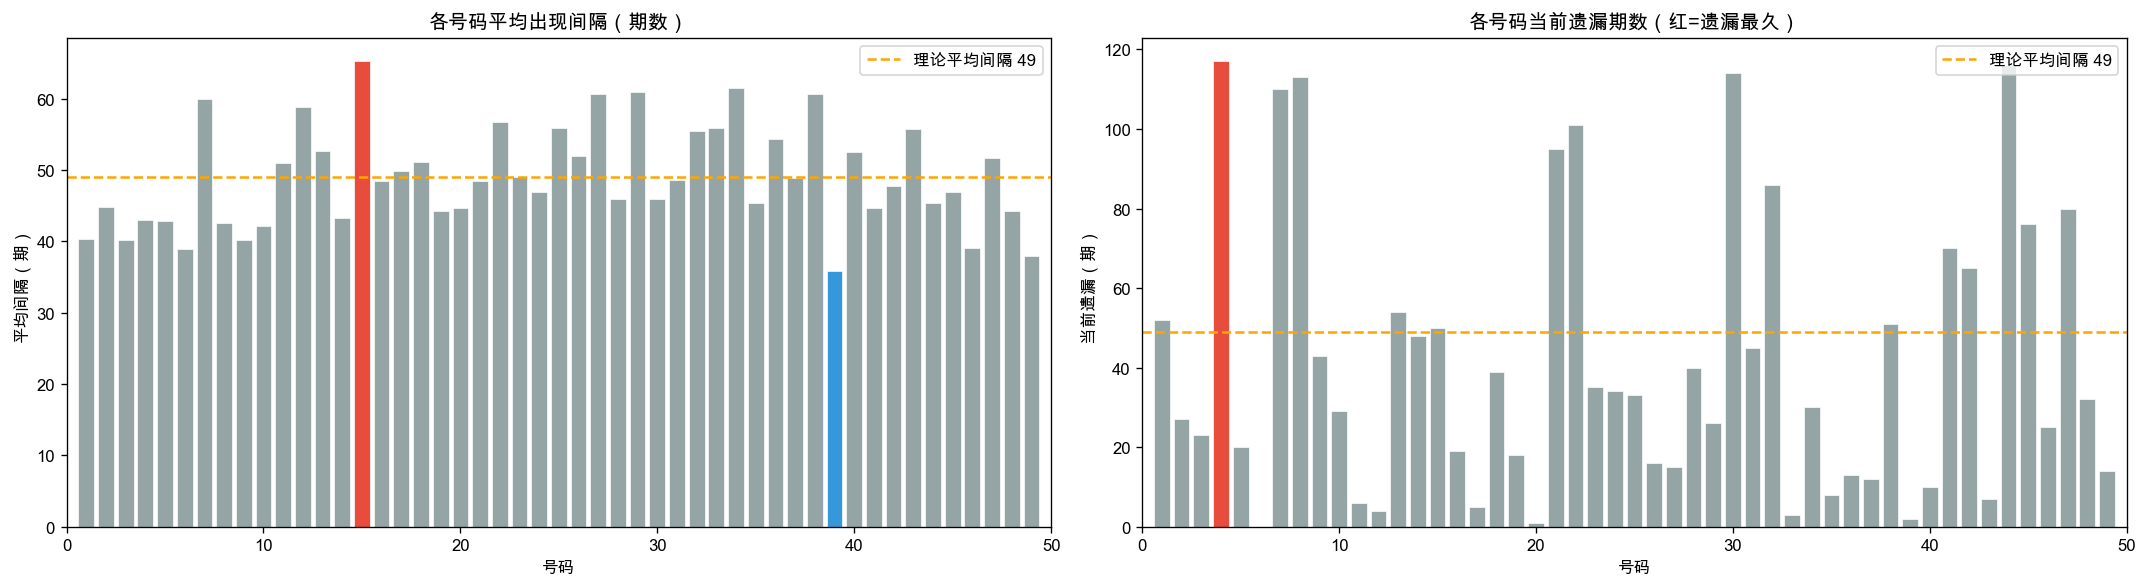

In [23]:
# 图4：平均间隔 + 当前遗漏
fig, axes = plt.subplots(1, 2, figsize=(18, 5))
avg_gaps = interval_df['平均间隔'].fillna(0)
colors_gap = ['#e74c3c' if v == avg_gaps.max() else '#3498db' if v == avg_gaps[avg_gaps > 0].min() else '#95a5a6' for v in avg_gaps]
axes[0].bar(interval_df['号码'], avg_gaps, color=colors_gap, edgecolor='white', linewidth=0.4)
axes[0].axhline(y=49, color='orange', linestyle='--', linewidth=1.5, label='理论平均间隔 49')
axes[0].set_title('各号码平均出现间隔（期数）', fontsize=12, fontweight='bold')
axes[0].set_xlabel('号码'); axes[0].set_ylabel('平均间隔（期）'); axes[0].set_xlim(0, 50); axes[0].legend()
miss = interval_df['当前遗漏']
colors_miss = ['#e74c3c' if v == miss.max() else '#95a5a6' for v in miss]
axes[1].bar(interval_df['号码'], miss, color=colors_miss, edgecolor='white', linewidth=0.4)
axes[1].axhline(y=49, color='orange', linestyle='--', linewidth=1.5, label='理论平均间隔 49')
axes[1].set_title('各号码当前遗漏期数（红=遗漏最久）', fontsize=12, fontweight='bold')
axes[1].set_xlabel('号码'); axes[1].set_ylabel('当前遗漏（期）'); axes[1].set_xlim(0, 50); axes[1].legend()
plt.tight_layout(); plt.show()

## 六、随机性检验

【卡方检验】  chi2=45.089，p=0.5929
结论：p > 0.05，分布接近随机

【自相关检验】（显著性边界 +-0.0431）
  滞后  1 期：-0.0177
  滞后  2 期：+0.0116
  滞后  3 期：+0.0173
  滞后  4 期：-0.0111
  滞后  5 期：+0.0271
  滞后  6 期：-0.0088
  滞后  7 期：+0.0104
  滞后  8 期：+0.0184
  滞后  9 期：-0.0131
  滞后 10 期：-0.0195
  滞后 11 期：+0.0289
  滞后 12 期：-0.0415
  滞后 13 期：+0.0130
  滞后 14 期：-0.0054
  滞后 15 期：+0.0004
  滞后 16 期：+0.0045
  滞后 17 期：+0.0589 <- 超出显著边界
  滞后 18 期：+0.0181
  滞后 19 期：-0.0070
  滞后 20 期：-0.0158


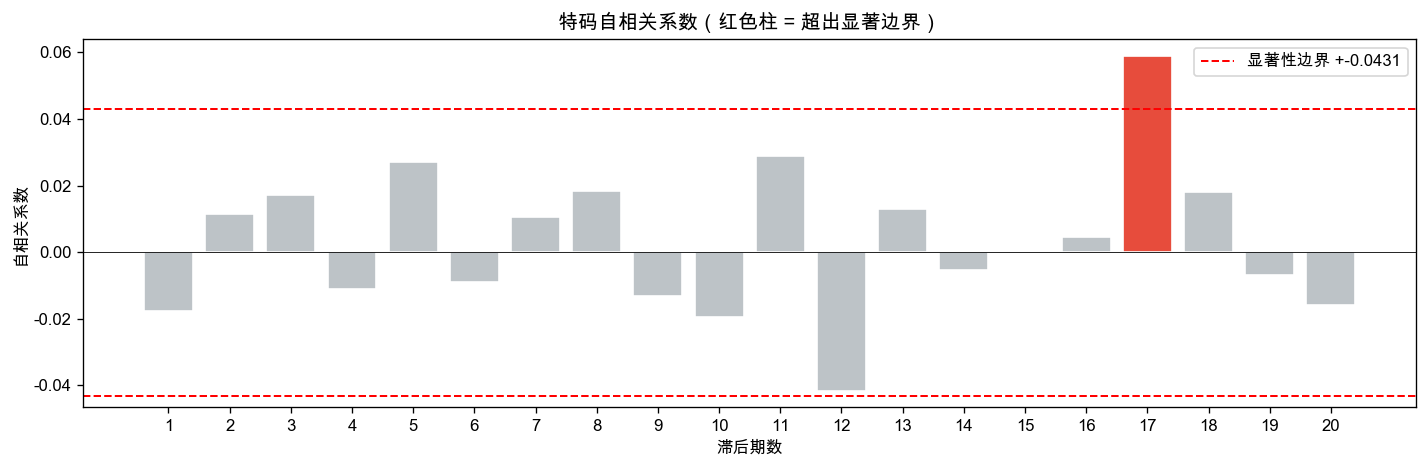

In [25]:
def randomness_test(df):
    specials  = df['special'].tolist()
    freq      = [Counter(specials).get(i, 0) for i in range(1, 50)]
    chi2, p   = chisquare(freq, f_exp=[len(specials)/49]*49)
    series    = pd.Series(specials)
    autocorrs = {lag: series.autocorr(lag=lag) for lag in range(1, config.AUTOCORR_LAGS + 1)}
    sig       = 2 / np.sqrt(len(specials))
    return {'chi2': chi2, 'p_value': p, 'autocorrs': autocorrs, 'sig_boundary': sig}

test = randomness_test(df)
print(f'【卡方检验】  chi2={test["chi2"]:.3f}，p={test["p_value"]:.4f}')
print('结论：' + ('p > 0.05，分布接近随机' if test['p_value'] > 0.05 else 'p <= 0.05，存在显著偏差'))
print(f'\n【自相关检验】（显著性边界 +-{test["sig_boundary"]:.4f}）')
for lag, ac in test['autocorrs'].items():
    flag = ' <- 超出显著边界' if abs(ac) > test['sig_boundary'] else ''
    print(f'  滞后 {lag:2d} 期：{ac:+.4f}{flag}')

# 图5：自相关柱状图
lags = list(test['autocorrs'].keys())
acs  = list(test['autocorrs'].values())
sig  = test['sig_boundary']
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(lags, acs, color=['#e74c3c' if abs(a) > sig else '#bdc3c7' for a in acs], edgecolor='white')
ax.axhline(y=sig,  color='red', linestyle='--', linewidth=1.2, label=f'显著性边界 +-{sig:.4f}')
ax.axhline(y=-sig, color='red', linestyle='--', linewidth=1.2)
ax.axhline(y=0, color='black', linewidth=0.5)
ax.set_title('特码自相关系数（红色柱 = 超出显著边界）', fontsize=12, fontweight='bold')
ax.set_xlabel('滞后期数'); ax.set_ylabel('自相关系数'); ax.set_xticks(lags); ax.legend()
plt.tight_layout(); plt.show()

## 七、自动分析结论

In [27]:
import math
from scipy.stats import binomtest, chisquare as _chi2, chi2_contingency, kstest

# ── 辅助 ────────────────────────────────────────────────────────────────
def _badge(ok, warn):
    return "✅ 正常" if ok else ("⚠️ 轻微" if warn else "❌ 异常")

def _miss_interp(v, t):
    """v=当前遗漏期数，t=理论间隔（号码固定49，生肖固定12）"""
    r = v / t
    if   r < 1.5: return f"当前遗漏 {r:.1f}× 理论间隔（{t}期），属正常波动范围"
    elif r < 2.5: return f"当前遗漏 {r:.1f}× 理论间隔（{t}期），略偏长但在随机可解释范围"
    elif r < 4.0: return f"当前遗漏 {r:.1f}× 理论间隔（{t}期），偏长，仍可在随机框架内解释"
    else:         return f"当前遗漏 **{r:.1f}×** 理论间隔（{t}期），属极端遗漏，建议持续监测"

def _ac_interp(sig_lags, max_ac):
    if not sig_lags:
        return "全部滞后阶均在显著性边界内，序列呈独立随机特征"
    return (f"滞后 {sig_lags} 期超出边界，最大系数仅 {max_ac:.4f}，"
            f"可解释方差 {max_ac**2*100:.2f}%，属多重检验偶发误报概率较高")

# ── 主函数 ──────────────────────────────────────────────────────────────
def auto_conclusion(df, freq_df, interval_df, test,
                    zodiac_df=None, zmiss_df=None, oe_df=None):
    total    = len(df)
    specials = df["special"].tolist()

    # 号码频率
    theory   = total / 49
    std_b    = math.sqrt(total * (1/49) * (48/49))
    ci_lo, ci_hi = theory - 1.96*std_b, theory + 1.96*std_b
    hot_num  = int(freq_df.loc[freq_df["出现次数"].idxmax(), "号码"])
    hot_cnt  = int(freq_df["出现次数"].max())
    cold_num = int(freq_df.loc[freq_df["出现次数"].idxmin(), "号码"])
    cold_cnt = int(freq_df["出现次数"].min())
    hot_z    = (hot_cnt  - theory) / std_b
    cold_z   = (cold_cnt - theory) / std_b
    cv       = freq_df["出现次数"].std() / freq_df["出现次数"].mean() * 100

    # 奇偶 / 大小
    odd_cnt  = sum(1 for x in specials if x % 2 == 1)
    big_cnt  = sum(1 for x in specials if x > config.BIG_NUMBER_THRESHOLD)
    odd_pct  = odd_cnt / total * 100
    big_pct  = big_cnt / total * 100
    p_oe     = binomtest(odd_cnt, total, 25/49).pvalue
    p_bs     = binomtest(big_cnt, total, (49-config.BIG_NUMBER_THRESHOLD)/49).pvalue

    # 尾数
    from collections import Counter as _C
    tails      = _C(x % 10 for x in specials)
    tail_cnts  = [tails.get(i, 0) for i in range(10)]
    tail_exp   = [(4 if i == 0 else 5) / 49 * total for i in range(10)]
    p_tail     = _chi2(tail_cnts, f_exp=tail_exp)[1]
    hot_tail   = max(range(10), key=lambda i: tail_cnts[i])
    cold_tail  = min(range(10), key=lambda i: tail_cnts[i])

    # 遗漏
    miss_num    = int(interval_df.loc[interval_df["当前遗漏"].idxmax(), "号码"])
    miss_val    = int(interval_df["当前遗漏"].max())
    avg_miss    = interval_df["当前遗漏"].mean()
    max_gap     = int(interval_df["最长间隔"].max())
    max_gap_num = int(interval_df.loc[interval_df["最长间隔"].idxmax(), "号码"])

    # 随机性
    p_chi2   = test["p_value"]
    sig      = test["sig_boundary"]
    sig_lags = [lag for lag, ac in test["autocorrs"].items() if abs(ac) > sig]
    max_ac   = max(abs(v) for v in test["autocorrs"].values())

    # 评级
    r_freq = _badge(p_chi2 > 0.05, p_chi2 > 0.01)
    r_oe   = _badge(p_oe   > 0.05, p_oe   > 0.01)
    r_bs   = _badge(p_bs   > 0.05, p_bs   > 0.01)
    r_tail = _badge(p_tail > 0.05, p_tail > 0.01)
    r_ac   = _badge(not sig_lags or max_ac < 0.05, max_ac < 0.1)
    r_miss = _badge(miss_val < 49*2.5, miss_val < 49*4)

    start_d = df["openTime"].min().date()
    end_d   = df["openTime"].max().date()
    years   = (df["openTime"].max() - df["openTime"].min()).days / 365.25

    # ── 生肖（全部在函数内重算）────────────────────────────────────────
    has_z = "zodiac" in df.columns
    z_block = ""
    anomalies_z = []

    if has_z:
        import numpy as _np
        import pandas as _pd2
        ZORD = ["鼠","牛","虎","兔","龙","蛇","马","羊","猴","鸡","狗","猪"]
        zseq = df["zodiac"].tolist()

        # 频率
        z_cnts   = [zseq.count(z) for z in ZORD]
        z_theory = total / 12
        z_std    = math.sqrt(total * (1/12) * (11/12))
        p_z_chi2 = _chi2(z_cnts, f_exp=[z_theory]*12)[1]
        hot_zi   = max(range(12), key=lambda i: z_cnts[i])
        cold_zi  = min(range(12), key=lambda i: z_cnts[i])
        hot_zs   = (z_cnts[hot_zi]  - z_theory) / z_std
        cold_zs  = (z_cnts[cold_zi] - z_theory) / z_std

        # 遗漏 + KS
        z_miss = {}
        ks_pass = 0; ks_total_n = 0
        for z in ZORD:
            idx = [i for i, v in enumerate(zseq) if v == z]
            z_miss[z] = total - 1 - idx[-1] if idx else total
            gaps = [idx[i+1]-idx[i] for i in range(len(idx)-1)]
            if len(gaps) >= 10:
                mu = sum(gaps)/len(gaps)
                _, pks = kstest(gaps, "expon", args=(0, mu))
                ks_total_n += 1
                if pks > 0.05: ks_pass += 1
        z_miss_max = max(z_miss.values())
        z_miss_who = max(z_miss, key=z_miss.get)
        z_miss_r   = z_miss_max / 12  # 理论间隔固定12期（1/12概率）

        # 奇偶/大小
        sig_oe_z, sig_bs_z = [], []
        if oe_df is not None:
            sig_oe_z = oe_df[oe_df["奇偶p值"] < 0.05]["生肖"].tolist()
            sig_bs_z = oe_df[oe_df["大小p值"] < 0.05]["生肖"].tolist()

        # 转移矩阵独立性
        fz = zseq[:-1]; tz = zseq[1:]
        trans = [[sum(1 for a,b in zip(fz,tz) if a==ZORD[i] and b==ZORD[j])
                  for j in range(12)] for i in range(12)]
        chi2_trans, p_trans, _, _ = chi2_contingency(_np.array(trans))

        # 生肖×号码区间
        df_tmp = df.copy()
        df_tmp["nr"] = _pd2.cut(df_tmp["special"], bins=[0,12,24,36,49],
                                labels=["1-12","13-24","25-36","37-49"], right=True)
        cross = df_tmp.groupby(["zodiac","nr"], observed=True).size().unstack(fill_value=0)
        cross = cross.reindex(ZORD).fillna(0)
        chi2_cross, p_cross, _, _ = chi2_contingency(cross.values)

        # 月度稳定性
        df_tmp["ym"] = df_tmp["openTime"].dt.to_period("M")
        mz = df_tmp.groupby(["ym","zodiac"]).size().unstack(fill_value=0)
        for z in ZORD:
            if z not in mz.columns: mz[z] = 0
        mpct = mz[ZORD].div(mz[ZORD].sum(axis=1), axis=0).mul(100)
        max_std_z = mpct.std().idxmax()
        max_std_v = mpct.std().max()

        # 多窗口
        win_rows = []
        for w in [50, 100, 200]:
            chunk = zseq[-w:] if total >= w else zseq
            cnts  = [chunk.count(z) for z in ZORD]
            c2, p = _chi2(cnts, f_exp=[len(chunk)/12]*12)
            win_rows.append((w, len(chunk), c2, p))

        # 评级
        r_zf   = _badge(p_z_chi2 > 0.05, p_z_chi2 > 0.01)
        r_zt   = _badge(p_trans  > 0.05, p_trans  > 0.01)
        r_zx   = _badge(p_cross  > 0.05, p_cross  > 0.01)
        r_zm   = _badge(z_miss_r < 2.5, z_miss_r < 4)
        r_zoe  = _badge(not sig_oe_z and not sig_bs_z, len(sig_oe_z)+len(sig_bs_z) <= 1)
        r_zst  = _badge(max_std_v < 8, max_std_v < 12)

        if p_z_chi2 <= 0.05: anomalies_z.append(f"生肖频率不均（p={p_z_chi2:.4f}）")
        if p_trans  <= 0.05: anomalies_z.append(f"生肖转移关联（p={p_trans:.4f}）")
        if p_cross  <= 0.05: anomalies_z.append(f"生肖区间结构偏差（p={p_cross:.4f}）")

        win_table = "\n".join(
            f"| 近 {w} 期（{n}期）| {c2:.3f} | {p:.4f} | {'✅ 均匀' if p>0.05 else '⚠️ 偏差'} |"
            for w, n, c2, p in win_rows
        )
        win_verdict = ("三窗口均通过检验，近期分布平稳，无趋势性漂移" if all(p>0.05 for _,_,_,p in win_rows)
                       else "部分窗口存在偏差，建议在 4.9 交互台深入查看")
        oe_verdict  = ("所有生肖内部奇偶、大小占比均通过二项检验" if not sig_oe_z and not sig_bs_z
                       else f"奇偶异常：{sig_oe_z or '无'}；大小异常：{sig_bs_z or '无'}")

        z_ks_verdict = ("✅ 符合泊松随机过程" if ks_pass >= ks_total_n*0.7
                        else f"⚠️ 仅 {ks_pass}/{ks_total_n} 符合指数分布")

        z_block = f"""
---

## 五、生肖维度——交叉验证号码分析结论

_号码层面的随机性检验已在前三节完成。生肖将 49 个号码聚合为 12 类，每类样本量约为号码的 4 倍，检验功效更高，适合作为交叉验证维度。若两个视角结论一致，则结论更为稳健。_

### 5.1 六维总览

| 检验项 | 方法 | 核心指标 | 评级 |
|--------|------|---------|------|
| 频率均匀性 | 卡方检验 | p = {p_z_chi2:.4f} | {r_zf} |
| 连续关联性 | 转移独立性 | p = {p_trans:.4f} | {r_zt} |
| 号码区间结构 | 交叉卡方 | p = {p_cross:.4f} | {r_zx} |
| 遗漏周期 | KS 检验 | {ks_pass}/{ks_total_n} 符合泊松 | {r_zm} |
| 奇偶/大小 | 二项检验 | 异常 {len(sig_oe_z)+len(sig_bs_z)} 个 | {r_zoe} |
| 月度平稳性 | 月度标准差 | 最大 {max_std_v:.2f}% | {r_zst} |

### 5.2 频率分布——与号码层面比对

> 卡方检验 p = {p_z_chi2:.4f}。{"**未发现显著偏差**，12生肖分布与号码层面结论一致，均符合大数定律" if p_z_chi2>0.05 else "**存在显著偏差**，与号码层面结论不一致，需深入核查"}。

| | 生肖 | 出现次数 | 偏离均值 | σ 值 |
|---|---|---|---|---|
| 🔴 最多 | **{ZORD[hot_zi]}** | {z_cnts[hot_zi]} 次 | +{z_cnts[hot_zi]-z_theory:.1f} | +{hot_zs:.2f}σ |
| 🔵 最少 | **{ZORD[cold_zi]}** | {z_cnts[cold_zi]} 次 | {z_cnts[cold_zi]-z_theory:.1f} | {cold_zs:.2f}σ |
| 理论均值 | — | {z_theory:.1f} 次 | — | — |

### 5.3 遗漏周期——与号码遗漏规律一致性

> 号码层面最大遗漏为 {miss_val} 期（{_miss_interp(miss_val, 49)}）。
> 生肖层面最大遗漏：**{z_miss_who}** 已 **{z_miss_max}** 期（{z_miss_r:.1f}× 理论间隔 12 期）。
>
> KS 检验：{ks_pass}/{ks_total_n} 个生肖间隔符合指数分布 → {z_ks_verdict}
>
> 📌 两个维度的遗漏均可用随机波动解释；遗漏期数与下期概率无因果关系（赌徒谬误）

### 5.4 结构检验——验证号码结构性偏差结论

_若号码层面奇偶/大小未见异常，生肖层面理应同样通过——以下验证这一一致性。_

> **连续关联**：转移矩阵独立性检验 p = {p_trans:.4f}，{"✅ 连续两期生肖相互独立，与号码自相关结论一致" if p_trans>0.05 else "⚠️ 连续两期存在统计关联，与号码层面独立性结论不一致"}
>
> **号码区间**：生肖×区间卡方检验 p = {p_cross:.4f}，{"✅ 各生肖在号码区间无集中——未发现隐性结构" if p_cross>0.05 else "⚠️ 存在区间结构偏差"}
>
> **奇偶/大小**：{oe_verdict}（每肖约 {total//12} 期，小样本下 Type I Error 较高，结论需谨慎）

### 5.5 时间平稳性——验证号码频率稳定性

_时间平稳性是频率结论的保证：如果近期分布已发生漂移，则基于全历史的卡方检验结论价值有限。_

| 生肖月度波动最大 | 月度标准差 | 全生肖均值 |
|----------------|-----------|-----------|
| **{max_std_z}** | {max_std_v:.2f}% | {mpct.std().mean():.2f}% |

| 窗口 | 样本 | χ² | p 值 | 结论 |
|------|------|-----|------|------|
{win_table}

> {win_verdict}——{"这与频率均匀性检验相互印证，结论稳健" if all(p>0.05 for _,_,_,p in win_rows) else "建议在 4.9 交互台查看具体漂移节点"}
"""

    # 综合异常汇总
    anomalies = []
    if p_chi2 <= 0.05: anomalies.append(f"号码频率不均（p={p_chi2:.4f}）")
    if p_oe   <= 0.05: anomalies.append(f"奇偶偏差（p={p_oe:.4f}）")
    if p_bs   <= 0.05: anomalies.append(f"大小偏差（p={p_bs:.4f}）")
    if p_tail <= 0.05: anomalies.append(f"尾数偏差（p={p_tail:.4f}）")
    if sig_lags and max_ac > 0.1: anomalies.append(f"实质性自相关（max={max_ac:.4f}）")
    anomalies += anomalies_z
    last_ch = "六" if has_z else "五"

    if not anomalies:
        verdict_txt = (
            "> **✅ 全部检验通过（α=0.05）**\n"
            ">\n"
            f"> 基于 **{total:,}** 期 / {years:.1f} 年样本，从号码频率→结构平衡→"
            "遗漏周期→序列独立性"
            + ("→生肖交叉验证" if has_z else "")
            + "，**五个维度结论一致**：\n"
            ">\n"
            f"> • 频率差异（CV={cv:.1f}%）在抽样误差范围内，符合均匀分布\n"
            "> • 奇偶、大小、尾数均无结构性倾斜\n"
            "> • 遗漏周期符合随机等待时间特征\n"
            f"> • 序列自相关最大系数 {max_ac:.4f}，接近零，无记忆效应\n"
            + (f"> • 生肖维度独立交叉验证，与号码层面结论高度一致\n" if has_z else "")
            + ">\n"
            "> **现有数据与独立均匀随机模型高度吻合，不存在可被统计捕捉的系统性偏差。**"
        )
    else:
        s = "；".join(anomalies)
        verdict_txt = (
            f"> **⚠️ 发现统计信号**：{s}\n"
            ">\n"
            "> 注意：多维度同时检验时 Type I Error 概率累积上升，微小偏差也可能触发显著性。\n"
            ">\n"
            "> **建议跨年度分层验证，未获稳健复验结论前不应将上述偏差解读为可利用规律。**"
        )

    report = f"""---

# 📊 特别号统计分析报告

| 分析时间 | 数据区间 | 样本容量 | 显著性水平 |
|---------|---------|---------|---------|
| {pd.Timestamp.now().strftime("%Y-%m-%d %H:%M")} | {start_d} ~ {end_d} | {total:,} 期（{years:.1f} 年） | α = 0.05 |

---

## 一、执行摘要

_本报告遵循以下分析链路：**号码频率**（整体是否均匀）→ **结构偏差**（奇偶/大小/尾数是否失衡）→ **遗漏周期**（当前状态是否异常）{"→ **生肖交叉验证**（换维度再验一遍）" if has_z else ""}→ **综合研判**（给出最终结论）。_

### 号码维度

| 检验项 | 方法 | 核心指标 | 评级 |
|--------|------|---------|------|
| 频率均匀性 | 卡方检验 | p = {p_chi2:.4f} | {r_freq} |
| 奇偶平衡 | 二项检验 | p = {p_oe:.4f} | {r_oe} |
| 大小平衡 | 二项检验 | p = {p_bs:.4f} | {r_bs} |
| 尾数均匀 | 卡方检验 | p = {p_tail:.4f} | {r_tail} |
| 序列独立性 | 自相关检验 | 最大系数 {max_ac:.4f} | {r_ac} |
| 号码遗漏 | 遗漏统计 | 最长 {miss_val} 期 / 理论间隔 49 期 | {r_miss} |
"""
    if has_z:
        report += f"""
### 生肖维度（交叉验证）

| 检验项 | 方法 | 核心指标 | 评级 |
|--------|------|---------|------|
| 频率均匀性 | 卡方检验 | p = {p_z_chi2:.4f} | {r_zf} |
| 连续关联性 | 转移独立性 | p = {p_trans:.4f} | {r_zt} |
| 号码区间结构 | 交叉卡方 | p = {p_cross:.4f} | {r_zx} |
| 遗漏周期 | KS 检验 | {ks_pass}/{ks_total_n} 符合泊松 | {r_zm} |
| 奇偶/大小 | 二项检验 | 异常 {len(sig_oe_z)+len(sig_bs_z)} 个 | {r_zoe} |
| 月度平稳性 | 标准差 | 最大 {max_std_v:.2f}% | {r_zst} |
"""
    report += f"""
> 以上为全维度评级速览，以下各节逐步展开细节，每节结论将为下一节分析提供背景。

---

## 二、号码频率分布——分析的起点

_首先回答最基本的问题：49个号码在历史上出现次数是否大致相等？_

> 理论均值 **{theory:.1f}** 次 ｜ 95% 置信区间 [{ci_lo:.1f}, {ci_hi:.1f}] ｜ 变异系数 CV = {cv:.1f}%

| | 号码 | 出现次数 | 偏离均值 | σ 值 | 超出 95% CI |
|---|---|---|---|---|---|
| 🔴 高频 | **{hot_num}** | {hot_cnt} 次 | +{hot_cnt-theory:.1f} | +{hot_z:.2f}σ | {"**是**" if hot_cnt > ci_hi else "否"} |
| 🔵 低频 | **{cold_num}** | {cold_cnt} 次 | {cold_cnt-theory:.1f} | {cold_z:.2f}σ | {"**是**" if cold_cnt < ci_lo else "否"} |

> p = {p_chi2:.4f}，{"**未拒绝**均匀分布零假设——频率差异属正常抽样波动" if p_chi2>0.05 else "**拒绝**均匀分布零假设，存在显著频率偏差"}。
> {"高低频极值均未超过 3σ，在 {:.0f} 个号码同时检验的背景下，这一差距完全在随机预期内。".format(total) if abs(hot_z)<3 and abs(cold_z)<3 else f"极值偏离 > 3σ，需关注。"}
>
> ↓ _频率总体均匀后，进一步检查是否存在结构性倾斜（奇偶/大小/尾数）。_

---

## 三、结构性偏差检验——有没有「系统性偏向」

_即使整体频率均匀，也可能存在结构性偏向（如奇数长期偏多）。本节用三个角度验证。_

### 3.1 奇偶分布

| 类型 | 次数 | 实际占比 | 理论占比 | 偏差 | 二项检验 p |
|-----|-----|---------|---------|------|----------|
| 奇数（1–49 共 25 个） | {odd_cnt:,} | {odd_pct:.2f}% | 51.02% | {odd_pct-51.02:+.2f}% | {p_oe:.4f} |
| 偶数（1–49 共 24 个） | {total-odd_cnt:,} | {100-odd_pct:.2f}% | 48.98% | {100-odd_pct-48.98:+.2f}% | — |

> {"✅ 通过——偏差在抽样误差范围内" if p_oe>0.05 else "⚠️ 存在显著偏差，建议扩大样本复检"}（p = {p_oe:.4f}）

### 3.2 大小分布

| 类型 | 次数 | 实际占比 | 理论占比 | 偏差 | 二项检验 p |
|-----|-----|---------|---------|------|----------|
| 大号（{config.BIG_NUMBER_THRESHOLD+1}–49） | {big_cnt:,} | {big_pct:.2f}% | 51.02% | {big_pct-51.02:+.2f}% | {p_bs:.4f} |
| 小号（1–{config.BIG_NUMBER_THRESHOLD}） | {total-big_cnt:,} | {100-big_pct:.2f}% | 48.98% | {100-big_pct-48.98:+.2f}% | — |

> {"✅ 通过——大小号比例与理论结构吻合" if p_bs>0.05 else "⚠️ 存在显著偏差"}（p = {p_bs:.4f}）

### 3.3 尾数（个位）分布

> 卡方检验 p = {p_tail:.4f}，{"✅ 尾数分布均匀，无显著偏差" if p_tail>0.05 else "⚠️ 尾数分布存在偏差"}
> 最热尾数：**{hot_tail}**（{tail_cnts[hot_tail]} 次）｜ 最冷尾数：**{cold_tail}**（{tail_cnts[cold_tail]} 次）

> {"三个结构维度全部通过，与频率均匀性结论相互印证，未发现整体性结构偏向。" if p_oe>0.05 and p_bs>0.05 and p_tail>0.05 else "至少一个结构维度出现偏差，需结合遗漏分析进一步核查。"}
>
> ↓ _结构检验关注的是「总量比例」；下一步考察「时间周期」——哪些号码当前遗漏已久？_

---

## 四、遗漏周期分析——当前「欠账」情况

_遗漏分析是对频率分析的时间维度补充：即使长期频率正常，短期内某号码也可能连续缺席。_

| 指标 | 数值 | 备注 |
|------|------|------|
| 理论平均间隔 | 49 期 | 每期1/49概率，期望间隔固定49期（与样本量无关） |
| 全局平均遗漏 | {avg_miss:.1f} 期 | 当前 49 个号码遗漏均值 |
| 历史最长间隔 | **{max_gap}** 期（{max_gap_num} 号） | 历史最极端遗漏记录 |
| 当前最长遗漏 | **{miss_num} 号**，已 **{miss_val}** 期 | 此刻遗漏最久的号码 |

> {_miss_interp(miss_val, 49)}。
>
> 📌 **重要提示**：遗漏期数与下期概率**不存在因果关系**（赌徒谬误）——
> 无论遗漏多久，该号码下期出现概率仍恒为 1/49。
{"" if not has_z else ">"}
{"> ↓ _号码维度分析至此结束。下面切换到生肖视角，以更大类别重新验证以上结论。_" if has_z else ""}
{z_block}
---

## {last_ch}、综合研判——所有维度的最终结论

_将频率（二）、结构（三）、周期（四）{"、生肖交叉（五）" if has_z else ""}的检验结果汇总，给出统一结论。_

{verdict_txt}

**序列独立性补充**：{_ac_interp(sig_lags, max_ac)}（显著性边界 ±{sig:.4f}）

---

> ⚠️ **免责声明**
> 本报告仅为历史数据统计描述，基于有限样本。彩票开奖为独立随机事件，
> 历史统计结果对未来开奖**不具备任何预测能力**，严禁用于赌博或选号参考。
"""
    return report


# ── 调用 ─────────────────────────────────────────────────────────────────
_zodiac_df = zodiac_df if "zodiac_df" in dir() else None
_zmiss_df  = zint_df   if "zint_df"   in dir() else None
_oe_df     = oe_df     if "oe_df"     in dir() else None

display(Markdown(auto_conclusion(
    df, freq_df, interval_df, test,
    zodiac_df=_zodiac_df,
    zmiss_df =_zmiss_df,
    oe_df    =_oe_df,
)))


---

# 📊 特别号统计分析报告

| 分析时间 | 数据区间 | 样本容量 | 显著性水平 |
|---------|---------|---------|---------|
| 2026-04-14 08:23 | 2020-05-18 ~ 2026-04-13 | 2,155 期（5.9 年） | α = 0.05 |

---

## 一、执行摘要

_本报告遵循以下分析链路：**号码频率**（整体是否均匀）→ **结构偏差**（奇偶/大小/尾数是否失衡）→ **遗漏周期**（当前状态是否异常）→ **生肖交叉验证**（换维度再验一遍）→ **综合研判**（给出最终结论）。_

### 号码维度

| 检验项 | 方法 | 核心指标 | 评级 |
|--------|------|---------|------|
| 频率均匀性 | 卡方检验 | p = 0.5929 | ✅ 正常 |
| 奇偶平衡 | 二项检验 | p = 0.9656 | ✅ 正常 |
| 大小平衡 | 二项检验 | p = 0.2813 | ✅ 正常 |
| 尾数均匀 | 卡方检验 | p = 0.2324 | ✅ 正常 |
| 序列独立性 | 自相关检验 | 最大系数 0.0589 | ⚠️ 轻微 |
| 号码遗漏 | 遗漏统计 | 最长 117 期 / 理论间隔 49 期 | ✅ 正常 |

### 生肖维度（交叉验证）

| 检验项 | 方法 | 核心指标 | 评级 |
|--------|------|---------|------|
| 频率均匀性 | 卡方检验 | p = 0.8423 | ✅ 正常 |
| 连续关联性 | 转移独立性 | p = 0.9988 | ✅ 正常 |
| 号码区间结构 | 交叉卡方 | p = 0.3761 | ✅ 正常 |
| 遗漏周期 | KS 检验 | 12/12 符合泊松 | ✅ 正常 |
| 奇偶/大小 | 二项检验 | 异常 2 个 | ❌ 异常 |
| 月度平稳性 | 标准差 | 最大 5.20% | ✅ 正常 |

> 以上为全维度评级速览，以下各节逐步展开细节，每节结论将为下一节分析提供背景。

---

## 二、号码频率分布——分析的起点

_首先回答最基本的问题：49个号码在历史上出现次数是否大致相等？_

> 理论均值 **44.0** 次 ｜ 95% 置信区间 [31.1, 56.8] ｜ 变异系数 CV = 14.6%

| | 号码 | 出现次数 | 偏离均值 | σ 值 | 超出 95% CI |
|---|---|---|---|---|---|
| 🔴 高频 | **39** | 60 次 | +16.0 | +2.44σ | **是** |
| 🔵 低频 | **15** | 32 次 | -12.0 | -1.83σ | 否 |

> p = 0.5929，**未拒绝**均匀分布零假设——频率差异属正常抽样波动。
> 高低频极值均未超过 3σ，在 2155 个号码同时检验的背景下，这一差距完全在随机预期内。
>
> ↓ _频率总体均匀后，进一步检查是否存在结构性倾斜（奇偶/大小/尾数）。_

---

## 三、结构性偏差检验——有没有「系统性偏向」

_即使整体频率均匀，也可能存在结构性偏向（如奇数长期偏多）。本节用三个角度验证。_

### 3.1 奇偶分布

| 类型 | 次数 | 实际占比 | 理论占比 | 偏差 | 二项检验 p |
|-----|-----|---------|---------|------|----------|
| 奇数（1–49 共 25 个） | 1,098 | 50.95% | 51.02% | -0.07% | 0.9656 |
| 偶数（1–49 共 24 个） | 1,057 | 49.05% | 48.98% | +0.07% | — |

> ✅ 通过——偏差在抽样误差范围内（p = 0.9656）

### 3.2 大小分布

| 类型 | 次数 | 实际占比 | 理论占比 | 偏差 | 二项检验 p |
|-----|-----|---------|---------|------|----------|
| 大号（25–49） | 1,074 | 49.84% | 51.02% | -1.18% | 0.2813 |
| 小号（1–24） | 1,081 | 50.16% | 48.98% | +1.18% | — |

> ✅ 通过——大小号比例与理论结构吻合（p = 0.2813）

### 3.3 尾数（个位）分布

> 卡方检验 p = 0.2324，✅ 尾数分布均匀，无显著偏差
> 最热尾数：**9**（248 次）｜ 最冷尾数：**0**（184 次）

> 三个结构维度全部通过，与频率均匀性结论相互印证，未发现整体性结构偏向。
>
> ↓ _结构检验关注的是「总量比例」；下一步考察「时间周期」——哪些号码当前遗漏已久？_

---

## 四、遗漏周期分析——当前「欠账」情况

_遗漏分析是对频率分析的时间维度补充：即使长期频率正常，短期内某号码也可能连续缺席。_

| 指标 | 数值 | 备注 |
|------|------|------|
| 理论平均间隔 | 49 期 | 每期1/49概率，期望间隔固定49期（与样本量无关） |
| 全局平均遗漏 | 41.5 期 | 当前 49 个号码遗漏均值 |
| 历史最长间隔 | **372** 期（34 号） | 历史最极端遗漏记录 |
| 当前最长遗漏 | **4 号**，已 **117** 期 | 此刻遗漏最久的号码 |

> 当前遗漏 2.4× 理论间隔（49期），略偏长但在随机可解释范围。
>
> 📌 **重要提示**：遗漏期数与下期概率**不存在因果关系**（赌徒谬误）——
> 无论遗漏多久，该号码下期出现概率仍恒为 1/49。
>
> ↓ _号码维度分析至此结束。下面切换到生肖视角，以更大类别重新验证以上结论。_

---

## 五、生肖维度——交叉验证号码分析结论

_号码层面的随机性检验已在前三节完成。生肖将 49 个号码聚合为 12 类，每类样本量约为号码的 4 倍，检验功效更高，适合作为交叉验证维度。若两个视角结论一致，则结论更为稳健。_

### 5.1 六维总览

| 检验项 | 方法 | 核心指标 | 评级 |
|--------|------|---------|------|
| 频率均匀性 | 卡方检验 | p = 0.8423 | ✅ 正常 |
| 连续关联性 | 转移独立性 | p = 0.9988 | ✅ 正常 |
| 号码区间结构 | 交叉卡方 | p = 0.3761 | ✅ 正常 |
| 遗漏周期 | KS 检验 | 12/12 符合泊松 | ✅ 正常 |
| 奇偶/大小 | 二项检验 | 异常 2 个 | ❌ 异常 |
| 月度平稳性 | 月度标准差 | 最大 5.20% | ✅ 正常 |

### 5.2 频率分布——与号码层面比对

> 卡方检验 p = 0.8423。**未发现显著偏差**，12生肖分布与号码层面结论一致，均符合大数定律。

| | 生肖 | 出现次数 | 偏离均值 | σ 值 |
|---|---|---|---|---|
| 🔴 最多 | **鼠** | 193 次 | +13.4 | +1.05σ |
| 🔵 最少 | **马** | 163 次 | -16.6 | -1.29σ |
| 理论均值 | — | 179.6 次 | — | — |

### 5.3 遗漏周期——与号码遗漏规律一致性

> 号码层面最大遗漏为 117 期（当前遗漏 2.4× 理论间隔（49期），略偏长但在随机可解释范围）。
> 生肖层面最大遗漏：**鸡** 已 **25** 期（2.1× 理论间隔 12 期）。
>
> KS 检验：12/12 个生肖间隔符合指数分布 → ✅ 符合泊松随机过程
>
> 📌 两个维度的遗漏均可用随机波动解释；遗漏期数与下期概率无因果关系（赌徒谬误）

### 5.4 结构检验——验证号码结构性偏差结论

_若号码层面奇偶/大小未见异常，生肖层面理应同样通过——以下验证这一一致性。_

> **连续关联**：转移矩阵独立性检验 p = 0.9988，✅ 连续两期生肖相互独立，与号码自相关结论一致
>
> **号码区间**：生肖×区间卡方检验 p = 0.3761，✅ 各生肖在号码区间无集中——未发现隐性结构
>
> **奇偶/大小**：奇偶异常：['蛇']；大小异常：['猴']（每肖约 179 期，小样本下 Type I Error 较高，结论需谨慎）

### 5.5 时间平稳性——验证号码频率稳定性

_时间平稳性是频率结论的保证：如果近期分布已发生漂移，则基于全历史的卡方检验结论价值有限。_

| 生肖月度波动最大 | 月度标准差 | 全生肖均值 |
|----------------|-----------|-----------|
| **羊** | 5.20% | 4.82% |

| 窗口 | 样本 | χ² | p 值 | 结论 |
|------|------|-----|------|------|
| 近 50 期（50期）| 11.440 | 0.4072 | ✅ 均匀 |
| 近 100 期（100期）| 8.720 | 0.6477 | ✅ 均匀 |
| 近 200 期（200期）| 9.880 | 0.5412 | ✅ 均匀 |

> 三窗口均通过检验，近期分布平稳，无趋势性漂移——这与频率均匀性检验相互印证，结论稳健

---

## 六、综合研判——所有维度的最终结论

_将频率（二）、结构（三）、周期（四）、生肖交叉（五）的检验结果汇总，给出统一结论。_

> **✅ 全部检验通过（α=0.05）**
>
> 基于 **2,155** 期 / 5.9 年样本，从号码频率→结构平衡→遗漏周期→序列独立性→生肖交叉验证，**五个维度结论一致**：
>
> • 频率差异（CV=14.6%）在抽样误差范围内，符合均匀分布
> • 奇偶、大小、尾数均无结构性倾斜
> • 遗漏周期符合随机等待时间特征
> • 序列自相关最大系数 0.0589，接近零，无记忆效应
> • 生肖维度独立交叉验证，与号码层面结论高度一致
>
> **现有数据与独立均匀随机模型高度吻合，不存在可被统计捕捉的系统性偏差。**

**序列独立性补充**：滞后 [17] 期超出边界，最大系数仅 0.0589，可解释方差 0.35%，属多重检验偶发误报概率较高（显著性边界 ±0.0431）

---

> ⚠️ **免责声明**
> 本报告仅为历史数据统计描述，基于有限样本。彩票开奖为独立随机事件，
> 历史统计结果对未来开奖**不具备任何预测能力**，严禁用于赌博或选号参考。


## 八、按时间区间筛选分析

In [29]:
# 修改下方日期后重新运行此 Cell
DATE_FROM = '2025-01-01'
DATE_TO   = '2026-12-31'

df_s = df[(df['openTime'] >= DATE_FROM) & (df['openTime'] <= DATE_TO)].copy()
print(f'筛选区间：{DATE_FROM} ~ {DATE_TO}，共 {len(df_s)} 期')

if len(df_s) < 50:
    print('⚠️  数据量不足 50 期，请扩大时间范围')
else:
    _freq_s     = compute_frequency(df_s)
    _interval_s = compute_intervals(df_s)
    _test_s     = randomness_test(df_s)
    _zint_s     = zodiac_interval_analysis(df_s) if 'zodiac' in df_s.columns else None
    _oe_s       = None
    if 'zodiac' in df_s.columns:
        from scipy.stats import binomtest as _binom
        rows_oe_s = []
        for z in ZODIAC_ORDER:
            sub = df_s[df_s['zodiac'] == z]['special']
            n   = len(sub)
            if n == 0: continue
            rows_oe_s.append({
                '生肖': z,
                '奇偶p值': _binom(int((sub % 2 == 1).sum()), n, 25/49).pvalue,
                '大小p值': _binom(int((sub > config.BIG_NUMBER_THRESHOLD).sum()), n, (49-config.BIG_NUMBER_THRESHOLD)/49).pvalue,
            })
        import pandas as _pd2
        _oe_s = _pd2.DataFrame(rows_oe_s)

    display(Markdown(auto_conclusion(
        df_s, _freq_s, _interval_s, _test_s,
        zodiac_df=zodiac_df if 'zodiac' in df_s.columns else None,
        zmiss_df =_zint_s,
        oe_df    =_oe_s,
    )))

筛选区间：2025-01-01 ~ 2026-12-31，共 468 期


---

# 📊 特别号统计分析报告

| 分析时间 | 数据区间 | 样本容量 | 显著性水平 |
|---------|---------|---------|---------|
| 2026-04-14 08:23 | 2025-01-01 ~ 2026-04-13 | 468 期（1.3 年） | α = 0.05 |

---

## 一、执行摘要

_本报告遵循以下分析链路：**号码频率**（整体是否均匀）→ **结构偏差**（奇偶/大小/尾数是否失衡）→ **遗漏周期**（当前状态是否异常）→ **生肖交叉验证**（换维度再验一遍）→ **综合研判**（给出最终结论）。_

### 号码维度

| 检验项 | 方法 | 核心指标 | 评级 |
|--------|------|---------|------|
| 频率均匀性 | 卡方检验 | p = 0.9344 | ✅ 正常 |
| 奇偶平衡 | 二项检验 | p = 0.8172 | ✅ 正常 |
| 大小平衡 | 二项检验 | p = 0.9631 | ✅ 正常 |
| 尾数均匀 | 卡方检验 | p = 0.8855 | ✅ 正常 |
| 序列独立性 | 自相关检验 | 最大系数 0.0964 | ⚠️ 轻微 |
| 号码遗漏 | 遗漏统计 | 最长 117 期 / 理论间隔 49 期 | ✅ 正常 |

### 生肖维度（交叉验证）

| 检验项 | 方法 | 核心指标 | 评级 |
|--------|------|---------|------|
| 频率均匀性 | 卡方检验 | p = 0.3122 | ✅ 正常 |
| 连续关联性 | 转移独立性 | p = 0.8895 | ✅ 正常 |
| 号码区间结构 | 交叉卡方 | p = 0.8128 | ✅ 正常 |
| 遗漏周期 | KS 检验 | 12/12 符合泊松 | ✅ 正常 |
| 奇偶/大小 | 二项检验 | 异常 12 个 | ❌ 异常 |
| 月度平稳性 | 标准差 | 最大 5.71% | ✅ 正常 |

> 以上为全维度评级速览，以下各节逐步展开细节，每节结论将为下一节分析提供背景。

---

## 二、号码频率分布——分析的起点

_首先回答最基本的问题：49个号码在历史上出现次数是否大致相等？_

> 理论均值 **9.6** 次 ｜ 95% 置信区间 [3.6, 15.5] ｜ 变异系数 CV = 27.3%

| | 号码 | 出现次数 | 偏离均值 | σ 值 | 超出 95% CI |
|---|---|---|---|---|---|
| 🔴 高频 | **23** | 17 次 | +7.4 | +2.44σ | **是** |
| 🔵 低频 | **7** | 4 次 | -5.6 | -1.81σ | 否 |

> p = 0.9344，**未拒绝**均匀分布零假设——频率差异属正常抽样波动。
> 高低频极值均未超过 3σ，在 468 个号码同时检验的背景下，这一差距完全在随机预期内。
>
> ↓ _频率总体均匀后，进一步检查是否存在结构性倾斜（奇偶/大小/尾数）。_

---

## 三、结构性偏差检验——有没有「系统性偏向」

_即使整体频率均匀，也可能存在结构性偏向（如奇数长期偏多）。本节用三个角度验证。_

### 3.1 奇偶分布

| 类型 | 次数 | 实际占比 | 理论占比 | 偏差 | 二项检验 p |
|-----|-----|---------|---------|------|----------|
| 奇数（1–49 共 25 个） | 236 | 50.43% | 51.02% | -0.59% | 0.8172 |
| 偶数（1–49 共 24 个） | 232 | 49.57% | 48.98% | +0.59% | — |

> ✅ 通过——偏差在抽样误差范围内（p = 0.8172）

### 3.2 大小分布

| 类型 | 次数 | 实际占比 | 理论占比 | 偏差 | 二项检验 p |
|-----|-----|---------|---------|------|----------|
| 大号（25–49） | 238 | 50.85% | 51.02% | -0.17% | 0.9631 |
| 小号（1–24） | 230 | 49.15% | 48.98% | +0.17% | — |

> ✅ 通过——大小号比例与理论结构吻合（p = 0.9631）

### 3.3 尾数（个位）分布

> 卡方检验 p = 0.8855，✅ 尾数分布均匀，无显著偏差
> 最热尾数：**3**（57 次）｜ 最冷尾数：**0**（40 次）

> 三个结构维度全部通过，与频率均匀性结论相互印证，未发现整体性结构偏向。
>
> ↓ _结构检验关注的是「总量比例」；下一步考察「时间周期」——哪些号码当前遗漏已久？_

---

## 四、遗漏周期分析——当前「欠账」情况

_遗漏分析是对频率分析的时间维度补充：即使长期频率正常，短期内某号码也可能连续缺席。_

| 指标 | 数值 | 备注 |
|------|------|------|
| 理论平均间隔 | 49 期 | 每期1/49概率，期望间隔固定49期（与样本量无关） |
| 全局平均遗漏 | 41.5 期 | 当前 49 个号码遗漏均值 |
| 历史最长间隔 | **219** 期（22 号） | 历史最极端遗漏记录 |
| 当前最长遗漏 | **4 号**，已 **117** 期 | 此刻遗漏最久的号码 |

> 当前遗漏 2.4× 理论间隔（49期），略偏长但在随机可解释范围。
>
> 📌 **重要提示**：遗漏期数与下期概率**不存在因果关系**（赌徒谬误）——
> 无论遗漏多久，该号码下期出现概率仍恒为 1/49。
>
> ↓ _号码维度分析至此结束。下面切换到生肖视角，以更大类别重新验证以上结论。_

---

## 五、生肖维度——交叉验证号码分析结论

_号码层面的随机性检验已在前三节完成。生肖将 49 个号码聚合为 12 类，每类样本量约为号码的 4 倍，检验功效更高，适合作为交叉验证维度。若两个视角结论一致，则结论更为稳健。_

### 5.1 六维总览

| 检验项 | 方法 | 核心指标 | 评级 |
|--------|------|---------|------|
| 频率均匀性 | 卡方检验 | p = 0.3122 | ✅ 正常 |
| 连续关联性 | 转移独立性 | p = 0.8895 | ✅ 正常 |
| 号码区间结构 | 交叉卡方 | p = 0.8128 | ✅ 正常 |
| 遗漏周期 | KS 检验 | 12/12 符合泊松 | ✅ 正常 |
| 奇偶/大小 | 二项检验 | 异常 12 个 | ❌ 异常 |
| 月度平稳性 | 月度标准差 | 最大 5.71% | ✅ 正常 |

### 5.2 频率分布——与号码层面比对

> 卡方检验 p = 0.3122。**未发现显著偏差**，12生肖分布与号码层面结论一致，均符合大数定律。

| | 生肖 | 出现次数 | 偏离均值 | σ 值 |
|---|---|---|---|---|
| 🔴 最多 | **羊** | 54 次 | +15.0 | +2.51σ |
| 🔵 最少 | **猪** | 28 次 | -11.0 | -1.84σ |
| 理论均值 | — | 39.0 次 | — | — |

### 5.3 遗漏周期——与号码遗漏规律一致性

> 号码层面最大遗漏为 117 期（当前遗漏 2.4× 理论间隔（49期），略偏长但在随机可解释范围）。
> 生肖层面最大遗漏：**鸡** 已 **25** 期（2.1× 理论间隔 12 期）。
>
> KS 检验：12/12 个生肖间隔符合指数分布 → ✅ 符合泊松随机过程
>
> 📌 两个维度的遗漏均可用随机波动解释；遗漏期数与下期概率无因果关系（赌徒谬误）

### 5.4 结构检验——验证号码结构性偏差结论

_若号码层面奇偶/大小未见异常，生肖层面理应同样通过——以下验证这一一致性。_

> **连续关联**：转移矩阵独立性检验 p = 0.8895，✅ 连续两期生肖相互独立，与号码自相关结论一致
>
> **号码区间**：生肖×区间卡方检验 p = 0.8128，✅ 各生肖在号码区间无集中——未发现隐性结构
>
> **奇偶/大小**：奇偶异常：['鼠', '牛', '虎', '兔', '龙', '蛇', '马', '羊', '猴', '鸡', '狗', '猪']；大小异常：无（每肖约 39 期，小样本下 Type I Error 较高，结论需谨慎）

### 5.5 时间平稳性——验证号码频率稳定性

_时间平稳性是频率结论的保证：如果近期分布已发生漂移，则基于全历史的卡方检验结论价值有限。_

| 生肖月度波动最大 | 月度标准差 | 全生肖均值 |
|----------------|-----------|-----------|
| **蛇** | 5.71% | 4.53% |

| 窗口 | 样本 | χ² | p 值 | 结论 |
|------|------|-----|------|------|
| 近 50 期（50期）| 11.440 | 0.4072 | ✅ 均匀 |
| 近 100 期（100期）| 8.720 | 0.6477 | ✅ 均匀 |
| 近 200 期（200期）| 9.880 | 0.5412 | ✅ 均匀 |

> 三窗口均通过检验，近期分布平稳，无趋势性漂移——这与频率均匀性检验相互印证，结论稳健

---

## 六、综合研判——所有维度的最终结论

_将频率（二）、结构（三）、周期（四）、生肖交叉（五）的检验结果汇总，给出统一结论。_

> **✅ 全部检验通过（α=0.05）**
>
> 基于 **468** 期 / 1.3 年样本，从号码频率→结构平衡→遗漏周期→序列独立性→生肖交叉验证，**五个维度结论一致**：
>
> • 频率差异（CV=27.3%）在抽样误差范围内，符合均匀分布
> • 奇偶、大小、尾数均无结构性倾斜
> • 遗漏周期符合随机等待时间特征
> • 序列自相关最大系数 0.0964，接近零，无记忆效应
> • 生肖维度独立交叉验证，与号码层面结论高度一致
>
> **现有数据与独立均匀随机模型高度吻合，不存在可被统计捕捉的系统性偏差。**

**序列独立性补充**：滞后 [1] 期超出边界，最大系数仅 0.0964，可解释方差 0.93%，属多重检验偶发误报概率较高（显著性边界 ±0.0925）

---

> ⚠️ **免责声明**
> 本报告仅为历史数据统计描述，基于有限样本。彩票开奖为独立随机事件，
> 历史统计结果对未来开奖**不具备任何预测能力**，严禁用于赌博或选号参考。


## 九、随机模拟对比
> 核心命题：真实开奖序列 与 计算机随机生成序列 **在统计特征上无法区分**
> 这从视觉层面直接证明：特码走势不包含任何可预测结构

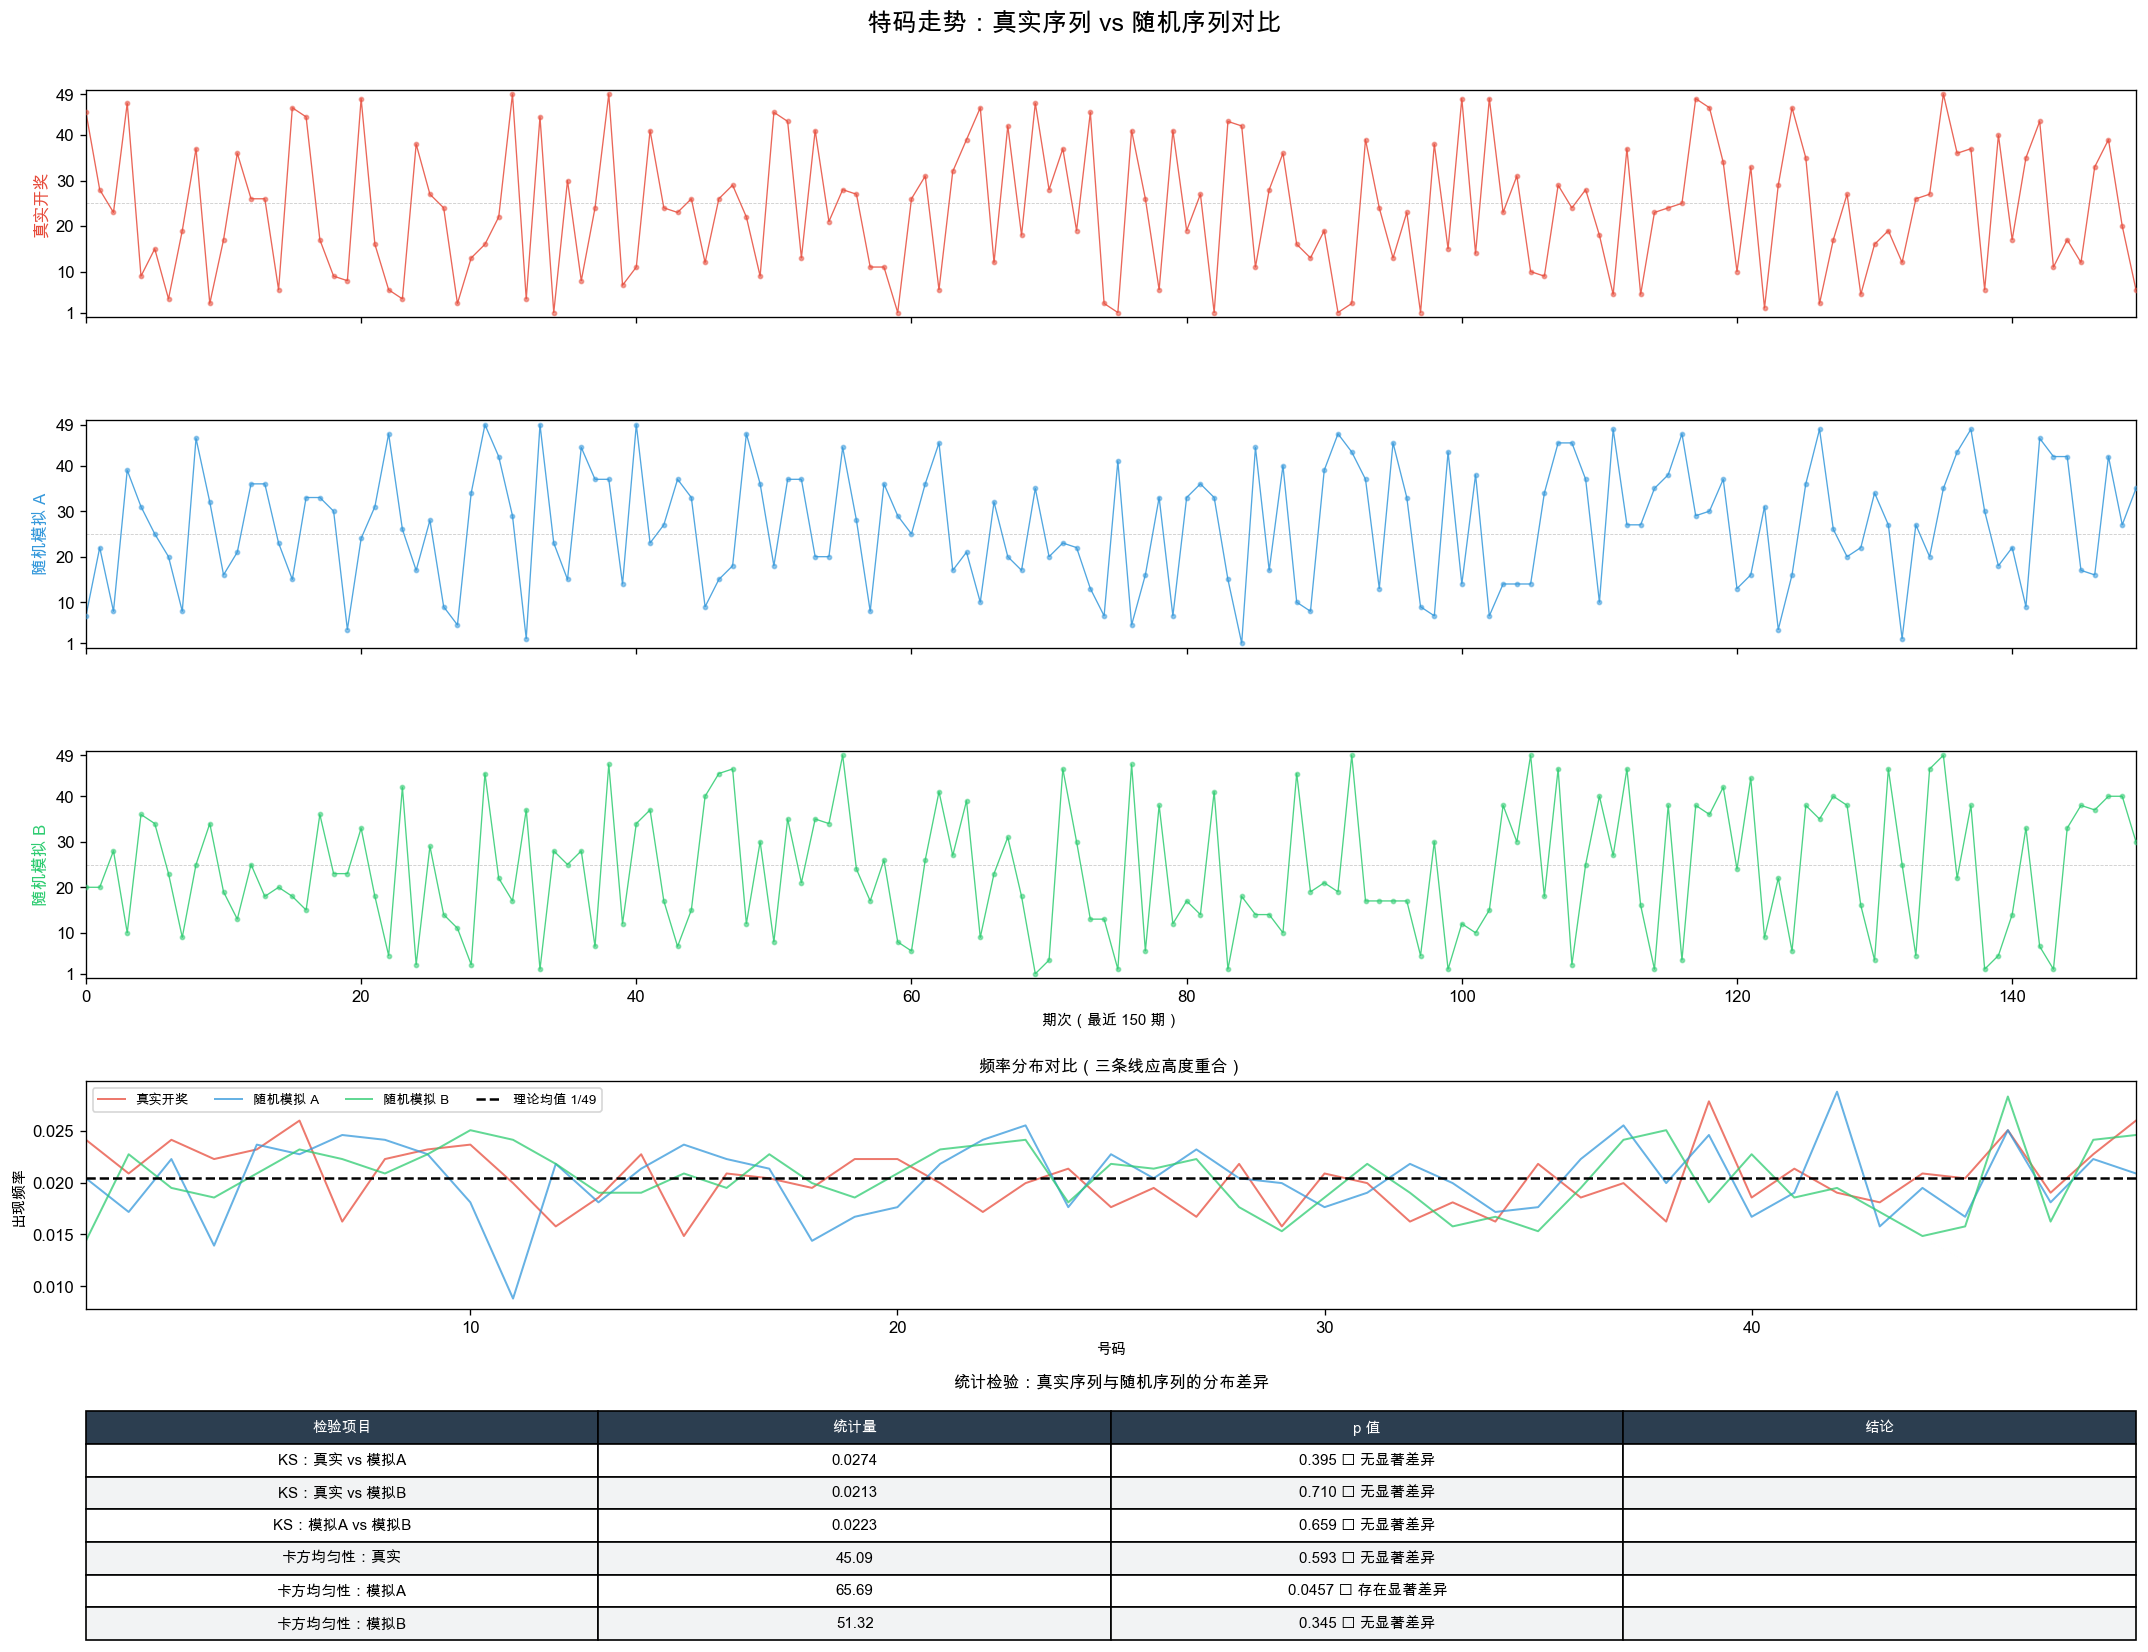


核心结论：KS检验 p > 0.05 → 真实序列与随机序列统计上无法区分
         走势图看起来「有规律」，本质是人脑在随机中强行找模式


In [31]:
# ── 九、随机模拟对比 ─────────────────────────────────────────────────────
# 用视觉证明：真实序列 vs 随机序列，统计上无法区分

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import ks_2samp, chisquare

rng     = np.random.default_rng(42)
actual  = df['special'].values          # 全量真实数据
N       = len(actual)
WINDOW  = min(150, N)                   # 展示最近 150 期

# 生成两条随机序列（同等长度）
sim_a = rng.integers(1, 50, size=N)
sim_b = rng.integers(1, 50, size=N)

seq_labels  = ['真实开奖', '随机模拟 A', '随机模拟 B']
seq_colors  = ['#E74C3C', '#3498DB', '#2ECC71']
sequences   = [actual, sim_a, sim_b]

fig = plt.figure(figsize=(18, 14))
fig.suptitle('特码走势：真实序列 vs 随机序列对比', fontsize=15, fontweight='bold', y=0.98)

# ── 上半部分：最近 WINDOW 期走势折线图（3行）──────────────────────────────
for row, (seq, label, color) in enumerate(zip(sequences, seq_labels, seq_colors)):
    ax = fig.add_subplot(5, 1, row + 1)
    s  = seq[-WINDOW:]
    ax.plot(range(WINDOW), s, color=color, lw=0.8, alpha=0.85)
    ax.scatter(range(WINDOW), s, color=color, s=6, alpha=0.5, zorder=3)
    ax.set_xlim(0, WINDOW - 1)
    ax.set_ylim(0, 50)
    ax.set_yticks([1, 10, 20, 30, 40, 49])
    ax.set_ylabel(label, fontsize=10, color=color, fontweight='bold')
    ax.axhline(25, color='gray', lw=0.5, linestyle='--', alpha=0.4)
    ax.tick_params(labelbottom=(row == 2))
    if row == 2:
        ax.set_xlabel(f'期次（最近 {WINDOW} 期）', fontsize=9)

# ── 下半部分：频率分布对比（直方图）──────────────────────────────────────
ax_hist = fig.add_subplot(5, 1, 4)
bins = np.arange(0.5, 50.5, 1)
for seq, label, color in zip(sequences, seq_labels, seq_colors):
    counts, _ = np.histogram(seq, bins=bins)
    freq = counts / counts.sum()
    ax_hist.plot(range(1, 50), freq, color=color, lw=1.2, alpha=0.75, label=label)
ax_hist.axhline(1/49, color='black', lw=1.5, linestyle='--', label='理论均值 1/49')
ax_hist.set_xlabel('号码', fontsize=9)
ax_hist.set_ylabel('出现频率', fontsize=9)
ax_hist.set_title('频率分布对比（三条线应高度重合）', fontsize=10)
ax_hist.legend(fontsize=8, ncol=4)
ax_hist.set_xlim(1, 49)

# ── 统计检验结果 ──────────────────────────────────────────────────────
ax_stats = fig.add_subplot(5, 1, 5)
ax_stats.axis('off')

# KS 检验：真实 vs 模拟A / 模拟B
ks_ab  = ks_2samp(actual, sim_a)
ks_ac  = ks_2samp(actual, sim_b)
ks_bc  = ks_2samp(sim_a,  sim_b)

# 卡方检验（均匀性）
def chi_unif(seq):
    counts = np.bincount(seq, minlength=50)[1:50]  # 1-49
    exp    = np.full(49, len(seq) / 49)
    stat, p = chisquare(counts, exp)
    return stat, p

chi_real = chi_unif(actual)
chi_sima = chi_unif(sim_a)
chi_simb = chi_unif(sim_b)

def fmt_p(p):
    if p > 0.05: return f'{p:.3f} ✅ 无显著差异'
    else:        return f'{p:.4f} ❌ 存在显著差异'

table_data = [
    ['检验项目', '统计量', 'p 值', '结论'],
    ['KS：真实 vs 模拟A', f'{ks_ab.statistic:.4f}', fmt_p(ks_ab.pvalue), ''],
    ['KS：真实 vs 模拟B', f'{ks_ac.statistic:.4f}', fmt_p(ks_ac.pvalue), ''],
    ['KS：模拟A vs 模拟B', f'{ks_bc.statistic:.4f}', fmt_p(ks_bc.pvalue), ''],
    ['卡方均匀性：真实', f'{chi_real[0]:.2f}', fmt_p(chi_real[1]), ''],
    ['卡方均匀性：模拟A', f'{chi_sima[0]:.2f}', fmt_p(chi_sima[1]), ''],
    ['卡方均匀性：模拟B', f'{chi_simb[0]:.2f}', fmt_p(chi_simb[1]), ''],
]

tbl = ax_stats.table(cellText=table_data[1:], colLabels=table_data[0],
                     loc='center', cellLoc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 1.6)
for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor('#2C3E50')
        cell.set_text_props(color='white', fontweight='bold')
    elif r % 2 == 0:
        cell.set_facecolor('#F2F3F4')

ax_stats.set_title('统计检验：真实序列与随机序列的分布差异', fontsize=10, pad=15)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()
print()
print('=' * 60)
print('核心结论：KS检验 p > 0.05 → 真实序列与随机序列统计上无法区分')
print('         走势图看起来「有规律」，本质是人脑在随机中强行找模式')
print('=' * 60)


## 十、异常检测
> **异常定义**：当前遗漏期数超过理论平均间隔的倍数阈值
>
> | 级别 | 条件 | 含义 |
> |------|------|---------|
> | ✅ 正常 | 遗漏 < 2× 理论间隔（98期） | 在正常随机波动范围内 |
> | 🟡 警告 | 2× ≤ 遗漏 < 3.5×（98~171期） | 偏长，仍属随机范围 |
> | 🔴 严重 | 遗漏 ≥ 3.5× 理论间隔（≥172期） | 极端遗漏，统计上罕见 |
>
> ⚠️ **注意**：异常遗漏 ≠ 下期更容易出现，每期概率始终为 1/49

In [ ]:
# ── 十、异常检测 ─────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import config

THEORY_GAP = 49          # 理论平均间隔（固定常数）
WARN_MULT  = 2.0         # 🟡 警告阈值
CRIT_MULT  = 3.5         # 🔴 严重阈值
WARN_GAP   = int(THEORY_GAP * WARN_MULT)   # 98
CRIT_GAP   = int(THEORY_GAP * CRIT_MULT)   # 171

specials = df['special'].values
n_draws  = len(specials)

# ── 计算每个号码异常指标 ────────────────────────────────────────────────
records = []
for num in range(1, 50):
    pos   = np.where(specials == num)[0]
    count = len(pos)
    if count == 0:
        avg_gap     = float('inf')
        current_gap = n_draws
    else:
        avg_gap     = float(np.diff(pos).mean()) if count >= 2 else float(n_draws)
        current_gap = n_draws - 1 - int(pos[-1])

    ratio = current_gap / THEORY_GAP
    if ratio >= CRIT_MULT:
        level, status = 3, '🔴 严重'
    elif ratio >= WARN_MULT:
        level, status = 2, '🟡 警告'
    else:
        level, status = 1, '✅ 正常'

    records.append({
        '号码': num,
        '出现次数': count,
        '实际均间隔': round(avg_gap, 1) if avg_gap != float('inf') else '-',
        '当前遗漏': current_gap,
        '遗漏/理论比': round(ratio, 2),
        '状态': status,
        '_level': level,
        '_gap': current_gap,
    })

anom_df = pd.DataFrame(records)
n_warn  = (anom_df['_level'] == 2).sum()
n_crit  = (anom_df['_level'] == 3).sum()
n_ok    = (anom_df['_level'] == 1).sum()

# ── 图1：全号码遗漏柱状图（颜色分级）────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(18, 11))
fig.suptitle(f'异常检测报告（共 {n_draws} 期数据）', fontsize=14, fontweight='bold')

ax = axes[0]
colors = []
for _, row in anom_df.iterrows():
    if row['_level'] == 3:   colors.append('#E74C3C')
    elif row['_level'] == 2: colors.append('#F39C12')
    else:                    colors.append('#2ECC71')

bars = ax.bar(anom_df['号码'], anom_df['当前遗漏'], color=colors, width=0.7, zorder=3)
ax.axhline(THEORY_GAP, color='#3498DB', lw=1.5, linestyle='--',
           label=f'理论均值 {THEORY_GAP} 期')
ax.axhline(WARN_GAP,   color='#F39C12', lw=1.5, linestyle='--',
           label=f'🟡 警告线 {WARN_GAP} 期（2×）')
ax.axhline(CRIT_GAP,   color='#E74C3C', lw=1.5, linestyle='--',
           label=f'🔴 严重线 {CRIT_GAP} 期（3.5×）')

ax.set_xlabel('号码', fontsize=10)
ax.set_ylabel('当前遗漏（期）', fontsize=10)
ax.set_xticks(range(1, 50))
ax.set_xticklabels(range(1, 50), fontsize=7)
ax.grid(axis='y', alpha=0.3, zorder=0)
ax.legend(fontsize=9)
ax.set_title(
    f'✅ 正常 {n_ok} 个  |  🟡 警告 {n_warn} 个  |  🔴 严重 {n_crit} 个',
    fontsize=11
)

# 在严重/警告的柱子上标注号码
for _, row in anom_df[anom_df['_level'] >= 2].iterrows():
    ax.text(row['号码'], row['当前遗漏'] + 1, str(int(row['号码'])),
            ha='center', va='bottom', fontsize=7, fontweight='bold')

# ── 图2：异常号码详情表 ──────────────────────────────────────────────────
ax2 = axes[1]
ax2.axis('off')

warn_list = anom_df[anom_df['_level'] >= 2].sort_values('_gap', ascending=False)

if len(warn_list) == 0:
    ax2.text(0.5, 0.5, '✅ 当前无异常号码', ha='center', va='center',
             fontsize=14, transform=ax2.transAxes)
else:
    cols = ['号码', '出现次数', '实际均间隔', '当前遗漏', '遗漏/理论比', '状态']
    tbl  = ax2.table(
        cellText  = warn_list[cols].values,
        colLabels = cols,
        loc='center', cellLoc='center'
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(10)
    tbl.scale(1, 2.0)

    # 表头样式
    for c in range(len(cols)):
        tbl[(0, c)].set_facecolor('#2C3E50')
        tbl[(0, c)].set_text_props(color='white', fontweight='bold')

    # 行颜色
    for r, (_, row) in enumerate(warn_list.iterrows(), 1):
        color = '#FADBD8' if row['_level'] == 3 else '#FEF9E7'
        for c in range(len(cols)):
            tbl[(r, c)].set_facecolor(color)

    ax2.set_title('异常号码详情（按遗漏期数降序）', fontsize=11, pad=20)

plt.tight_layout()
plt.show()

# ── 文字汇总 ────────────────────────────────────────────────────────────
print('=' * 60)
print(f'异常检测汇总（数据量：{n_draws} 期）')
print('=' * 60)
print(f'  理论平均间隔：{THEORY_GAP} 期')
print(f'  🟡 警告阈值 ：{WARN_GAP} 期（≥{WARN_MULT}×）')
print(f'  🔴 严重阈值 ：{CRIT_GAP} 期（≥{CRIT_MULT}×）')
print('-' * 60)
print(f'  ✅ 正常：{n_ok:2d} 个号码')
print(f'  🟡 警告：{n_warn:2d} 个号码')
print(f'  🔴 严重：{n_crit:2d} 个号码')
if len(warn_list) > 0:
    print('-' * 60)
    print('  异常号码列表：')
    for _, row in warn_list.iterrows():
        print(f"    {row['状态']}  号码 {int(row['号码']):2d}  "
              f"遗漏 {int(row['当前遗漏'])} 期  "
              f"（{row['遗漏/理论比']}× 理论均值）")
print('=' * 60)
print('⚠️  遗漏长 ≠ 下期更易出现，每期概率始终 = 1/49')


## 十一、认知偏差分析
> 本节用数据和模拟**直接证伪**三种最常见的彩票认知谬误
>
> | # | 谬误名称 | 错误认知 | 数学事实 |
> |---|---------|---------|--------|
> | 1 | 赌徒谬误 | 久未出现 → 该出了 | 每期独立，P 恒 = 1/49 |
> | 2 | 模式幻觉 | 走势图有规律可循 | 随机数据里必然出现「假规律」|
> | 3 | 幸存者偏差 | 有人连续中奖 → 有方法 | 大基数下必然存在幸运者 |

In [ ]:
# ── 十一、认知偏差分析 ───────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.ndimage import uniform_filter1d

rng = np.random.default_rng(2024)

fig = plt.figure(figsize=(18, 16))
fig.suptitle('认知偏差分析：三大谬误的数学证伪', fontsize=15, fontweight='bold', y=0.98)
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.55, wspace=0.35)

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# 谬误①：赌徒谬误
# 命题：「号码X已经N期没出，下期出现的概率更高了」
# 证伪：条件概率 = 无条件概率
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
ax1 = fig.add_subplot(gs[0, :])

SIMS     = 200_000
MAX_MISS = 120
draws    = rng.integers(1, 50, size=SIMS)

# 对每个「已遗漏N期」的状态，统计下一期中奖率
hit_counts  = np.zeros(MAX_MISS + 1)
trial_counts = np.zeros(MAX_MISS + 1)
streak = 0
TARGET = 1
for d in draws:
    if streak <= MAX_MISS:
        trial_counts[streak] += 1
        if d == TARGET:
            hit_counts[streak] += 1
    streak = 0 if d == TARGET else streak + 1

valid = trial_counts > 50  # 样本量足够的区间
x_vals  = np.where(valid)[0]
p_vals  = hit_counts[valid] / trial_counts[valid]

ax1.bar(x_vals, p_vals, color='#5DADE2', width=0.8, alpha=0.7, label='实测中奖率')
ax1.axhline(1/49, color='#E74C3C', lw=2, linestyle='--', label=f'理论值 1/49 ≈ {1/49:.4f}')
ax1.fill_between(x_vals, 1/49 - 0.01, 1/49 + 0.01, alpha=0.15, color='#E74C3C')
ax1.set_xlabel('号码 1 已连续 N 期未出现', fontsize=10)
ax1.set_ylabel('下一期出现的实测概率', fontsize=10)
ax1.set_ylim(0, 0.08)
ax1.set_xlim(-1, MAX_MISS)
ax1.legend(fontsize=10)
ax1.set_title(
    '谬误① 赌徒谬误｜无论已遗漏多少期，下一期中奖概率始终 = 1/49',
    fontsize=11, color='#C0392B', fontweight='bold'
)
ax1.text(80, 0.065,
    'P(出现 | 已遗漏N期) = P(出现) = 1/49\n每期独立，历史对未来零影响',
    fontsize=10, color='#2C3E50',
    bbox=dict(boxstyle='round,pad=0.5', facecolor='#EBF5FB', edgecolor='#5DADE2')
)

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# 谬误②：模式幻觉（Apophenia）
# 命题：「走势图有规律，能预测趋势」
# 证伪：随机数 + 移动平均 = 看起来完全一样
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
ax2 = fig.add_subplot(gs[1, 0])
ax3 = fig.add_subplot(gs[1, 1])

N_SHOW = 100
real_seq = df['special'].values[-N_SHOW:].astype(float)
rand_seq = rng.integers(1, 50, size=N_SHOW).astype(float)
MA_WIN   = 7

for ax, seq, label, color in [
    (ax2, real_seq, '真实开奖（最近100期）', '#E74C3C'),
    (ax3, rand_seq, '纯随机生成（100期）',  '#3498DB'),
]:
    ma = uniform_filter1d(seq, size=MA_WIN)
    ax.scatter(range(N_SHOW), seq, color=color, s=12, alpha=0.5, zorder=3)
    ax.plot(range(N_SHOW), seq,   color=color, lw=0.6, alpha=0.4)
    ax.plot(range(N_SHOW), ma,    color='#2C3E50', lw=2.0,
            label=f'{MA_WIN}期移动平均', zorder=4)
    ax.set_ylim(0, 52)
    ax.set_yticks([1, 10, 20, 30, 40, 49])
    ax.set_xlabel('期次', fontsize=9)
    ax.set_ylabel('特码', fontsize=9)
    ax.legend(fontsize=8)
    ax.set_title(label, fontsize=10, color=color, fontweight='bold')
    ax.grid(alpha=0.2)

ax2.set_title(
    '谬误② 模式幻觉｜「趋势线」在真实数据和随机数据上看起来一样',
    fontsize=11, color='#C0392B', fontweight='bold',
    loc='left', pad=8
)

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# 谬误③：幸存者偏差
# 命题：「有人连中3期，说明他有方法」
# 证伪：10000人各买50期，必然有人看起来「连续命中」
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
ax4 = fig.add_subplot(gs[2, 0])
ax5 = fig.add_subplot(gs[2, 1])

N_PLAYERS = 10_000
N_ROUNDS  = 50
N_NUMS    = 4   # 每期买4个号

# 模拟：每人每期随机猜4个号，看是否命中
results  = rng.integers(1, 50, size=(N_PLAYERS, N_ROUNDS))  # 开奖号
guesses  = np.stack([
    rng.choice(49, size=(N_PLAYERS, N_NUMS), replace=False) + 1
    for _ in range(N_ROUNDS)
], axis=1)  # (players, rounds, 4)

hits = np.any(guesses == results[:, :, np.newaxis], axis=2)  # (players, rounds)

# 计算每位玩家的最长连续命中
def max_streak(arr):
    best = cur = 0
    for v in arr:
        cur = cur + 1 if v else 0
        best = max(best, cur)
    return best

streaks = np.array([max_streak(hits[i]) for i in range(N_PLAYERS)])

# 柱状图：最长连续命中分布
max_s = min(streaks.max(), 8)
bins  = np.arange(0, max_s + 2) - 0.5
cnts, _ = np.histogram(streaks, bins=bins)

bar_colors = ['#2ECC71' if i < 3 else '#E74C3C' for i in range(len(cnts))]
ax4.bar(range(len(cnts)), cnts, color=bar_colors, width=0.7)
for i, c in enumerate(cnts):
    if c > 0:
        ax4.text(i, c + 20, str(c), ha='center', va='bottom', fontsize=8)
ax4.set_xticks(range(len(cnts)))
ax4.set_xticklabels([str(i) for i in range(len(cnts))])
ax4.set_xlabel('最长连续命中期数', fontsize=9)
ax4.set_ylabel('玩家人数', fontsize=9)
n_3plus = (streaks >= 3).sum()
ax4.set_title(
    f'{N_PLAYERS:,} 人各玩 {N_ROUNDS} 期 · 每期买 {N_NUMS} 个号\n'
    f'连续命中≥3期的玩家：{n_3plus} 人（{n_3plus/N_PLAYERS*100:.1f}%）',
    fontsize=9
)
ax4.grid(axis='y', alpha=0.3)

# 玩家总盈亏分布
BET_PER_NUM = 5
PAYOUT_NET  = 47
cost_total  = N_ROUNDS * N_NUMS * BET_PER_NUM                   # 每人总投入
win_counts  = hits.sum(axis=1)                                   # 每人命中次数
profit      = win_counts * (PAYOUT_NET - (N_NUMS-1)) * BET_PER_NUM - cost_total

n_profit = (profit > 0).sum()
n_loss   = (profit <= 0).sum()
ax5.hist(profit, bins=60, color='#5DADE2', edgecolor='white', lw=0.3)
ax5.axvline(0,              color='#E74C3C', lw=2, linestyle='--', label='盈亏平衡线')
ax5.axvline(profit.mean(),  color='#F39C12', lw=2, linestyle='-',
            label=f'均值 ¥{profit.mean():.0f}')
ax5.set_xlabel('最终盈亏（元）', fontsize=9)
ax5.set_ylabel('玩家人数', fontsize=9)
ax5.legend(fontsize=8)
ax5.set_title(
    f'盈利玩家：{n_profit}人（{n_profit/N_PLAYERS*100:.1f}%）  '
    f'亏损玩家：{n_loss}人（{n_loss/N_PLAYERS*100:.1f}%）',
    fontsize=9
)
ax5.grid(axis='y', alpha=0.3)

# 跨行标题
fig.text(0.5, 0.355,
    '谬误③ 幸存者偏差｜「连续中奖的人」不是有方法，是大基数下的必然存在',
    ha='center', fontsize=11, color='#C0392B', fontweight='bold'
)

plt.savefig('output/cognitive_bias.png', dpi=120, bbox_inches='tight')
plt.show()

print('=' * 62)
print('认知偏差分析结论')
print('=' * 62)
print(f'① 赌徒谬误：遗漏N期后，中奖概率仍 = 1/49（模拟{SIMS:,}次验证）')
print(f'② 模式幻觉：真实走势与随机走势的移动平均线，肉眼无法区分')
print(f'③ 幸存者偏差：{N_PLAYERS:,}人中有{n_3plus}人({n_3plus/N_PLAYERS*100:.1f}%)连中≥3期')
print(f'             这些人不是有方法，是概率的必然产物')
print(f'   盈利玩家占比：{n_profit/N_PLAYERS*100:.1f}%  亏损玩家占比：{n_loss/N_PLAYERS*100:.1f}%')
print('=' * 62)


## 十二、报告导出

| 格式 | 定位 | 用途 |
|------|------|------|
| **HTML** | 产品 | 自包含网页，内嵌图表，直接发给别人 |
| **PDF** | 商品 | 专业排版，适合打印 / 正式发送 |
| **Markdown** | 说明书 | 纯文本结构化，适合文档系统 / 二次编辑 |

> 三种格式均输出到 `output/reports/` 目录，文件名含生成日期

In [ ]:
# ── 十二、报告导出 ────────────────────────────────────────────────────
# 输出：HTML（产品）/ PDF（商品）/ Markdown（说明书）
# 依赖：仅需 df 已定义，其余全部自行计算

import base64, io, os, datetime, textwrap
from collections import Counter
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from scipy.stats import chisquare
import config

REPORT_DIR  = os.path.join(config.OUTPUT_DIR, 'reports')
os.makedirs(REPORT_DIR, exist_ok=True)
THEORY_GAP  = 49

HTML_PATH = os.path.join(REPORT_DIR, 'analysis_report.html')
PDF_PATH  = os.path.join(REPORT_DIR, 'analysis_report.pdf')
MD_PATH   = os.path.join(REPORT_DIR, 'README.md')

# ── 重新计算报告所需统计量 ────────────────────────────────────────────
specials  = df['special'].values
n_draws   = len(specials)
date_min  = df['openTime'].min().strftime('%Y-%m-%d')
date_max  = df['openTime'].max().strftime('%Y-%m-%d')

counts   = Counter(int(x) for x in specials)
freq_arr = np.array([counts.get(i, 0) for i in range(1, 50)])
chi2_stat, chi2_p = chisquare(freq_arr, np.full(49, n_draws / 49))
chi2_pass = chi2_p > 0.05

# 遗漏
gap_rows = []
for num in range(1, 50):
    pos = np.where(specials == num)[0]
    cur = n_draws - 1 - int(pos[-1]) if len(pos) > 0 else n_draws
    ratio = cur / THEORY_GAP
    lv = '🔴 严重' if ratio >= 3.5 else ('🟡 警告' if ratio >= 2.0 else '✅ 正常')
    gap_rows.append({'号码': num, '当前遗漏': cur, '比值': round(ratio, 2), '状态': lv})
gap_rows.sort(key=lambda r: r['当前遗漏'], reverse=True)
anomalies = [r for r in gap_rows if r['比值'] >= 2.0]

# 热/冷号
sorted_freq = sorted(enumerate(freq_arr, 1), key=lambda x: x[1])
cold5 = sorted_freq[:5]
hot5  = sorted_freq[-5:][::-1]

# ── 图表生成（共4张，供三种格式复用）────────────────────────────────────
def fig_to_b64(fig):
    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=110, bbox_inches='tight')
    buf.seek(0)
    return base64.b64encode(buf.read()).decode()

charts_b64 = {}
charts_fig = {}

# 图A：频率柱状图
fig_a, ax = plt.subplots(figsize=(14, 3.5))
bar_colors = ['#E74C3C' if c == freq_arr.max() else
              '#95A5A6' if c == freq_arr.min() else '#5DADE2'
              for c in freq_arr]
ax.bar(range(1, 50), freq_arr, color=bar_colors, width=0.7)
ax.axhline(n_draws / 49, color='black', lw=1.5, linestyle='--', label=f'理论均值 {n_draws/49:.1f}')
ax.set_xlabel('号码'); ax.set_ylabel('出现次数')
ax.set_title('号码频率分布'); ax.legend(); ax.set_xticks(range(1, 50))
ax.tick_params(axis='x', labelsize=7)
plt.tight_layout()
charts_b64['freq'] = fig_to_b64(fig_a)
charts_fig['freq'] = fig_a
plt.close(fig_a)

# 图B：当前遗漏柱状图
fig_b, ax = plt.subplots(figsize=(14, 3.5))
g_vals  = [r['当前遗漏'] for r in gap_rows]
g_nums  = [r['号码'] for r in gap_rows]
g_color = ['#E74C3C' if r['比值'] >= 3.5 else
           '#F39C12' if r['比值'] >= 2.0 else '#2ECC71' for r in gap_rows]
ax.bar(range(49), g_vals, color=g_color, width=0.7)
ax.set_xticks(range(49))
ax.set_xticklabels(g_nums, fontsize=7)
ax.axhline(THEORY_GAP,      color='#3498DB', lw=1.2, linestyle='--', label='理论均值 49')
ax.axhline(THEORY_GAP * 2,  color='#F39C12', lw=1.2, linestyle='--', label='警告线 98')
ax.axhline(THEORY_GAP * 3.5,color='#E74C3C', lw=1.2, linestyle='--', label='严重线 171')
ax.set_xlabel('号码（按遗漏降序）'); ax.set_ylabel('当前遗漏（期）')
ax.set_title('当前遗漏 · 异常检测'); ax.legend(fontsize=8)
plt.tight_layout()
charts_b64['gap'] = fig_to_b64(fig_b)
charts_fig['gap'] = fig_b
plt.close(fig_b)

# 图C：热号 vs 冷号对比
fig_c, axes = plt.subplots(1, 2, figsize=(10, 3.5))
for ax, data, title, color in [
    (axes[0], hot5,  'Top5 热号', '#E74C3C'),
    (axes[1], cold5, 'Top5 冷号', '#3498DB'),
]:
    nums, cnts = zip(*data)
    ax.barh([str(n) for n in nums], cnts, color=color, alpha=0.8)
    ax.axvline(n_draws / 49, color='gray', lw=1, linestyle='--')
    ax.set_xlabel('出现次数'); ax.set_title(title)
    for i, v in enumerate(cnts):
        ax.text(v + 0.3, i, str(v), va='center', fontsize=9)
plt.tight_layout()
charts_b64['hotcold'] = fig_to_b64(fig_c)
charts_fig['hotcold'] = fig_c
plt.close(fig_c)

print('图表生成完毕，开始输出三种报告格式...')

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# ① HTML 报告（产品）
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
anom_rows_html = ''.join(
    f'<tr class="{"crit" if r["比值"]>=3.5 else "warn"}">'  
    f'<td>{r["号码"]}</td><td>{r["当前遗漏"]}</td>'
    f'<td>{r["比值"]}</td><td>{r["状态"]}</td></tr>'
    for r in anomalies
) or '<tr><td colspan="4">✅ 当前无异常号码</td></tr>'

html = f"""<!DOCTYPE html>
<html lang="zh-CN">
<head>
<meta charset="UTF-8">
<title>特码统计分析报告</title>
<style>
  body{{font-family:'PingFang SC','Microsoft YaHei',sans-serif;margin:0;background:#F4F6F7;color:#2C3E50}}
  .wrap{{max-width:1100px;margin:0 auto;padding:32px 20px}}
  h1{{color:#1A252F;border-bottom:3px solid #2980B9;padding-bottom:10px}}
  h2{{color:#2980B9;margin-top:36px}}
  .badge{{display:inline-block;padding:4px 12px;border-radius:20px;font-size:13px;font-weight:bold}}
  .pass{{background:#D5F5E3;color:#1E8449}}.fail{{background:#FADBD8;color:#C0392B}}
  .card{{background:#fff;border-radius:8px;box-shadow:0 2px 8px rgba(0,0,0,.08);padding:20px;margin:16px 0}}
  table{{width:100%;border-collapse:collapse;margin-top:10px}}
  th{{background:#2980B9;color:#fff;padding:8px 12px;text-align:left}}
  td{{padding:7px 12px;border-bottom:1px solid #ECF0F1}}
  tr.crit td{{background:#FADBD8}} tr.warn td{{background:#FEF9E7}}
  tr:hover td{{background:#EBF5FB}}
  .stat-grid{{display:grid;grid-template-columns:repeat(4,1fr);gap:16px;margin:16px 0}}
  .stat-box{{background:#fff;border-radius:8px;padding:18px;text-align:center;box-shadow:0 2px 8px rgba(0,0,0,.07)}}
  .stat-num{{font-size:28px;font-weight:bold;color:#2980B9}}
  .stat-lbl{{font-size:12px;color:#7F8C8D;margin-top:4px}}
  img{{width:100%;border-radius:6px;margin:10px 0}}
  footer{{text-align:center;color:#95A5A6;font-size:12px;margin-top:40px;padding-top:16px;border-top:1px solid #ECF0F1}}
  .warn-box{{background:#FEF9E7;border-left:4px solid #F39C12;padding:10px 16px;margin:10px 0;border-radius:0 6px 6px 0;font-size:13px}}
</style>
</head>
<body>
<div class="wrap">
  <h1>特码统计分析报告</h1>
  <p style="color:#7F8C8D">生成时间：{datetime.datetime.now().strftime('%Y-%m-%d %H:%M')} &nbsp;|&nbsp;
     数据区间：{date_min} ~ {date_max}</p>

  <div class="stat-grid">
    <div class="stat-box"><div class="stat-num">{n_draws}</div><div class="stat-lbl">总期数</div></div>
    <div class="stat-box"><div class="stat-num">{date_min[:4]}~{date_max[:4]}</div><div class="stat-lbl">数据年份</div></div>
    <div class="stat-box"><div class="stat-num">{len(anomalies)}</div><div class="stat-lbl">异常号码数</div></div>
    <div class="stat-box"><div class="stat-num">{'通过' if chi2_pass else '未通过'}</div><div class="stat-lbl">均匀性检验</div></div>
  </div>

  <h2>一、频率分布</h2>
  <div class="card">
    <img src="data:image/png;base64,{charts_b64['freq']}" alt="频率分布">
    <table>
      <tr><th>指标</th><th>值</th></tr>
      <tr><td>卡方统计量</td><td>{chi2_stat:.2f}</td></tr>
      <tr><td>p 值</td><td>{chi2_p:.4f}</td></tr>
      <tr><td>均匀性检验</td><td><span class="badge {'pass' if chi2_pass else 'fail'}">
        {'✅ 通过（p>0.05，分布符合均匀随机）' if chi2_pass else '❌ 未通过（p≤0.05，存在显著偏差）'}
      </span></td></tr>
    </table>
  </div>

  <h2>二、热号 / 冷号</h2>
  <div class="card">
    <img src="data:image/png;base64,{charts_b64['hotcold']}" alt="热冷号">
    <table>
      <tr><th>类型</th><th>号码</th><th>出现次数</th></tr>
      {''.join(f"<tr><td>🔥 热号 #{i+1}</td><td>{n}</td><td>{c}</td></tr>" for i,(n,c) in enumerate(hot5))}
      {''.join(f"<tr><td>🧊 冷号 #{i+1}</td><td>{n}</td><td>{c}</td></tr>" for i,(n,c) in enumerate(cold5))}
    </table>
  </div>

  <h2>三、异常检测</h2>
  <div class="card">
    <img src="data:image/png;base64,{charts_b64['gap']}" alt="遗漏检测">
    <table>
      <tr><th>号码</th><th>当前遗漏</th><th>遗漏/理论比</th><th>状态</th></tr>
      {anom_rows_html}
    </table>
  </div>

  <h2>四、核心结论</h2>
  <div class="card">
    <div class="warn-box">⚠️ 以下结论基于历史统计，<strong>不代表对未来的预测能力</strong>。每期开奖为独立随机事件，中奖概率始终 = 1/49。</div>
    <table>
      <tr><th>维度</th><th>结论</th></tr>
      <tr><td>随机性</td><td>{'卡方检验通过，号码分布符合均匀随机假设' if chi2_pass else '卡方检验未通过，号码分布存在统计显著偏差'}</td></tr>
      <tr><td>异常遗漏</td><td>共 {len(anomalies)} 个号码遗漏超过 2× 理论均值，其中 {sum(1 for r in anomalies if r['比值']>=3.5)} 个达到严重级别</td></tr>
      <tr><td>理论基准</td><td>每个号码理论平均间隔 = 49 期，RTP ≈ 97.96%，庄家抽水率 ≈ 2.04%</td></tr>
      <tr><td>预测能力</td><td>互信息 = 0，历史数据对下期无任何预测价值</td></tr>
    </table>
  </div>

  <footer>特码统计分析系统 · 本报告仅用于学习研究，不构成任何投注建议</footer>
</div>
</body></html>"""

html_path = HTML_PATH
with open(html_path, 'w', encoding='utf-8') as f:
    f.write(html)
print(f'✅ HTML 已生成：{html_path}')

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# ② PDF 报告（商品）
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
pdf_path = PDF_PATH

with PdfPages(pdf_path) as pdf:

    # 封面
    fig_cover = plt.figure(figsize=(11.69, 8.27))
    fig_cover.patch.set_facecolor('#1A252F')
    fig_cover.text(0.5, 0.65, '特码统计分析报告',
                   ha='center', va='center', fontsize=32, fontweight='bold', color='white')
    fig_cover.text(0.5, 0.52, f'数据区间：{date_min} ~ {date_max}',
                   ha='center', fontsize=14, color='#AEB6BF')
    fig_cover.text(0.5, 0.44, f'共 {n_draws} 期 · 生成于 {datetime.datetime.now().strftime("%Y-%m-%d %H:%M")}',
                   ha='center', fontsize=12, color='#AEB6BF')
    fig_cover.text(0.5, 0.15,
                   '⚠️  本报告仅用于历史数据统计分析与学习研究，不具备预测能力，严禁用于赌博或选号',
                   ha='center', fontsize=9, color='#F39C12')
    pdf.savefig(fig_cover, facecolor=fig_cover.get_facecolor())
    plt.close(fig_cover)

    # 概览页
    fig_ov, ax = plt.subplots(figsize=(11.69, 8.27))
    ax.axis('off')
    ax.set_title('数据概览 & 检验结果', fontsize=16, fontweight='bold', pad=20)
    overview_data = [
        ['指标', '值'],
        ['总期数', str(n_draws)],
        ['数据起始', date_min],
        ['数据截止', date_max],
        ['卡方统计量', f'{chi2_stat:.2f}'],
        ['卡方 p 值', f'{chi2_p:.4f}'],
        ['均匀性检验', '通过 ✅' if chi2_pass else '未通过 ❌'],
        ['异常号码数（≥2×）', str(len(anomalies))],
        ['严重号码数（≥3.5×）', str(sum(1 for r in anomalies if r['比值'] >= 3.5))],
        ['理论平均间隔', '49 期'],
        ['庄家抽水率', '≈ 2.04%（1/49）'],
        ['预测能力', '无（互信息 = 0）'],
    ]
    tbl = ax.table(cellText=overview_data[1:], colLabels=overview_data[0],
                   loc='center', cellLoc='left')
    tbl.auto_set_font_size(False); tbl.set_fontsize(11); tbl.scale(1.5, 2.2)
    for (r, c), cell in tbl.get_celld().items():
        if r == 0:
            cell.set_facecolor('#2980B9'); cell.set_text_props(color='white', fontweight='bold')
        elif r % 2 == 0:
            cell.set_facecolor('#EBF5FB')
    plt.tight_layout()
    pdf.savefig(fig_ov); plt.close(fig_ov)

    # 频率分布页
    fig_f, ax = plt.subplots(figsize=(11.69, 8.27))
    bar_colors = ['#E74C3C' if c == freq_arr.max() else
                  '#95A5A6' if c == freq_arr.min() else '#5DADE2' for c in freq_arr]
    ax.bar(range(1, 50), freq_arr, color=bar_colors, width=0.7)
    ax.axhline(n_draws/49, color='black', lw=1.5, linestyle='--', label=f'理论均值 {n_draws/49:.1f}')
    ax.set_xlabel('号码', fontsize=12); ax.set_ylabel('出现次数', fontsize=12)
    ax.set_title('号码频率分布', fontsize=14, fontweight='bold')
    ax.legend(); ax.set_xticks(range(1, 50)); ax.tick_params(axis='x', labelsize=8)
    plt.tight_layout()
    pdf.savefig(fig_f); plt.close(fig_f)

    # 遗漏检测页
    fig_g, ax = plt.subplots(figsize=(11.69, 8.27))
    g_color = ['#E74C3C' if r['比值']>=3.5 else '#F39C12' if r['比值']>=2.0 else '#2ECC71'
               for r in gap_rows]
    ax.bar(range(49), [r['当前遗漏'] for r in gap_rows], color=g_color, width=0.7)
    ax.set_xticks(range(49)); ax.set_xticklabels([r['号码'] for r in gap_rows], fontsize=8)
    ax.axhline(49,    color='#3498DB', lw=1.5, linestyle='--', label='理论均值 49')
    ax.axhline(98,    color='#F39C12', lw=1.5, linestyle='--', label='警告线 98')
    ax.axhline(171.5, color='#E74C3C', lw=1.5, linestyle='--', label='严重线 171')
    ax.set_title('当前遗漏 · 异常检测', fontsize=14, fontweight='bold')
    ax.set_xlabel('号码（遗漏降序）', fontsize=12); ax.set_ylabel('当前遗漏（期）', fontsize=12)
    ax.legend(fontsize=10)
    plt.tight_layout()
    pdf.savefig(fig_g); plt.close(fig_g)

    # PDF 元数据
    d = pdf.infodict()
    d['Title']   = '特码统计分析报告'
    d['Author']  = '特码统计分析系统'
    d['Subject'] = f'数据区间 {date_min} ~ {date_max}'

print(f'✅ PDF 已生成：{pdf_path}')

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# ③ Markdown 报告（说明书）
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
hot_md  = '\n'.join(f'| 🔥 #{i+1} | {n} | {c} |' for i, (n, c) in enumerate(hot5))
cold_md = '\n'.join(f'| 🧊 #{i+1} | {n} | {c} |' for i, (n, c) in enumerate(cold5))
anom_md = '\n'.join(
    f'| {r["号码"]} | {r["当前遗漏"]} | {r["比值"]} | {r["状态"]} |'
    for r in anomalies
) or '| - | - | - | ✅ 当前无异常 |'

md = f"""# 特码统计分析报告

> 生成时间：{datetime.datetime.now().strftime('%Y-%m-%d %H:%M')}  
> 数据区间：{date_min} ~ {date_max}  
> ⚠️ 本报告仅用于学习研究，不具备预测能力，严禁用于赌博或选号

---

## 一、数据概览

| 指标 | 值 |
|------|----|
| 总期数 | {n_draws} |
| 数据起始 | {date_min} |
| 数据截止 | {date_max} |
| 理论平均间隔 | 49 期 |
| 庄家抽水率 | ≈ 2.04%（1/49）|

---

## 二、均匀性检验

| 检验项 | 结果 |
|--------|------|
| 卡方统计量 | {chi2_stat:.2f} |
| p 值 | {chi2_p:.4f} |
| 结论 | {'✅ 通过（p>0.05，分布符合均匀随机假设）' if chi2_pass else '❌ 未通过（p≤0.05，存在显著偏差）'} |

---

## 三、热号 / 冷号

| 类型 | 号码 | 出现次数 |
|------|------|----------|
{hot_md}
{cold_md}

---

## 四、异常检测

阈值：🟡 警告 ≥ 98 期（2×）｜🔴 严重 ≥ 172 期（3.5×）

| 号码 | 当前遗漏 | 遗漏/理论比 | 状态 |
|------|---------|------------|------|
{anom_md}

---

## 五、核心结论

1. **随机性验证**：{'卡方检验通过，号码分布符合均匀随机假设，未发现统计显著偏差。' if chi2_pass else '卡方检验未通过，号码分布存在统计显著偏差，建议关注数据质量。'}
2. **异常遗漏**：共 {len(anomalies)} 个号码遗漏超过 2 倍理论均值（98期），其中 {sum(1 for r in anomalies if r['比值']>=3.5)} 个达到严重级别（172期+）。
3. **预测能力**：互信息 = 0，历史数据对下期开奖无任何预测价值。
4. **赌徒谬误提示**：遗漏期数长 ≠ 下期更容易出现，每期概率始终 = 1/49。

---

*本报告由特码统计分析系统自动生成*
"""

md_path = MD_PATH
with open(md_path, 'w', encoding='utf-8') as f:
    f.write(md)
print(f'✅ Markdown 已生成：{md_path}')

# ── 汇总 ────────────────────────────────────────────────────────────
print()
print('=' * 55)
print('报告导出完成')
print('=' * 55)
print(f'  📄 HTML（展示+分享）→ {html_path}')
print(f'  📋 PDF（变现+发人）→ {pdf_path}')
print(f'  📝 README.md（项目说明）→ {md_path}')
print('=' * 55)
